A Data-Driven Approach to Predicting Hospital Length of Stay, Readmission Risk and Mortality in Myocardial Infarction Patients

# MAIN WORKINGS

1. IMPORTS AND DATA LOADING

In [1]:
import pandas as pd
import numpy as np

1.1 Reading admission level/main csv's (patient, admission and services csv)

In [2]:
patients = pd.read_csv("patients.csv/patients.csv")
admissions = pd.read_csv("admissions.csv/admissions.csv")
services = pd.read_csv("services.csv/services.csv")

print("patients shape:", patients.shape)
print("admissions shape:", admissions.shape)
print("services shape:", services.shape)

print('\n',patients.head(10))
print('\n',admissions.head(10))
print('\n',services.head(10))

patients shape: (364627, 6)
admissions shape: (546028, 16)
services shape: (593071, 5)

    subject_id gender  anchor_age  anchor_year anchor_year_group        dod
0    10000032      F          52         2180       2014 - 2016   9/9/2180
1    10000048      F          23         2126       2008 - 2010        NaN
2    10000058      F          33         2168       2020 - 2022        NaN
3    10000068      F          19         2160       2008 - 2010        NaN
4    10000084      M          72         2160       2017 - 2019  2/13/2161
5    10000102      F          27         2136       2008 - 2010        NaN
6    10000108      M          25         2163       2014 - 2016        NaN
7    10000115      M          24         2154       2017 - 2019        NaN
8    10000117      F          48         2174       2008 - 2010        NaN
9    10000161      M          60         2163       2020 - 2022        NaN

    subject_id   hadm_id        admittime         dischtime deathtime  \
0    1000003

1.2 Reading diagnoses related csv's

In [3]:

d_icd = pd.read_csv("d_icd_diagnoses.csv/d_icd_diagnoses.csv")
diagnoses_icd = pd.read_csv("diagnoses_icd.csv.gz")

print("d_icd shape:", d_icd.shape)
print("diagnoses_icd shape:", diagnoses_icd.shape)

print('\n',d_icd.head(5))
print('\n',diagnoses_icd.head(10))

d_icd shape: (112107, 3)
diagnoses_icd shape: (6364488, 5)

   icd_code  icd_version                             long_title
0       10            9         Cholera due to vibrio cholerae
1       11            9  Cholera due to vibrio cholerae el tor
2       19            9                   Cholera, unspecified
3       20            9                          Typhoid fever
4       21            9                    Paratyphoid fever A

    subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9
3    10000032  22595853        4    07070            9
4    10000032  22595853        5      496            9
5    10000032  22595853        6    29680            9
6    10000032  22595853        7    30981            9
7    10000032  22595853        8    V1582            9
8    10000032  22841357        1    07071            9
9    1000

1.3 Reading post admission related csv's (procedures and drgcodes)

In [4]:
procedures_icd = pd.read_csv("procedures_icd.csv.gz")
drgcodes = pd.read_csv("drgcodes.csv/drgcodes.csv")
d_icd_procedures = pd.read_csv("d_icd_procedures.csv/d_icd_procedures.csv")

print("d_icd_procedures shape:", d_icd_procedures.shape)
print("procedures_icd shape:", procedures_icd.shape)
print("drgcodes shape:", drgcodes.shape)


print('\n',d_icd_procedures.head(5))
print('\n',procedures_icd.head(10))
print('\n',drgcodes.head(6))

d_icd_procedures shape: (86423, 3)
procedures_icd shape: (859655, 6)
drgcodes shape: (761856, 7)

   icd_code  icd_version                                         long_title
0     0001            9  Therapeutic ultrasound of vessels of head and ...
1     0002            9                    Therapeutic ultrasound of heart
2     0003            9  Therapeutic ultrasound of peripheral vascular ...
3     0009            9                       Other therapeutic ultrasound
4      001           10  Central Nervous System and Cranial Nerves, Bypass

    subject_id   hadm_id  seq_num   chartdate icd_code  icd_version
0    10000032  22595853        1  2180-05-07     5491            9
1    10000032  22841357        1  2180-06-27     5491            9
2    10000032  25742920        1  2180-08-06     5491            9
3    10000068  25022803        1  2160-03-03     8938            9
4    10000117  27988844        1  2183-09-19  0QS734Z           10
5    10000280  25852320        1  2151-03-18   

2. MI COHORT CONSTRUCTION AND CLEANING

2.1 Importing admissions and patients data

In [5]:
df = admissions.merge(patients, on="subject_id", how="left")

print("Merged admissions + patients shape:", df.shape)
print(df.head())

Merged admissions + patients shape: (546028, 21)
   subject_id   hadm_id        admittime        dischtime deathtime  \
0    10000032  22595853   5/6/2180 22:23   5/7/2180 17:15       NaN   
1    10000032  22841357  6/26/2180 18:27  6/27/2180 18:49       NaN   
2    10000032  25742920   8/5/2180 23:44   8/7/2180 17:50       NaN   
3    10000032  29079034  7/23/2180 12:35  7/25/2180 17:55       NaN   
4    10000068  25022803   3/3/2160 23:16    3/4/2160 6:26       NaN   

   admission_type admit_provider_id      admission_location  \
0          URGENT            P49AFC  TRANSFER FROM HOSPITAL   
1        EW EMER.            P784FA          EMERGENCY ROOM   
2        EW EMER.            P19UTS          EMERGENCY ROOM   
3        EW EMER.            P06OTX          EMERGENCY ROOM   
4  EU OBSERVATION            P39NWO          EMERGENCY ROOM   

  discharge_location insurance  ... marital_status   race        edregtime  \
0               HOME  Medicaid  ...        WIDOWED  WHITE   5/6/218

2.2 Filtering diagnoses to MI-related ICD-9 and ICD-10 codes

In [6]:
icd9_mi = d_icd[
    (d_icd["icd_version"] == 9) &
    (d_icd["icd_code"].str.startswith("410")) &
    (d_icd["icd_code"].str.len() == 5)
]

icd10_mi = d_icd[
    (d_icd["icd_version"] == 10) &
    (d_icd["icd_code"].str.startswith(("I21", "I22")))
]

MI_ICD_Codes = pd.concat([icd9_mi, icd10_mi])["icd_code"].unique().tolist()

print("Number of MI ICD codes:", len(MI_ICD_Codes))
print(MI_ICD_Codes[:20])

Number of MI ICD codes: 53
['41000', '41001', '41002', '41010', '41011', '41012', '41020', '41021', '41022', '41030', '41031', '41032', '41040', '41041', '41042', '41050', '41051', '41052', '41060', '41061']


2.3 Keeping only MI diagnosis rows

In [7]:
mi_diagnoses = diagnoses_icd[diagnoses_icd["icd_code"].isin(MI_ICD_Codes)].copy()

print("MI diagnosis rows:", mi_diagnoses.shape[0])
print("Unique MI patients:", mi_diagnoses["subject_id"].nunique())
print("Unique MI admissions:", mi_diagnoses["hadm_id"].nunique())
print(mi_diagnoses.head())

MI diagnosis rows: 16829
Unique MI patients: 13152
Unique MI admissions: 16537
      subject_id   hadm_id  seq_num icd_code  icd_version
169     10000764  27897940        2    41071            9
417     10000980  26913865        1    41071            9
703     10001492  27463908        1    41071            9
1192    10002013  24760295        1    41071            9
1507    10002155  23822395        1    41011            9


2.4 Keeping only admissions with MI

In [8]:
df = df.merge(
    mi_diagnoses[["subject_id", "hadm_id"]].drop_duplicates(),
    on=["subject_id", "hadm_id"],
    how="inner"
)

print("MI cohort shape after filtering admissions:", df.shape)
print(df.head())

MI cohort shape after filtering admissions: (16537, 21)
   subject_id   hadm_id         admittime         dischtime deathtime  \
0    10000764  27897940  10/14/2132 23:31  10/19/2132 16:30       NaN   
1    10000980  26913865    6/27/2189 7:38     7/3/2189 3:00       NaN   
2    10001492  27463908   9/23/2136 18:02   9/25/2136 17:45       NaN   
3    10002013  24760295   7/10/2160 19:33   7/12/2160 12:30       NaN   
4    10002155  23822395    8/4/2129 12:44   8/18/2129 16:53       NaN   

  admission_type admit_provider_id      admission_location  \
0         URGENT            P38YR6  TRANSFER FROM HOSPITAL   
1       EW EMER.            P06OTX          EMERGENCY ROOM   
2       EW EMER.            P1969S          EMERGENCY ROOM   
3       EW EMER.            P67G26          EMERGENCY ROOM   
4       EW EMER.            P81FQT          PROCEDURE SITE   

             discharge_location insurance  ... marital_status  \
0              HOME HEALTH CARE  Medicare  ...         SINGLE   
1 

2.5 Using only the curr_service at admission (first service at admission)

In [9]:
services = services.sort_values(["subject_id", "hadm_id", "transfertime"])

services_final = services.drop_duplicates(
    subset=["subject_id", "hadm_id"],
    keep="first"
)[["subject_id", "hadm_id", "curr_service"]]

if "curr_service" in df.columns:
    df = df.drop(columns=["curr_service"])

df = df.merge(
    services_final,
    on=["subject_id", "hadm_id"],
    how="left"
)

print("Shape after merging curr_service:", df.shape)
print(df[["subject_id", "hadm_id", "curr_service"]].head())

Shape after merging curr_service: (16537, 22)
   subject_id   hadm_id curr_service
0    10000764  27897940          MED
1    10000980  26913865          MED
2    10001492  27463908          MED
3    10002013  24760295         CMED
4    10002155  23822395         CMED


2.6 Recording ICD code and version for each admission using first MI diagnosis seq_num

In [10]:
mi_icd = mi_diagnoses.sort_values(["subject_id", "hadm_id", "seq_num"])

mi_icd = mi_icd.drop_duplicates(
    subset=["subject_id", "hadm_id"]
)[["subject_id", "hadm_id", "icd_code", "icd_version"]]

df = df.merge(
    mi_icd,
    on=["subject_id", "hadm_id"],
    how="left"
)

print("Shape after merging MI ICD code/version:", df.shape)
print(df[["subject_id", "hadm_id", "icd_code", "icd_version"]].head())

Shape after merging MI ICD code/version: (16537, 24)
   subject_id   hadm_id icd_code  icd_version
0    10000764  27897940    41071            9
1    10000980  26913865    41071            9
2    10001492  27463908    41071            9
3    10002013  24760295    41071            9
4    10002155  23822395    41011            9


2.7 Dropping duplicate admission rows

In [11]:
df = df.drop_duplicates(subset=["subject_id", "hadm_id"]).reset_index(drop=True)

print("Shape after dropping duplicate admissions:", df.shape)
print("Unique admissions:", df[["subject_id", "hadm_id"]].drop_duplicates().shape[0])

Shape after dropping duplicate admissions: (16537, 24)
Unique admissions: 16537


2.8 Keeping only required columns and cleaning base fields

In [12]:
df["curr_service"] = df["curr_service"].fillna("UNKNOWN")
df["discharge_location"] = df["discharge_location"].fillna("OTHER")
df["age"] = df["anchor_age"]

columns = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "admission_type",
    "gender",
    "age",
    "curr_service",
    "discharge_location",
    "hospital_expire_flag",
    "icd_code",
    "icd_version"
]

df = df[columns]

MI_finaldf = df.copy()

print("MI_finaldf shape:", MI_finaldf.shape)
print(MI_finaldf.head())

MI_finaldf shape: (16537, 12)
   subject_id   hadm_id         admittime         dischtime admission_type  \
0    10000764  27897940  10/14/2132 23:31  10/19/2132 16:30         URGENT   
1    10000980  26913865    6/27/2189 7:38     7/3/2189 3:00       EW EMER.   
2    10001492  27463908   9/23/2136 18:02   9/25/2136 17:45       EW EMER.   
3    10002013  24760295   7/10/2160 19:33   7/12/2160 12:30       EW EMER.   
4    10002155  23822395    8/4/2129 12:44   8/18/2129 16:53       EW EMER.   

  gender  age curr_service            discharge_location  \
0      M   86          MED              HOME HEALTH CARE   
1      F   73          MED              HOME HEALTH CARE   
2      F   71          MED                          HOME   
3      F   53         CMED                          HOME   
4      F   80         CMED  CHRONIC/LONG TERM ACUTE CARE   

   hospital_expire_flag icd_code  icd_version  
0                     0    41071            9  
1                     0    41071            

2.9 Final checks for cleaned MI cohort

In [13]:
print(MI_finaldf.isna().sum())
print(MI_finaldf.dtypes)
print("Unique patients:", MI_finaldf["subject_id"].nunique())
print("Unique admissions:", MI_finaldf["hadm_id"].nunique())

subject_id              0
hadm_id                 0
admittime               0
dischtime               0
admission_type          0
gender                  0
age                     0
curr_service            0
discharge_location      0
hospital_expire_flag    0
icd_code                0
icd_version             0
dtype: int64
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
admission_type          object
gender                  object
age                      int64
curr_service            object
discharge_location      object
hospital_expire_flag     int64
icd_code                object
icd_version              int64
dtype: object
Unique patients: 13152
Unique admissions: 16537


3. FEATURE ENGINEERING / VARIABLE CREATION

3.1 Creating Length of Stay variables

In [14]:
MI_finaldf["admittime"] = pd.to_datetime(MI_finaldf["admittime"])
MI_finaldf["dischtime"] = pd.to_datetime(MI_finaldf["dischtime"])

MI_finaldf["los_days"] = (
    (MI_finaldf["dischtime"] - MI_finaldf["admittime"]).dt.total_seconds() / (60 * 60 * 24)
).round(1)

MI_finaldf["los_cat"] = np.where(
    MI_finaldf["los_days"] < 7,
    "< 7 days",
    "≥ 7 days"
)

print(MI_finaldf[["admittime", "dischtime", "los_days", "los_cat"]].head())

            admittime           dischtime  los_days   los_cat
0 2132-10-14 23:31:00 2132-10-19 16:30:00       4.7  < 7 days
1 2189-06-27 07:38:00 2189-07-03 03:00:00       5.8  < 7 days
2 2136-09-23 18:02:00 2136-09-25 17:45:00       2.0  < 7 days
3 2160-07-10 19:33:00 2160-07-12 12:30:00       1.7  < 7 days
4 2129-08-04 12:44:00 2129-08-18 16:53:00      14.2  ≥ 7 days


In [15]:
print(MI_finaldf["los_cat"].value_counts(dropna=False))
print(MI_finaldf["los_days"].describe())

los_cat
< 7 days    10053
≥ 7 days     6484
Name: count, dtype: int64
count    16537.000000
mean         8.218764
std         10.971926
min         -0.900000
25%          2.800000
50%          5.300000
75%          9.900000
max        515.600000
Name: los_days, dtype: float64


3.2 Creating weekend effect variable

In [16]:
MI_finaldf["admit_dayofweek"] = MI_finaldf["admittime"].dt.dayofweek

MI_finaldf["admit_weekend"] = MI_finaldf["admit_dayofweek"].apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

print(MI_finaldf[["admittime", "admit_dayofweek", "admit_weekend"]].head(10))

            admittime  admit_dayofweek admit_weekend
0 2132-10-14 23:31:00                1       Weekday
1 2189-06-27 07:38:00                5       Weekend
2 2136-09-23 18:02:00                6       Weekend
3 2160-07-10 19:33:00                3       Weekday
4 2129-08-04 12:44:00                3       Weekday
5 2141-05-22 20:17:00                0       Weekday
6 2187-02-23 16:01:00                4       Weekday
7 2111-01-02 19:21:00                4       Weekday
8 2166-02-15 13:06:00                5       Weekend
9 2125-06-23 18:37:00                5       Weekend


In [17]:
print(MI_finaldf["admit_weekend"].value_counts(dropna=False))

tmp = MI_finaldf[["admittime"]].copy()
tmp["day_name"] = MI_finaldf["admittime"].dt.day_name()
tmp["dayofweek"] = MI_finaldf["admittime"].dt.dayofweek
print(tmp.head(10))

admit_weekend
Weekday    11772
Weekend     4765
Name: count, dtype: int64
            admittime  day_name  dayofweek
0 2132-10-14 23:31:00   Tuesday          1
1 2189-06-27 07:38:00  Saturday          5
2 2136-09-23 18:02:00    Sunday          6
3 2160-07-10 19:33:00  Thursday          3
4 2129-08-04 12:44:00  Thursday          3
5 2141-05-22 20:17:00    Monday          0
6 2187-02-23 16:01:00    Friday          4
7 2111-01-02 19:21:00    Friday          4
8 2166-02-15 13:06:00  Saturday          5
9 2125-06-23 18:37:00  Saturday          5


3.3 Creating prior MI variable

In [18]:
MI_finaldf = MI_finaldf.sort_values(["subject_id", "admittime"]).reset_index(drop=True)

MI_finaldf["prior_mi"] = MI_finaldf.groupby("subject_id").cumcount().gt(0).map({
    True: "Y",
    False: "N"
})

print(MI_finaldf["prior_mi"].value_counts(dropna=False))
print(MI_finaldf[["subject_id", "hadm_id", "admittime", "prior_mi"]].head(10))

prior_mi
N    13152
Y     3385
Name: count, dtype: int64
   subject_id   hadm_id           admittime prior_mi
0    10000764  27897940 2132-10-14 23:31:00        N
1    10000980  26913865 2189-06-27 07:38:00        N
2    10001492  27463908 2136-09-23 18:02:00        N
3    10002013  24760295 2160-07-10 19:33:00        N
4    10002155  23822395 2129-08-04 12:44:00        N
5    10002495  24982426 2141-05-22 20:17:00        N
6    10002667  23197839 2187-02-23 16:01:00        N
7    10003417  27053320 2111-01-02 19:21:00        N
8    10003502  20459702 2166-02-15 13:06:00        N
9    10005593  26835370 2125-06-23 18:37:00        N


In [19]:
mi_counts_check = (
    mi_diagnoses.groupby("hadm_id")
    .size()
    .reset_index(name="mi_code_count")
)

multiple_mi = mi_counts_check[mi_counts_check["mi_code_count"] > 1]

print("Admissions with multiple MI codes:", multiple_mi.shape[0])
print(multiple_mi.head())

Admissions with multiple MI codes: 284
      hadm_id  mi_code_count
68   20042196              2
70   20042619              2
196  20106942              2
278  20150907              2
295  20158935              2


3.4 Creating number of other diagnoses at admission

In [20]:
total_counts = diagnoses_icd["hadm_id"].value_counts()
mi_counts = mi_diagnoses["hadm_id"].value_counts().clip(upper=1)

hadm_diag_counts = (total_counts - mi_counts).fillna(total_counts).to_dict()

MI_finaldf["num_diagnoses_at_admission"] = (
    MI_finaldf["hadm_id"].map(hadm_diag_counts).fillna(0).astype(int)
)

print(MI_finaldf[["hadm_id", "num_diagnoses_at_admission"]].head())

    hadm_id  num_diagnoses_at_admission
0  27897940                          18
1  26913865                          14
2  27463908                           3
3  24760295                          14
4  23822395                          19


3.5 Creating procedure count

In [21]:
proc_counts = procedures_icd.groupby("hadm_id").size().reset_index(name="procedure_count")

print(proc_counts.shape)
print(proc_counts.head())

(287504, 2)
    hadm_id  procedure_count
0  20000041                1
1  20000045                1
2  20000069                2
3  20000102                2
4  20000147                5


3.6 Creating APR-DRG severity and mortality features

In [22]:
drg_features = (
    drgcodes[drgcodes["drg_type"] == "APR"]
    .groupby("hadm_id", as_index=False)[["drg_severity", "drg_mortality"]]
    .max()
)

print(drg_features.shape)
print(drg_features.head())

(366931, 3)
    hadm_id  drg_severity  drg_mortality
0  20000019           3.0            3.0
1  20000024           2.0            1.0
2  20000045           3.0            3.0
3  20000069           1.0            1.0
4  20000094           4.0            4.0


3.7 Creating cardiac procedure flag (major procedures)

In [23]:
proc = procedures_icd.merge(
    d_icd_procedures[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)

proc["long_title"] = proc["long_title"].str.lower()

keywords = ["coronary", "angioplasty", "stent", "bypass", "cabg"]

proc["cardiac_proc_flag"] = proc["long_title"].apply(
    lambda x: any(k in x for k in keywords) if pd.notnull(x) else False
)

cardiac_flag = proc.groupby("hadm_id")["cardiac_proc_flag"].max().reset_index()

print(cardiac_flag.shape)
print(cardiac_flag.head())

(287504, 2)
    hadm_id  cardiac_proc_flag
0  20000041              False
1  20000045              False
2  20000069              False
3  20000102              False
4  20000147               True


3.8 Merging post-admission features into MI_finaldf

In [24]:
MI_finaldf = MI_finaldf.merge(proc_counts, on="hadm_id", how="left")
MI_finaldf = MI_finaldf.merge(drg_features, on="hadm_id", how="left")
MI_finaldf = MI_finaldf.merge(cardiac_flag, on="hadm_id", how="left")

MI_finaldf["procedure_count"] = MI_finaldf["procedure_count"].fillna(0)
MI_finaldf["drg_severity"] = MI_finaldf["drg_severity"].fillna(0)
MI_finaldf["drg_mortality"] = MI_finaldf["drg_mortality"].fillna(0)
MI_finaldf["cardiac_proc_flag"] = MI_finaldf["cardiac_proc_flag"].fillna(0).astype(int)

print(MI_finaldf.head(10))

   subject_id   hadm_id           admittime           dischtime  \
0    10000764  27897940 2132-10-14 23:31:00 2132-10-19 16:30:00   
1    10000980  26913865 2189-06-27 07:38:00 2189-07-03 03:00:00   
2    10001492  27463908 2136-09-23 18:02:00 2136-09-25 17:45:00   
3    10002013  24760295 2160-07-10 19:33:00 2160-07-12 12:30:00   
4    10002155  23822395 2129-08-04 12:44:00 2129-08-18 16:53:00   
5    10002495  24982426 2141-05-22 20:17:00 2141-05-29 17:41:00   
6    10002667  23197839 2187-02-23 16:01:00 2187-02-28 16:00:00   
7    10003417  27053320 2111-01-02 19:21:00 2111-01-09 16:20:00   
8    10003502  20459702 2166-02-15 13:06:00 2166-02-19 16:02:00   
9    10005593  26835370 2125-06-23 18:37:00 2125-07-03 20:14:00   

      admission_type gender  age curr_service            discharge_location  \
0             URGENT      M   86          MED              HOME HEALTH CARE   
1           EW EMER.      F   73          MED              HOME HEALTH CARE   
2           EW EMER.     

In [25]:
print(MI_finaldf[["procedure_count", "drg_severity", "drg_mortality", "cardiac_proc_flag"]].describe())
print(MI_finaldf["cardiac_proc_flag"].value_counts(dropna=False))

       procedure_count  drg_severity  drg_mortality  cardiac_proc_flag
count     16537.000000  16537.000000   16537.000000       16537.000000
mean          3.936566      2.870472       2.820100           0.537582
std           3.948312      1.124360       1.163357           0.498601
min           0.000000      0.000000       0.000000           0.000000
25%           1.000000      2.000000       2.000000           0.000000
50%           3.000000      3.000000       3.000000           1.000000
75%           6.000000      4.000000       4.000000           1.000000
max          40.000000      4.000000       4.000000           1.000000
cardiac_proc_flag
1    8890
0    7647
Name: count, dtype: int64


3.9 Creating next admission time for readmission

In [26]:
MI_finaldf = MI_finaldf.sort_values(["subject_id", "admittime"]).reset_index(drop=True)

MI_finaldf["next_admittime"] = MI_finaldf.groupby("subject_id")["admittime"].shift(-1)

print(MI_finaldf[["subject_id", "hadm_id", "admittime", "dischtime", "next_admittime"]].head(10))

   subject_id   hadm_id           admittime           dischtime next_admittime
0    10000764  27897940 2132-10-14 23:31:00 2132-10-19 16:30:00            NaT
1    10000980  26913865 2189-06-27 07:38:00 2189-07-03 03:00:00            NaT
2    10001492  27463908 2136-09-23 18:02:00 2136-09-25 17:45:00            NaT
3    10002013  24760295 2160-07-10 19:33:00 2160-07-12 12:30:00            NaT
4    10002155  23822395 2129-08-04 12:44:00 2129-08-18 16:53:00            NaT
5    10002495  24982426 2141-05-22 20:17:00 2141-05-29 17:41:00            NaT
6    10002667  23197839 2187-02-23 16:01:00 2187-02-28 16:00:00            NaT
7    10003417  27053320 2111-01-02 19:21:00 2111-01-09 16:20:00            NaT
8    10003502  20459702 2166-02-15 13:06:00 2166-02-19 16:02:00            NaT
9    10005593  26835370 2125-06-23 18:37:00 2125-07-03 20:14:00            NaT


3.10 Creating days to readmission

In [27]:
MI_finaldf["days_to_readmit"] = (
    MI_finaldf["next_admittime"] - MI_finaldf["dischtime"]
).dt.days

print(MI_finaldf[["subject_id", "hadm_id", "days_to_readmit"]].head(10))

   subject_id   hadm_id  days_to_readmit
0    10000764  27897940              NaN
1    10000980  26913865              NaN
2    10001492  27463908              NaN
3    10002013  24760295              NaN
4    10002155  23822395              NaN
5    10002495  24982426              NaN
6    10002667  23197839              NaN
7    10003417  27053320              NaN
8    10003502  20459702              NaN
9    10005593  26835370              NaN


3.11 Creating 30-day readmission target

In [28]:
MI_finaldf["readmit_30d"] = np.where(
    MI_finaldf["days_to_readmit"].between(0, 30, inclusive="both"),1,0)

print(MI_finaldf[["subject_id", "hadm_id", "days_to_readmit", "readmit_30d"]].head(10))
print(MI_finaldf["readmit_30d"].value_counts(dropna=False))

   subject_id   hadm_id  days_to_readmit  readmit_30d
0    10000764  27897940              NaN            0
1    10000980  26913865              NaN            0
2    10001492  27463908              NaN            0
3    10002013  24760295              NaN            0
4    10002155  23822395              NaN            0
5    10002495  24982426              NaN            0
6    10002667  23197839              NaN            0
7    10003417  27053320              NaN            0
8    10003502  20459702              NaN            0
9    10005593  26835370              NaN            0
readmit_30d
0    15117
1     1420
Name: count, dtype: int64


4. FINAL DATASET CREATION

4.1 Creating admission-level modelling dataframe

In [29]:
predictor_cols = [
    "age",
    "gender",
    "admission_type",
    "curr_service",
    "admit_weekend",
    "prior_mi",
    "num_diagnoses_at_admission",
]

target_cols = [
    "los_cat",
    "readmit_30d",
    "hospital_expire_flag"
]

Finalmodel_df = MI_finaldf[predictor_cols + target_cols + ["subject_id", "hadm_id"]].copy()

print("Finalmodel_df shape:", Finalmodel_df.shape)
print(Finalmodel_df.head())

Finalmodel_df shape: (16537, 12)
   age gender admission_type curr_service admit_weekend prior_mi  \
0   86      M         URGENT          MED       Weekday        N   
1   73      F       EW EMER.          MED       Weekend        N   
2   71      F       EW EMER.          MED       Weekend        N   
3   53      F       EW EMER.         CMED       Weekday        N   
4   80      F       EW EMER.         CMED       Weekday        N   

   num_diagnoses_at_admission   los_cat  readmit_30d  hospital_expire_flag  \
0                          18  < 7 days            0                     0   
1                          14  < 7 days            0                     0   
2                           3  < 7 days            0                     0   
3                          14  < 7 days            0                     0   
4                          19  ≥ 7 days            0                     0   

   subject_id   hadm_id  
0    10000764  27897940  
1    10000980  26913865  
2    100014

In [30]:
#quick checks

print("Missing values per column:")
print(Finalmodel_df.isna().sum())

print("\nLOS distribution:")
print(Finalmodel_df["los_cat"].value_counts(dropna=False))

print("\nReadmission distribution:")
print(Finalmodel_df["readmit_30d"].value_counts(dropna=False))

print("\nMortality distribution:")
print(Finalmodel_df["hospital_expire_flag"].value_counts(dropna=False))

Missing values per column:
age                           0
gender                        0
admission_type                0
curr_service                  0
admit_weekend                 0
prior_mi                      0
num_diagnoses_at_admission    0
los_cat                       0
readmit_30d                   0
hospital_expire_flag          0
subject_id                    0
hadm_id                       0
dtype: int64

LOS distribution:
los_cat
< 7 days    10053
≥ 7 days     6484
Name: count, dtype: int64

Readmission distribution:
readmit_30d
0    15117
1     1420
Name: count, dtype: int64

Mortality distribution:
hospital_expire_flag
0    14993
1     1544
Name: count, dtype: int64


4.2 Saving cleaned datasets

In [31]:
MI_finaldf.to_csv("MI_finaldf.csv", index=False)
Finalmodel_df.to_csv("Finalmodel_df.csv", index=False, encoding="utf-8-sig")

print("Saved: MI_finaldf.csv")
print("Saved: Finalmodel_df.csv")

Saved: MI_finaldf.csv
Saved: Finalmodel_df.csv


5. Patient Level split

In [32]:
from sklearn.model_selection import train_test_split

5.1 Creating patient-level split (common to all 4 predictions)

In [33]:
train_patients, test_patients = train_test_split(
    Finalmodel_df["subject_id"].unique(),
    test_size=0.2,
    random_state=42
)

print("Train patients:", len(train_patients))
print("Test patients:", len(test_patients))
print("Patient overlap:", len(set(train_patients) & set(test_patients)))

Train patients: 10521
Test patients: 2631
Patient overlap: 0


6. Length of Stay (LOS) Modelling

6.1 Creating LOS train and test data

In [34]:
train_df_los = Finalmodel_df[Finalmodel_df["subject_id"].isin(train_patients)].copy()
test_df_los = Finalmodel_df[Finalmodel_df["subject_id"].isin(test_patients)].copy()

X_train_los = train_df_los.drop(columns=["los_cat", "readmit_30d", "hospital_expire_flag", "subject_id"])
X_test_los = test_df_los.drop(columns=["los_cat", "readmit_30d", "hospital_expire_flag", "subject_id"])

y_train_los = train_df_los["los_cat"]
y_test_los = test_df_los["los_cat"]

print("X_train_los shape:", X_train_los.shape)
print("X_test_los shape:", X_test_los.shape)
print("y_train_los distribution:\n", y_train_los.value_counts())
print("y_test_los distribution:\n", y_test_los.value_counts())

X_train_los shape: (13256, 8)
X_test_los shape: (3281, 8)
y_train_los distribution:
 los_cat
< 7 days    8071
≥ 7 days    5185
Name: count, dtype: int64
y_test_los distribution:
 los_cat
< 7 days    1982
≥ 7 days    1299
Name: count, dtype: int64


6.2 Encoding LOS variables

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

cat_cols_los = ["gender", "admission_type", "curr_service", "admit_weekend", "prior_mi"]
num_cols_los = ["age", "num_diagnoses_at_admission"]

encoder_los = OneHotEncoder(sparse_output=True, handle_unknown="ignore")

X_train_cat_los = encoder_los.fit_transform(X_train_los[cat_cols_los])
X_test_cat_los = encoder_los.transform(X_test_los[cat_cols_los])

X_train_num_los = X_train_los[num_cols_los].astype(float).values
X_test_num_los = X_test_los[num_cols_los].astype(float).values

X_train_enc_los = hstack([X_train_cat_los, X_train_num_los])
X_test_enc_los = hstack([X_test_cat_los, X_test_num_los])

print("Encoded X_train_los shape:", X_train_enc_los.shape)
print("Encoded X_test_los shape:", X_test_enc_los.shape)

Encoded X_train_los shape: (13256, 36)
Encoded X_test_los shape: (3281, 36)


6.3 Importing LOS models and metrics (For LOS and other)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    recall_score,
    average_precision_score
)

y_train_los_bin = (y_train_los == "≥ 7 days").astype(int)
y_test_los_bin = (y_test_los == "≥ 7 days").astype(int)

6.4 Logistic Regression for LOS

In [37]:
logreg_los = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
logreg_los.fit(X_train_enc_los, y_train_los)

y_pred_los_lr = logreg_los.predict(X_test_enc_los)
y_prob_los_lr = logreg_los.predict_proba(X_test_enc_los)[:, 1]

print("Accuracy (Logistic Regression - LOS):", round(accuracy_score(y_test_los, y_pred_los_lr), 4))
print("\nClassification Report (Logistic Regression - LOS):\n", classification_report(y_test_los, y_pred_los_lr))
print("Confusion Matrix (Logistic Regression - LOS):\n", confusion_matrix(y_test_los, y_pred_los_lr))
print("ROC-AUC (Logistic Regression - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_los_lr), 4))

Accuracy (Logistic Regression - LOS): 0.7476

Classification Report (Logistic Regression - LOS):
               precision    recall  f1-score   support

    < 7 days       0.81      0.76      0.78      1982
    ≥ 7 days       0.67      0.73      0.70      1299

    accuracy                           0.75      3281
   macro avg       0.74      0.74      0.74      3281
weighted avg       0.75      0.75      0.75      3281

Confusion Matrix (Logistic Regression - LOS):
 [[1509  473]
 [ 355  944]]
ROC-AUC (Logistic Regression - LOS): 0.8278


6.5 Decision Tree for LOS

In [38]:
decisiontree_los = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
decisiontree_los.fit(X_train_enc_los, y_train_los)

y_pred_los_dt = decisiontree_los.predict(X_test_enc_los)
y_prob_los_dt = decisiontree_los.predict_proba(X_test_enc_los)[:, 1]

print("Accuracy (Decision Tree - LOS):", round(accuracy_score(y_test_los, y_pred_los_dt), 4))
print("\nClassification Report (Decision Tree - LOS):\n", classification_report(y_test_los, y_pred_los_dt))
print("Confusion Matrix (Decision Tree - LOS):\n", confusion_matrix(y_test_los, y_pred_los_dt))
print("ROC-AUC (Decision Tree - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_los_dt), 4))

Accuracy (Decision Tree - LOS): 0.7388

Classification Report (Decision Tree - LOS):
               precision    recall  f1-score   support

    < 7 days       0.82      0.73      0.77      1982
    ≥ 7 days       0.65      0.75      0.69      1299

    accuracy                           0.74      3281
   macro avg       0.73      0.74      0.73      3281
weighted avg       0.75      0.74      0.74      3281

Confusion Matrix (Decision Tree - LOS):
 [[1449  533]
 [ 324  975]]
ROC-AUC (Decision Tree - LOS): 0.814


6.6 Random Forest for LOS

In [39]:
randomforest_los = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

randomforest_los.fit(X_train_enc_los, y_train_los)

y_pred_los_rf = randomforest_los.predict(X_test_enc_los)
y_prob_los_rf = randomforest_los.predict_proba(X_test_enc_los)[:, 1]

print("Accuracy (Random Forest - LOS):", round(accuracy_score(y_test_los, y_pred_los_rf), 4))
print("\nClassification Report (Random Forest - LOS):\n", classification_report(y_test_los, y_pred_los_rf))
print("Confusion Matrix (Random Forest - LOS):\n", confusion_matrix(y_test_los, y_pred_los_rf))
print("ROC-AUC (Random Forest - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_los_rf), 4))

Accuracy (Random Forest - LOS): 0.7351

Classification Report (Random Forest - LOS):
               precision    recall  f1-score   support

    < 7 days       0.83      0.70      0.76      1982
    ≥ 7 days       0.63      0.79      0.70      1299

    accuracy                           0.74      3281
   macro avg       0.73      0.74      0.73      3281
weighted avg       0.75      0.74      0.74      3281

Confusion Matrix (Random Forest - LOS):
 [[1388  594]
 [ 275 1024]]
ROC-AUC (Random Forest - LOS): 0.8184


6.7 Gradient Boosting for LOS

In [40]:
gradientboosting_los = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradientboosting_los.fit(X_train_enc_los, y_train_los)

y_pred_los_gb = gradientboosting_los.predict(X_test_enc_los)
y_prob_los_gb = gradientboosting_los.predict_proba(X_test_enc_los)[:, 1]

print("Accuracy (Gradient Boosting - LOS):", round(accuracy_score(y_test_los, y_pred_los_gb), 4))
print("\nClassification Report (Gradient Boosting - LOS):\n", classification_report(y_test_los, y_pred_los_gb))
print("Confusion Matrix (Gradient Boosting - LOS):\n", confusion_matrix(y_test_los, y_pred_los_gb))
print("ROC-AUC (Gradient Boosting - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_los_gb), 4))

Accuracy (Gradient Boosting - LOS): 0.758

Classification Report (Gradient Boosting - LOS):
               precision    recall  f1-score   support

    < 7 days       0.78      0.84      0.81      1982
    ≥ 7 days       0.72      0.64      0.68      1299

    accuracy                           0.76      3281
   macro avg       0.75      0.74      0.74      3281
weighted avg       0.76      0.76      0.76      3281

Confusion Matrix (Gradient Boosting - LOS):
 [[1657  325]
 [ 469  830]]
ROC-AUC (Gradient Boosting - LOS): 0.8283


6.8 CatBoost for LOS

In [41]:
catboost_los = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_state=42,
    verbose=False
)

catboost_los.fit(X_train_enc_los, y_train_los)

y_pred_los_cb = catboost_los.predict(X_test_enc_los)
y_prob_los_cb = catboost_los.predict_proba(X_test_enc_los)[:, 1]

print("Accuracy (CatBoost - LOS):", round(accuracy_score(y_test_los, y_pred_los_cb), 4))
print("\nClassification Report (CatBoost - LOS):\n", classification_report(y_test_los, y_pred_los_cb))
print("Confusion Matrix (CatBoost - LOS):\n", confusion_matrix(y_test_los, y_pred_los_cb))
print("ROC-AUC (CatBoost - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_los_cb), 4))

Accuracy (CatBoost - LOS): 0.7482

Classification Report (CatBoost - LOS):
               precision    recall  f1-score   support

    < 7 days       0.77      0.83      0.80      1982
    ≥ 7 days       0.70      0.63      0.66      1299

    accuracy                           0.75      3281
   macro avg       0.74      0.73      0.73      3281
weighted avg       0.75      0.75      0.75      3281

Confusion Matrix (CatBoost - LOS):
 [[1638  344]
 [ 482  817]]
ROC-AUC (CatBoost - LOS): 0.8228


6.9 Support Vector Machine for LOS

In [42]:
svm_los = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_los.fit(X_train_enc_los, y_train_los)

y_pred_los_svm = svm_los.predict(X_test_enc_los)
y_prob_los_svm = svm_los.predict_proba(X_test_enc_los)[:, 1]

print("Accuracy (SVM - LOS):", round(accuracy_score(y_test_los, y_pred_los_svm), 4))
print("\nClassification Report (SVM - LOS):\n", classification_report(y_test_los, y_pred_los_svm))
print("Confusion Matrix (SVM - LOS):\n", confusion_matrix(y_test_los, y_pred_los_svm))
print("ROC-AUC (SVM - LOS):", round(roc_auc_score(y_test_los_bin, y_prob_los_svm), 4))

Accuracy (SVM - LOS): 0.726

Classification Report (SVM - LOS):
               precision    recall  f1-score   support

    < 7 days       0.81      0.71      0.76      1982
    ≥ 7 days       0.63      0.75      0.68      1299

    accuracy                           0.73      3281
   macro avg       0.72      0.73      0.72      3281
weighted avg       0.74      0.73      0.73      3281

Confusion Matrix (SVM - LOS):
 [[1410  572]
 [ 327  972]]
ROC-AUC (SVM - LOS): 0.814


6.10 LOS model comparison

In [43]:
models_los = {
    "Logistic Regression": logreg_los,
    "Decision Tree": decisiontree_los,
    "Random Forest": randomforest_los,
    "Gradient Boosting": gradientboosting_los,
    "CatBoost": catboost_los,
    "SVM": svm_los
}

comparison_results_los = []

for name, model in models_los.items():
    y_pred = model.predict(X_test_enc_los)
    y_prob = model.predict_proba(X_test_enc_los)[:, 1]
    report = classification_report(y_test_los, y_pred, output_dict=True)

    comparison_results_los.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test_los, y_pred), 4),
        "Precision": round(report["≥ 7 days"]["precision"], 4),
        "Recall": round(report["≥ 7 days"]["recall"], 4),
        "F1-score": round(report["≥ 7 days"]["f1-score"], 4),
        "ROC-AUC": round(roc_auc_score(y_test_los_bin, y_prob), 4)
    })

comparison_df_los = pd.DataFrame(comparison_results_los).sort_values("ROC-AUC", ascending=False)
comparison_df_los

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Gradient Boosting,0.7580,0.7186,0.6390,0.6764,0.8283
0,Logistic Regression,0.7476,0.6662,0.7267,0.6951,0.8278
4,CatBoost,0.7482,0.7037,0.6289,0.6642,0.8228
2,Random Forest,0.7351,0.6329,0.7883,0.7021,0.8184
1,Decision Tree,0.7388,0.6466,0.7506,0.6947,0.8140
5,SVM,0.7260,0.6295,0.7483,0.6838,0.8140


6.11 Hyperparameter tuning for LOS

In [44]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

6.11.1 Gradient Boosting Hyperparameter Tuning (LOS)

In [45]:
gb_base_los = GradientBoostingClassifier(random_state=42)

gb_param_dist_los = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

gb_search_los = RandomizedSearchCV(
    estimator=gb_base_los,
    param_distributions=gb_param_dist_los,
    n_iter=50,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_search_los.fit(X_train_enc_los, y_train_los_bin)

gb_results_df_los = pd.DataFrame(gb_search_los.cv_results_)
gb_summary_los = gb_results_df_los[
    ["mean_test_score", "param_n_estimators", "param_learning_rate",
     "param_max_depth", "param_subsample"]
].sort_values(by="mean_test_score", ascending=False)

gb_summary_los["mean_test_score"] = gb_summary_los["mean_test_score"].round(4)
gb_summary_los.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", gb_search_los.best_params_)
print("Best CV ROC-AUC:", round(gb_search_los.best_score_, 4))

best_gb_los = gb_search_los.best_estimator_
y_prob_best_gb_los = best_gb_los.predict_proba(X_test_enc_los)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_los_bin, y_prob_best_gb_los), 4))

gb_summary_los.head(10)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'subsample': 0.7, 'n_estimators': 800, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.01}
Best CV ROC-AUC: 0.8223
Test ROC-AUC: 0.8278


,mean_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_subsample
0,0.8223,800,0.01,4,0.7
1,0.8217,200,0.05,5,0.7
2,0.8215,800,0.01,3,0.9
3,0.8213,400,0.01,6,0.8
4,0.8213,600,0.03,4,0.9
5,0.8213,200,0.03,6,0.7
6,0.8212,200,0.05,5,0.9
7,0.8209,400,0.03,5,0.8
8,0.8209,800,0.01,6,0.7
9,0.8209,400,0.03,5,0.8


6.11.2 Logistic Regression Hyperparameter Tuning (LOS)

In [46]:
lr_base_los = LogisticRegression(max_iter=2000, random_state=42)

lr_param_grid_los = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear", "saga"],
    "class_weight": [None, "balanced"],
    "penalty": ["l2"]
}

lr_search_los = GridSearchCV(
    estimator=lr_base_los,
    param_grid=lr_param_grid_los,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

lr_search_los.fit(X_train_enc_los, y_train_los_bin)

lr_results_df_los = pd.DataFrame(lr_search_los.cv_results_)
lr_summary_los = lr_results_df_los[
    ["mean_test_score", "param_C", "param_solver", "param_class_weight"]
].sort_values(by="mean_test_score", ascending=False)

lr_summary_los["mean_test_score"] = lr_summary_los["mean_test_score"].round(4)
lr_summary_los.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", lr_search_los.best_params_)
print("Best CV ROC-AUC:", round(lr_search_los.best_score_, 4))

best_lr_los = lr_search_los.best_estimator_
y_prob_best_lr_los = best_lr_los.predict_proba(X_test_enc_los)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_los_bin, y_prob_best_lr_los), 4))

lr_summary_los.head(10)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Best CV ROC-AUC: 0.823
Test ROC-AUC: 0.8278


,mean_test_score,param_C,param_solver,param_class_weight
0,0.8230,1,saga,balanced
1,0.8230,10,saga,balanced
2,0.8230,100,saga,balanced
3,0.8230,1,saga,None
4,0.8230,10,saga,None
5,0.8230,100,saga,None
6,0.8230,1,liblinear,balanced
7,0.8229,1,liblinear,None
8,0.8229,1,lbfgs,balanced
9,0.8229,1,lbfgs,None


6.11.3 CatBoost Hyperparameter Tuning (LOS)

In [47]:
cb_base_los = CatBoostClassifier(random_state=42, verbose=0)

cb_param_dist_los = {
    "iterations": [300, 500, 700, 900, 1100],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "depth": [3, 4, 5, 6, 7],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "bagging_temperature": [0, 0.5, 1]
}

cb_search_los = RandomizedSearchCV(
    estimator=cb_base_los,
    param_distributions=cb_param_dist_los,
    n_iter=50,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

cb_search_los.fit(X_train_enc_los, y_train_los_bin)

cb_results_df_los = pd.DataFrame(cb_search_los.cv_results_)
cb_summary_los = cb_results_df_los[
    ["mean_test_score", "param_iterations", "param_learning_rate",
     "param_depth", "param_l2_leaf_reg"]
].sort_values(by="mean_test_score", ascending=False)

cb_summary_los["mean_test_score"] = cb_summary_los["mean_test_score"].round(4)
cb_summary_los.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", cb_search_los.best_params_)
print("Best CV ROC-AUC:", round(cb_search_los.best_score_, 4))

best_cb_los = cb_search_los.best_estimator_
y_prob_best_cb_los = best_cb_los.predict_proba(X_test_enc_los)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_los_bin, y_prob_best_cb_los), 4))

cb_summary_los.head(10)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 5, 'bagging_temperature': 0.5}
Best CV ROC-AUC: 0.8235
Test ROC-AUC: 0.8288


,mean_test_score,param_iterations,param_learning_rate,param_depth,param_l2_leaf_reg
0,0.8235,300,0.03,5,3
1,0.8234,700,0.01,5,1
2,0.8232,300,0.03,5,1
3,0.8231,500,0.01,6,9
4,0.8231,500,0.01,6,5
5,0.8230,500,0.01,5,3
6,0.8228,500,0.03,3,1
7,0.8228,300,0.05,3,1
8,0.8226,1100,0.01,6,9
9,0.8225,300,0.03,6,1


6.12 Comparing tuned LOS models (Tuned ROC-AUC vs Baseline)

In [48]:
roc_compare_los = comparison_df_los[
    comparison_df_los["Model"].isin(["Logistic Regression", "Gradient Boosting", "CatBoost"])
][["Model", "ROC-AUC"]].copy()

for name, model in {
    "Logistic Regression": best_lr_los,
    "Gradient Boosting": best_gb_los,
    "CatBoost": best_cb_los
}.items():
    y_prob = model.predict_proba(X_test_enc_los)[:, 1]
    roc_compare_los.loc[roc_compare_los["Model"] == name, "Tuned ROC-AUC"] = round(
        roc_auc_score(y_test_los_bin, y_prob), 4
    )

roc_compare_los

,Model,ROC-AUC,Tuned ROC-AUC
3,Gradient Boosting,0.8283,0.8278
0,Logistic Regression,0.8278,0.8278
4,CatBoost,0.8228,0.8288


6.13 Final LOS model evaluation

In [49]:
final_los_model = best_cb_los
final_los_model.fit(X_train_enc_los, y_train_los)

y_pred_final_los = final_los_model.predict(X_test_enc_los)
y_prob_final_los = final_los_model.predict_proba(X_test_enc_los)[:, 1]

print("Accuracy (Final LOS Model):", round(accuracy_score(y_test_los, y_pred_final_los), 4))
print("\nClassification Report (Final LOS Model):\n", classification_report(y_test_los, y_pred_final_los))
print("Confusion Matrix (Final LOS Model):\n", confusion_matrix(y_test_los, y_pred_final_los))
print("ROC-AUC (Final LOS Model):", round(roc_auc_score(y_test_los_bin, y_prob_final_los), 4))

Accuracy (Final LOS Model): 0.7556

Classification Report (Final LOS Model):
               precision    recall  f1-score   support

    < 7 days       0.78      0.83      0.80      1982
    ≥ 7 days       0.72      0.64      0.67      1299

    accuracy                           0.76      3281
   macro avg       0.75      0.73      0.74      3281
weighted avg       0.75      0.76      0.75      3281

Confusion Matrix (Final LOS Model):
 [[1653  329]
 [ 473  826]]
ROC-AUC (Final LOS Model): 0.8288


6.14 Bootstrap Confidence Intervals - LOS

In [50]:
np.random.seed(42)
n_bootstraps = 1000
boot_roc, boot_auprc = [], []

for _ in range(n_bootstraps):
    indices = np.random.randint(0, len(y_test_los_bin), len(y_test_los_bin))
    if len(np.unique(y_test_los_bin.iloc[indices])) < 2:
        continue
    boot_roc.append(roc_auc_score(y_test_los_bin.iloc[indices], y_prob_final_los[indices]))
    boot_auprc.append(average_precision_score(y_test_los_bin.iloc[indices], y_prob_final_los[indices]))

print("LOS Model Bootstrap Results (n=1000):")
print("ROC-AUC: {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    roc_auc_score(y_test_los_bin, y_prob_final_los),
    np.percentile(boot_roc, 2.5), np.percentile(boot_roc, 97.5)
))
print("AUPRC:   {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    average_precision_score(y_test_los_bin, y_prob_final_los),
    np.percentile(boot_auprc, 2.5), np.percentile(boot_auprc, 97.5)
))

LOS Model Bootstrap Results (n=1000):
ROC-AUC: 0.8288 (95% CI: 0.8148 - 0.8427)
AUPRC:   0.7642 (95% CI: 0.7418 - 0.7885)


6.15 Saving final LOS model and encoder

In [51]:
import joblib

joblib.dump(final_los_model, "Final_LOS_Model.pkl")
joblib.dump(encoder_los, "LOS_Encoder.pkl")

print("Saved: Final_LOS_Model.pkl")
print("Saved: LOS_Encoder.pkl")

Saved: Final_LOS_Model.pkl
Saved: LOS_Encoder.pkl


6.16 Linear Regression model for predicting continuous LOS (days)

Used in dashboard to estimate patient length of stay as a continuous value

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [53]:
y_train_los_reg = MI_finaldf[MI_finaldf["subject_id"].isin(train_patients)]["los_days"]
y_test_los_reg  = MI_finaldf[MI_finaldf["subject_id"].isin(test_patients)]["los_days"]

los_reg_model = LinearRegression()
los_reg_model.fit(X_train_enc_los.toarray(), y_train_los_reg)

y_pred_los_reg = los_reg_model.predict(X_test_enc_los.toarray())

mae  = mean_absolute_error(y_test_los_reg, y_pred_los_reg)
rmse = mean_squared_error(y_test_los_reg, y_pred_los_reg) ** 0.5
r2   = r2_score(y_test_los_reg, y_pred_los_reg)

print("Linear Regression - Continuous LOS Prediction")
print(f"MAE:  {round(mae, 4)} days")
print(f"RMSE: {round(rmse, 4)} days")
print(f"R²:   {round(r2, 4)}")

Linear Regression - Continuous LOS Prediction
MAE:  4.7143 days
RMSE: 8.6296 days
R²:   0.2967


In [54]:
joblib.dump(los_reg_model, "LOS_Regression_Model.pkl")
joblib.dump(encoder_los,   "LOS_Encoder.pkl") 

print("Saved: LOS_Regression_Model.pkl")

Saved: LOS_Regression_Model.pkl


7. In Hospital Mortality Modelling (Admission Level)

7.1 Creating mortality train and test data

In [55]:
train_df_mort = Finalmodel_df[Finalmodel_df["subject_id"].isin(train_patients)].copy()
test_df_mort = Finalmodel_df[Finalmodel_df["subject_id"].isin(test_patients)].copy()

X_train_mort = train_df_mort.drop(columns=["los_cat", "readmit_30d", "hospital_expire_flag", "subject_id"])
X_test_mort = test_df_mort.drop(columns=["los_cat", "readmit_30d", "hospital_expire_flag", "subject_id"])

y_train_mort = train_df_mort["hospital_expire_flag"]
y_test_mort = test_df_mort["hospital_expire_flag"]

print("Train mortality distribution:")
print(y_train_mort.value_counts(normalize=True))

print("\nTest mortality distribution:")
print(y_test_mort.value_counts(normalize=True))

Train mortality distribution:
hospital_expire_flag
0    0.90525
1    0.09475
Name: proportion, dtype: float64

Test mortality distribution:
hospital_expire_flag
0    0.912222
1    0.087778
Name: proportion, dtype: float64


7.2 Encoding mortality admission variables

In [ ]:
cat_cols_mort = ["gender", "admission_type", "curr_service", "admit_weekend", "prior_mi"]
num_cols_mort = ["age", "num_diagnoses_at_admission"]

encoder_mort = OneHotEncoder(sparse_output=True, handle_unknown="ignore")

X_train_cat_mort = encoder_mort.fit_transform(X_train_mort[cat_cols_mort])
X_test_cat_mort = encoder_mort.transform(X_test_mort[cat_cols_mort])

X_train_num_mort = X_train_mort[num_cols_mort].astype(float).values
X_test_num_mort = X_test_mort[num_cols_mort].astype(float).values

X_train_enc_mort = hstack([X_train_cat_mort, X_train_num_mort])
X_test_enc_mort = hstack([X_test_cat_mort, X_test_num_mort])

print("Encoded X_train_mort shape:", X_train_enc_mort.shape)
print("Encoded X_test_mort shape:", X_test_enc_mort.shape)

Encoded X_train_mort shape: (13256, 36)
Encoded X_test_mort shape: (3281, 36)


7.3 Logistic Regression for Mortality

In [57]:
mort_lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
mort_lr.fit(X_train_enc_mort, y_train_mort)

y_pred_mort_lr = mort_lr.predict(X_test_enc_mort)
y_prob_mort_lr = mort_lr.predict_proba(X_test_enc_mort)[:, 1]

cm_mort_lr = confusion_matrix(y_test_mort, y_pred_mort_lr)
specificity_mort_lr = cm_mort_lr[0, 0] / (cm_mort_lr[0, 0] + cm_mort_lr[0, 1])

print("Recall (Logistic Regression - Mortality):", round(recall_score(y_test_mort, y_pred_mort_lr), 4))
print("Specificity (Logistic Regression - Mortality):", round(specificity_mort_lr, 4))
print("F1-score (Logistic Regression - Mortality):", round(f1_score(y_test_mort, y_pred_mort_lr), 4))
print("ROC-AUC (Logistic Regression - Mortality):", round(roc_auc_score(y_test_mort, y_prob_mort_lr), 4))
print("AUPRC (Logistic Regression - Mortality):", round(average_precision_score(y_test_mort, y_prob_mort_lr), 4))
print("Confusion Matrix (Logistic Regression - Mortality):\n", cm_mort_lr)

Recall (Logistic Regression - Mortality): 0.6632
Specificity (Logistic Regression - Mortality): 0.6966
F1-score (Logistic Regression - Mortality): 0.2754
ROC-AUC (Logistic Regression - Mortality): 0.741
AUPRC (Logistic Regression - Mortality): 0.1887
Confusion Matrix (Logistic Regression - Mortality):
 [[2085  908]
 [  97  191]]


7.4 Random Forest for Mortality

In [58]:
mort_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

mort_rf.fit(X_train_enc_mort, y_train_mort)

y_pred_mort_rf = mort_rf.predict(X_test_enc_mort)
y_prob_mort_rf = mort_rf.predict_proba(X_test_enc_mort)[:, 1]

cm_mort_rf = confusion_matrix(y_test_mort, y_pred_mort_rf)
specificity_mort_rf = cm_mort_rf[0, 0] / (cm_mort_rf[0, 0] + cm_mort_rf[0, 1])

print("Recall (Random Forest - Mortality):", round(recall_score(y_test_mort, y_pred_mort_rf), 4))
print("Specificity (Random Forest - Mortality):", round(specificity_mort_rf, 4))
print("F1-score (Random Forest - Mortality):", round(f1_score(y_test_mort, y_pred_mort_rf), 4))
print("ROC-AUC (Random Forest - Mortality):", round(roc_auc_score(y_test_mort, y_prob_mort_rf), 4))
print("AUPRC (Random Forest - Mortality):", round(average_precision_score(y_test_mort, y_prob_mort_rf), 4))
print("Confusion Matrix (Random Forest - Mortality):\n", cm_mort_rf)

Recall (Random Forest - Mortality): 0.6701
Specificity (Random Forest - Mortality): 0.6889
F1-score (Random Forest - Mortality): 0.2734
ROC-AUC (Random Forest - Mortality): 0.7474
AUPRC (Random Forest - Mortality): 0.186
Confusion Matrix (Random Forest - Mortality):
 [[2062  931]
 [  95  193]]


7.5 Gradient Boosting for Mortality



In [59]:
mort_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

mort_gb.fit(X_train_enc_mort, y_train_mort)

y_pred_mort_gb = mort_gb.predict(X_test_enc_mort)
y_prob_mort_gb = mort_gb.predict_proba(X_test_enc_mort)[:, 1]

cm_mort_gb = confusion_matrix(y_test_mort, y_pred_mort_gb)
specificity_mort_gb = cm_mort_gb[0, 0] / (cm_mort_gb[0, 0] + cm_mort_gb[0, 1])

print("Recall (Gradient Boosting - Mortality):", round(recall_score(y_test_mort, y_pred_mort_gb), 4))
print("Specificity (Gradient Boosting - Mortality):", round(specificity_mort_gb, 4))
print("F1-score (Gradient Boosting - Mortality):", round(f1_score(y_test_mort, y_pred_mort_gb), 4))
print("ROC-AUC (Gradient Boosting - Mortality):", round(roc_auc_score(y_test_mort, y_prob_mort_gb), 4))
print("AUPRC (Gradient Boosting - Mortality):", round(average_precision_score(y_test_mort, y_prob_mort_gb), 4))
print("Confusion Matrix (Gradient Boosting - Mortality):\n", cm_mort_gb)

Recall (Gradient Boosting - Mortality): 0.0035
Specificity (Gradient Boosting - Mortality): 0.9997
F1-score (Gradient Boosting - Mortality): 0.0069
ROC-AUC (Gradient Boosting - Mortality): 0.7443
AUPRC (Gradient Boosting - Mortality): 0.1874
Confusion Matrix (Gradient Boosting - Mortality):
 [[2992    1]
 [ 287    1]]


7.6 CatBoost for Mortality

In [60]:
mort_cb = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

mort_cb.fit(X_train_enc_mort, y_train_mort)

y_pred_mort_cb = mort_cb.predict(X_test_enc_mort)
y_prob_mort_cb = mort_cb.predict_proba(X_test_enc_mort)[:, 1]

cm_mort_cb = confusion_matrix(y_test_mort, y_pred_mort_cb)
specificity_mort_cb = cm_mort_cb[0, 0] / (cm_mort_cb[0, 0] + cm_mort_cb[0, 1])

print("Recall (CatBoost - Mortality):", round(recall_score(y_test_mort, y_pred_mort_cb), 4))
print("Specificity (CatBoost - Mortality):", round(specificity_mort_cb, 4))
print("F1-score (CatBoost - Mortality):", round(f1_score(y_test_mort, y_pred_mort_cb), 4))
print("ROC-AUC (CatBoost - Mortality):", round(roc_auc_score(y_test_mort, y_prob_mort_cb), 4))
print("AUPRC (CatBoost - Mortality):", round(average_precision_score(y_test_mort, y_prob_mort_cb), 4))
print("Confusion Matrix (CatBoost - Mortality):\n", cm_mort_cb)

Recall (CatBoost - Mortality): 0.0208
Specificity (CatBoost - Mortality): 0.9963
F1-score (CatBoost - Mortality): 0.0393
ROC-AUC (CatBoost - Mortality): 0.7365
AUPRC (CatBoost - Mortality): 0.1835
Confusion Matrix (CatBoost - Mortality):
 [[2982   11]
 [ 282    6]]


7.7 Mortality model comparison

In [167]:
mort_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "CatBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test_mort, y_prob_mort_lr),
        roc_auc_score(y_test_mort, y_prob_mort_rf),
        roc_auc_score(y_test_mort, y_prob_mort_gb),
        roc_auc_score(y_test_mort, y_prob_mort_cb)
    ],
    "Recall": [
        recall_score(y_test_mort, y_pred_mort_lr),
        recall_score(y_test_mort, y_pred_mort_rf),
        recall_score(y_test_mort, y_pred_mort_gb),
        recall_score(y_test_mort, y_pred_mort_cb)
    ],
    "Specificity": [
        confusion_matrix(y_test_mort, y_pred_mort_lr)[0, 0] / confusion_matrix(y_test_mort, y_pred_mort_lr)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_mort_rf)[0, 0] / confusion_matrix(y_test_mort, y_pred_mort_rf)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_mort_gb)[0, 0] / confusion_matrix(y_test_mort, y_pred_mort_gb)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_mort_cb)[0, 0] / confusion_matrix(y_test_mort, y_pred_mort_cb)[0].sum()
    ],
    "AUPRC": [
        average_precision_score(y_test_mort, y_prob_mort_lr),
        average_precision_score(y_test_mort, y_prob_mort_rf),
        average_precision_score(y_test_mort, y_prob_mort_gb),
        average_precision_score(y_test_mort, y_prob_mort_cb)
    ]
}).round(4)

mort_results.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC,Recall,Specificity,AUPRC
1,Random Forest,0.7474,0.6701,0.6889,0.1860
2,Gradient Boosting,0.7443,0.0035,0.9997,0.1874
0,Logistic Regression,0.7410,0.6632,0.6966,0.1887
3,CatBoost,0.7365,0.0208,0.9963,0.1835


7.8 Hyperparameter tuning and finding the best model

7.8.1 Logistic Regression Hyperparameter Tuning (Mortality)

In [62]:
lr_base_mort = LogisticRegression(max_iter=2000, random_state=42)

lr_param_grid_mort = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

lr_grid_mort = GridSearchCV(
    estimator=lr_base_mort,
    param_grid=lr_param_grid_mort,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

lr_grid_mort.fit(X_train_enc_mort, y_train_mort)

best_lr_mort = lr_grid_mort.best_estimator_

lr_results_df_mort = pd.DataFrame(lr_grid_mort.cv_results_)
lr_summary_mort = lr_results_df_mort[
    ["mean_test_score", "param_C", "param_solver", "param_class_weight"]
].sort_values(by="mean_test_score", ascending=False)

lr_summary_mort["mean_test_score"] = lr_summary_mort["mean_test_score"].round(4)
lr_summary_mort.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", lr_grid_mort.best_params_)
print("Best CV ROC-AUC:", round(lr_grid_mort.best_score_, 4))

y_prob_best_lr_mort = best_lr_mort.predict_proba(X_test_enc_mort)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_mort, y_prob_best_lr_mort), 4))

lr_summary_mort.head(10)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.7832
Test ROC-AUC: 0.7423


,mean_test_score,param_C,param_solver,param_class_weight
0,0.7832,0.1,liblinear,balanced
1,0.7831,0.1,saga,balanced
2,0.7831,0.1,lbfgs,balanced
3,0.7827,1,liblinear,balanced
4,0.7826,1,saga,balanced
5,0.7825,1,lbfgs,balanced
6,0.7825,0.1,lbfgs,None
7,0.7825,10,saga,balanced
8,0.7824,100,saga,balanced
9,0.7824,10,lbfgs,balanced


 7.8.2 Random Forest Hyperparameter Tuning (Mortality)

In [63]:
rf_base_mort = RandomForestClassifier(random_state=42)

rf_param_dist_mort = {
    "n_estimators": [200, 400, 600],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_grid_mort = RandomizedSearchCV(
    estimator=rf_base_mort,
    param_distributions=rf_param_dist_mort,
    n_iter=50,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_grid_mort.fit(X_train_enc_mort, y_train_mort)

best_rf_mort = rf_grid_mort.best_estimator_

rf_results_df_mort = pd.DataFrame(rf_grid_mort.cv_results_)
rf_summary_mort = rf_results_df_mort[
    ["mean_test_score", "param_n_estimators", "param_max_depth",
     "param_min_samples_split", "param_class_weight"]
].sort_values(by="mean_test_score", ascending=False)

rf_summary_mort["mean_test_score"] = rf_summary_mort["mean_test_score"].round(4)
rf_summary_mort.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", rf_grid_mort.best_params_)
print("Best CV ROC-AUC:", round(rf_grid_mort.best_score_, 4))

y_prob_best_rf_mort = best_rf_mort.predict_proba(X_test_enc_mort)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_mort, y_prob_best_rf_mort), 4))

rf_summary_mort.head(10)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 8, 'class_weight': 'balanced_subsample'}
Best CV ROC-AUC: 0.7763
Test ROC-AUC: 0.7474


,mean_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_class_weight
0,0.7763,600,8,5,balanced_subsample
1,0.7760,400,8,2,balanced
2,0.7759,200,8,5,balanced_subsample
3,0.7759,200,8,2,balanced_subsample
4,0.7753,200,8,2,balanced
5,0.7748,400,10,10,balanced
6,0.7747,200,8,10,balanced
7,0.7746,200,8,5,balanced_subsample
8,0.7739,200,8,5,balanced
9,0.7737,600,10,2,balanced_subsample


7.9 Comparing tuned models (LR, RF)

In [168]:
y_pred_best_lr_mort = best_lr_mort.predict(X_test_enc_mort)
y_prob_best_lr_mort = best_lr_mort.predict_proba(X_test_enc_mort)[:, 1]

y_pred_best_rf_mort = best_rf_mort.predict(X_test_enc_mort)
y_prob_best_rf_mort = best_rf_mort.predict_proba(X_test_enc_mort)[:, 1]

comparison_mort = pd.DataFrame({
    "Model": [
        "Logistic Regression (Baseline)",
        "Random Forest (Baseline)",
        "Logistic Regression (Tuned)",
        "Random Forest (Tuned)"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_mort, y_prob_mort_lr),
        roc_auc_score(y_test_mort, y_prob_mort_rf),
        roc_auc_score(y_test_mort, y_prob_best_lr_mort),
        roc_auc_score(y_test_mort, y_prob_best_rf_mort)
    ],
    "Recall": [
        recall_score(y_test_mort, y_pred_mort_lr),
        recall_score(y_test_mort, y_pred_mort_rf),
        recall_score(y_test_mort, y_pred_best_lr_mort),
        recall_score(y_test_mort, y_pred_best_rf_mort)
    ],
    "Specificity": [
        confusion_matrix(y_test_mort, y_pred_mort_lr)[0, 0] / confusion_matrix(y_test_mort, y_pred_mort_lr)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_mort_rf)[0, 0] / confusion_matrix(y_test_mort, y_pred_mort_rf)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_best_lr_mort)[0, 0] / confusion_matrix(y_test_mort, y_pred_best_lr_mort)[0].sum(),
        confusion_matrix(y_test_mort, y_pred_best_rf_mort)[0, 0] / confusion_matrix(y_test_mort, y_pred_best_rf_mort)[0].sum()
    ],

    "AUPRC": [
        average_precision_score(y_test_mort, y_prob_mort_lr),
        average_precision_score(y_test_mort, y_prob_mort_rf),
        average_precision_score(y_test_mort, y_prob_best_lr_mort),
        average_precision_score(y_test_mort, y_prob_best_rf_mort)
    ]
}).round(4)

comparison_mort.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC,Recall,Specificity,AUPRC
1,Random Forest (Baseline),0.7474,0.6701,0.6889,0.1860
3,Random Forest (Tuned),0.7474,0.6701,0.6886,0.1819
2,Logistic Regression (Tuned),0.7423,0.6701,0.6970,0.1875
0,Logistic Regression (Baseline),0.7410,0.6632,0.6966,0.1887


7.10 Final admission mortality model evaluation

In [65]:
final_mortality_model = mort_rf

y_pred_final_mort = final_mortality_model.predict(X_test_enc_mort)
y_prob_final_mort = final_mortality_model.predict_proba(X_test_enc_mort)[:, 1]

cm_final_mort = confusion_matrix(y_test_mort, y_pred_final_mort)
specificity_final_mort = cm_final_mort[0, 0] / (cm_final_mort[0, 0] + cm_final_mort[0, 1])

print("Recall (Final Mortality Model):", round(recall_score(y_test_mort, y_pred_final_mort), 4))
print("Specificity (Final Mortality Model):", round(specificity_final_mort, 4))
print("F1-score (Final Mortality Model):", round(f1_score(y_test_mort, y_pred_final_mort), 4))
print("ROC-AUC (Final Mortality Model):", round(roc_auc_score(y_test_mort, y_prob_final_mort), 4))
print("AUPRC (Final Mortality Model):", round(average_precision_score(y_test_mort, y_prob_final_mort), 4))
print("Confusion Matrix (Final Mortality Model):\n", cm_final_mort)

#tuning did not improve performance
#baseline Random Forest used as final model

Recall (Final Mortality Model): 0.6701
Specificity (Final Mortality Model): 0.6889
F1-score (Final Mortality Model): 0.2734
ROC-AUC (Final Mortality Model): 0.7474
AUPRC (Final Mortality Model): 0.186
Confusion Matrix (Final Mortality Model):
 [[2062  931]
 [  95  193]]


7.11 Bootstrap Confidence Intervals - Admission Mortality

In [66]:
np.random.seed(42)
boot_roc, boot_auprc = [], []

for _ in range(n_bootstraps):
    indices = np.random.randint(0, len(y_test_mort), len(y_test_mort))
    if len(np.unique(y_test_mort.iloc[indices])) < 2:
        continue
    boot_roc.append(roc_auc_score(y_test_mort.iloc[indices], y_prob_mort_rf[indices]))
    boot_auprc.append(average_precision_score(y_test_mort.iloc[indices], y_prob_mort_rf[indices]))

print("Admission Mortality Model Bootstrap Results (n=1000):")
print("ROC-AUC: {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    roc_auc_score(y_test_mort, y_prob_mort_rf),
    np.percentile(boot_roc, 2.5), np.percentile(boot_roc, 97.5)
))
print("AUPRC:   {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    average_precision_score(y_test_mort, y_prob_mort_rf),
    np.percentile(boot_auprc, 2.5), np.percentile(boot_auprc, 97.5)
))

Admission Mortality Model Bootstrap Results (n=1000):
ROC-AUC: 0.7474 (95% CI: 0.7232 - 0.7715)
AUPRC:   0.1860 (95% CI: 0.1580 - 0.2186)


7.12 Saving final admission mortality model and encoder

In [67]:
joblib.dump(final_mortality_model, "Final_Mortality_Model.pkl")
joblib.dump(encoder_mort, "Mortality_Admission_Encoder.pkl")

print("Saved: Final_Mortality_Model.pkl")
print("Saved: Mortality_Admission_Encoder.pkl")

Saved: Final_Mortality_Model.pkl
Saved: Mortality_Admission_Encoder.pkl


8. POST-ADMISSION MORTALITY MODELLING

8.1 creating features for post-admission mortality prediction

In [68]:
features_mort2 = [
    "age",
    "gender",
    "admission_type",
    "curr_service",
    "admit_weekend",
    "prior_mi",
    "num_diagnoses_at_admission",
    "procedure_count",
    "drg_severity",
    "drg_mortality"
]

8.2 Creating patient-level train test split for post-admission mortality

In [69]:
train_df_mort2 = MI_finaldf[MI_finaldf["subject_id"].isin(train_patients)].copy()
test_df_mort2 = MI_finaldf[MI_finaldf["subject_id"].isin(test_patients)].copy()

X_train_mort2 = train_df_mort2[features_mort2]
X_test_mort2 = test_df_mort2[features_mort2]

y_train_mort2 = train_df_mort2["hospital_expire_flag"]
y_test_mort2 = test_df_mort2["hospital_expire_flag"]

print("X_train_mort2 shape:", X_train_mort2.shape)
print("X_test_mort2 shape:", X_test_mort2.shape)

X_train_mort2 shape: (13256, 10)
X_test_mort2 shape: (3281, 10)


8.3 Encoding variables for post-admission mortality

In [ ]:
cat_cols_mort2 = ["gender", "admission_type", "curr_service", "admit_weekend", "prior_mi"]
num_cols_mort2 = ["age", "num_diagnoses_at_admission", "procedure_count", "drg_severity", "drg_mortality"]

encoder_mort2 = OneHotEncoder(sparse_output=True, handle_unknown="ignore")

X_train_cat_mort2 = encoder_mort2.fit_transform(X_train_mort2[cat_cols_mort2])
X_test_cat_mort2 = encoder_mort2.transform(X_test_mort2[cat_cols_mort2])

X_train_enc_mort2 = hstack([X_train_cat_mort2, X_train_mort2[num_cols_mort2].values])
X_test_enc_mort2 = hstack([X_test_cat_mort2, X_test_mort2[num_cols_mort2].values])

print("Encoded X_train_mort2 shape:", X_train_enc_mort2.shape)
print("Encoded X_test_mort2 shape:", X_test_enc_mort2.shape)

Encoded X_train_mort2 shape: (13256, 39)
Encoded X_test_mort2 shape: (3281, 39)


8.4 Logistic Regression for Mortality prediction 2

In [71]:
mort2_lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
mort2_lr.fit(X_train_enc_mort2, y_train_mort2)

y_pred_mort2_lr = mort2_lr.predict(X_test_enc_mort2)
y_prob_mort2_lr = mort2_lr.predict_proba(X_test_enc_mort2)[:, 1]

cm_mort2_lr = confusion_matrix(y_test_mort2, y_pred_mort2_lr)
specificity_mort2_lr = cm_mort2_lr[0, 0] / (cm_mort2_lr[0, 0] + cm_mort2_lr[0, 1])

print("Recall (Logistic Regression - Mortality 2):", round(recall_score(y_test_mort2, y_pred_mort2_lr), 4))
print("Specificity (Logistic Regression - Mortality 2):", round(specificity_mort2_lr, 4))
print("F1-score (Logistic Regression - Mortality 2):", round(f1_score(y_test_mort2, y_pred_mort2_lr), 4))
print("ROC-AUC (Logistic Regression - Mortality 2):", round(roc_auc_score(y_test_mort2, y_prob_mort2_lr), 4))
print("AUPRC (Logistic Regression - Mortality 2):", round(average_precision_score(y_test_mort2, y_prob_mort2_lr), 4))
print("Confusion Matrix:\n", cm_mort2_lr)

Recall (Logistic Regression - Mortality 2): 0.7535
Specificity (Logistic Regression - Mortality 2): 0.7107
F1-score (Logistic Regression - Mortality 2): 0.3166
ROC-AUC (Logistic Regression - Mortality 2): 0.7846
AUPRC (Logistic Regression - Mortality 2): 0.2263
Confusion Matrix:
 [[2127  866]
 [  71  217]]


8.5 Random Forest for Mortality prediction 2

In [72]:
mort2_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

mort2_rf.fit(X_train_enc_mort2, y_train_mort2)

y_pred_mort2_rf = mort2_rf.predict(X_test_enc_mort2)
y_prob_mort2_rf = mort2_rf.predict_proba(X_test_enc_mort2)[:, 1]

cm_mort2_rf = confusion_matrix(y_test_mort2, y_pred_mort2_rf)
specificity_mort2_rf = cm_mort2_rf[0, 0] / (cm_mort2_rf[0, 0] + cm_mort2_rf[0, 1])

print("Recall (Random Forest - Mortality 2):", round(recall_score(y_test_mort2, y_pred_mort2_rf), 4))
print("Specificity (Random Forest - Mortality 2):", round(specificity_mort2_rf, 4))
print("F1-score (Random Forest - Mortality 2):", round(f1_score(y_test_mort2, y_pred_mort2_rf), 4))
print("ROC-AUC (Random Forest - Mortality 2):", round(roc_auc_score(y_test_mort2, y_prob_mort2_rf), 4))
print("AUPRC (Random Forest - Mortality 2):", round(average_precision_score(y_test_mort2, y_prob_mort2_rf), 4))
print("Confusion Matrix:\n", cm_mort2_rf)

Recall (Random Forest - Mortality 2): 0.7951
Specificity (Random Forest - Mortality 2): 0.7267
F1-score (Random Forest - Mortality 2): 0.3431
ROC-AUC (Random Forest - Mortality 2): 0.8198
AUPRC (Random Forest - Mortality 2): 0.2527
Confusion Matrix:
 [[2175  818]
 [  59  229]]


8.6 Mortality prediction 2 model comparison

In [169]:
mort2_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test_mort2, y_prob_mort2_lr),
        roc_auc_score(y_test_mort2, y_prob_mort2_rf)
    ],
    "Recall": [
        recall_score(y_test_mort2, y_pred_mort2_lr),
        recall_score(y_test_mort2, y_pred_mort2_rf)
    ],
    "Specificity": [
        confusion_matrix(y_test_mort2, y_pred_mort2_lr)[0, 0] / confusion_matrix(y_test_mort2, y_pred_mort2_lr)[0].sum(),
        confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0, 0] / confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0].sum()
    ],
    "AUPRC": [
        average_precision_score(y_test_mort2, y_prob_mort2_lr),
        average_precision_score(y_test_mort2, y_prob_mort2_rf)
    ]
}).round(4)

mort2_results

,Model,ROC-AUC,Recall,Specificity,AUPRC
0,Logistic Regression,0.7846,0.7535,0.7107,0.2263
1,Random Forest,0.8198,0.7951,0.7267,0.2527


8.7 Before vs after mortality comparison

In [170]:
mortality_comparison = pd.DataFrame({
    "Model": [
        "Admission Mortality (RF)",
        "Updated Mortality (RF)"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_mort, y_prob_mort_rf),
        roc_auc_score(y_test_mort2, y_prob_mort2_rf)
    ],
    "Recall": [
        recall_score(y_test_mort, y_pred_mort_rf),
        recall_score(y_test_mort2, y_pred_mort2_rf)
    ],
    "Specificity": [
        confusion_matrix(y_test_mort, y_pred_mort_rf)[0, 0] / confusion_matrix(y_test_mort, y_pred_mort_rf)[0].sum(),
        confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0, 0] / confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0].sum()
    ],
    "AUPRC": [
        average_precision_score(y_test_mort, y_prob_mort_rf),
        average_precision_score(y_test_mort2, y_prob_mort2_rf)
    ]
}).round(4)

mortality_comparison

,Model,ROC-AUC,Recall,Specificity,AUPRC
0,Admission Mortality (RF),0.7474,0.6701,0.6889,0.1860
1,Updated Mortality (RF),0.8198,0.7951,0.7267,0.2527


8.8 Random Forest Hyperparameter Tuning (Mortality 2)

In [75]:
rf_base_mort2 = RandomForestClassifier(random_state=42)

rf_param_dist_mort2 = {
    "n_estimators": [200, 400, 600],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_grid_mort2 = RandomizedSearchCV(
    estimator=rf_base_mort2,
    param_distributions=rf_param_dist_mort2,
    n_iter=50,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_grid_mort2.fit(X_train_enc_mort2, y_train_mort2)

best_rf_mort2 = rf_grid_mort2.best_estimator_

rf_results_df_mort2 = pd.DataFrame(rf_grid_mort2.cv_results_)
rf_summary_mort2 = rf_results_df_mort2[
    ["mean_test_score", "param_n_estimators", "param_max_depth",
     "param_min_samples_split", "param_class_weight"]
].sort_values(by="mean_test_score", ascending=False)

rf_summary_mort2["mean_test_score"] = rf_summary_mort2["mean_test_score"].round(4)
rf_summary_mort2.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", rf_grid_mort2.best_params_)
print("Best CV ROC-AUC:", round(rf_grid_mort2.best_score_, 4))

y_prob_best_rf_mort2 = best_rf_mort2.predict_proba(X_test_enc_mort2)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_mort2, y_prob_best_rf_mort2), 4))

rf_summary_mort2.head(10)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 8, 'class_weight': 'balanced_subsample'}
Best CV ROC-AUC: 0.8531
Test ROC-AUC: 0.8216


,mean_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_class_weight
0,0.8531,600,8,5,balanced_subsample
1,0.8530,400,10,2,balanced_subsample
2,0.8527,400,10,10,balanced
3,0.8527,400,8,2,balanced
4,0.8527,600,10,2,balanced_subsample
5,0.8526,200,8,5,balanced_subsample
6,0.8526,200,8,2,balanced_subsample
7,0.8525,200,8,10,balanced
8,0.8525,200,8,2,balanced
9,0.8524,600,10,5,balanced


8.9 Evaluating tuned Random Forest model

In [ ]:
y_pred_best_rf_mort2 = best_rf_mort2.predict(X_test_enc_mort2)
y_prob_best_rf_mort2 = best_rf_mort2.predict_proba(X_test_enc_mort2)[:, 1]

cm_best_mort2 = confusion_matrix(y_test_mort2, y_pred_best_rf_mort2)
specificity_best_mort2 = cm_best_mort2[0, 0] / cm_best_mort2[0].sum()

print("Tuned RF ROC-AUC:", round(roc_auc_score(y_test_mort2, y_prob_best_rf_mort2), 4))
print("Tuned RF Recall:", round(recall_score(y_test_mort2, y_pred_best_rf_mort2), 4))
print("Tuned RF Specificity:", round(specificity_best_mort2, 4))
print("Tuned RF F1:", round(f1_score(y_test_mort2, y_pred_best_rf_mort2), 4))
print("Tuned RF AUPRC:", round(average_precision_score(y_test_mort2, y_prob_best_rf_mort2), 4))



Tuned RF ROC-AUC: 0.8216
Tuned RF Recall: 0.7951
Tuned RF Specificity: 0.7254
Tuned RF F1: 0.342
Tuned RF AUPRC: 0.2514


8.10 Comparing baseline vs tuned Random Forest model for mortality 2

In [166]:
mort2_rf_comparison = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF"],
    "ROC-AUC": [
        roc_auc_score(y_test_mort2, y_prob_mort2_rf),
        roc_auc_score(y_test_mort2, y_prob_best_rf_mort2)
    ],
    "Recall": [
        recall_score(y_test_mort2, y_pred_mort2_rf),
        recall_score(y_test_mort2, y_pred_best_rf_mort2)
    ],
    "Specificity": [
        confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0, 0] / confusion_matrix(y_test_mort2, y_pred_mort2_rf)[0].sum(),
        confusion_matrix(y_test_mort2, y_pred_best_rf_mort2)[0, 0] / confusion_matrix(y_test_mort2, y_pred_best_rf_mort2)[0].sum()
    ],

    "AUPRC": [
        average_precision_score(y_test_mort2, y_prob_mort2_rf),
        average_precision_score(y_test_mort2, y_prob_best_rf_mort2)
    ]
}).round(4)

mort2_rf_comparison

,Model,ROC-AUC,Recall,Specificity,AUPRC
0,Baseline RF,0.8198,0.7951,0.7267,0.2527
1,Tuned RF,0.8216,0.7951,0.7254,0.2514


8.11 Final post-admission mortality model evaluation

In [78]:
final_mortality_post_model = mort2_rf

y_pred_final_mort2 = final_mortality_post_model.predict(X_test_enc_mort2)
y_prob_final_mort2 = final_mortality_post_model.predict_proba(X_test_enc_mort2)[:, 1]

cm_final_mort2 = confusion_matrix(y_test_mort2, y_pred_final_mort2)
specificity_final_mort2 = cm_final_mort2[0, 0] / (cm_final_mort2[0, 0] + cm_final_mort2[0, 1])

print("Recall (Final Mortality Post-Admission Model):", round(recall_score(y_test_mort2, y_pred_final_mort2), 4))
print("Specificity (Final Mortality Post-Admission Model):", round(specificity_final_mort2, 4))
print("F1-score (Final Mortality Post-Admission Model):", round(f1_score(y_test_mort2, y_pred_final_mort2), 4))
print("ROC-AUC (Final Mortality Post-Admission Model):", round(roc_auc_score(y_test_mort2, y_prob_final_mort2), 4))
print("AUPRC (Final Mortality Post-Admission Model):", round(average_precision_score(y_test_mort2, y_prob_final_mort2), 4))
print("Confusion Matrix:\n", cm_final_mort2)

#tuning did not improve performance
#baseline Random Forest retained as final model

Recall (Final Mortality Post-Admission Model): 0.7951
Specificity (Final Mortality Post-Admission Model): 0.7267
F1-score (Final Mortality Post-Admission Model): 0.3431
ROC-AUC (Final Mortality Post-Admission Model): 0.8198
AUPRC (Final Mortality Post-Admission Model): 0.2527
Confusion Matrix:
 [[2175  818]
 [  59  229]]


8.12  Bootstrap Confidence Intervals - Post-Admission Mortality

In [79]:
np.random.seed(42)
boot_roc, boot_auprc = [], []

for _ in range(n_bootstraps):
    indices = np.random.randint(0, len(y_test_mort2), len(y_test_mort2))
    if len(np.unique(y_test_mort2.iloc[indices])) < 2:
        continue
    boot_roc.append(roc_auc_score(y_test_mort2.iloc[indices], y_prob_mort2_rf[indices]))
    boot_auprc.append(average_precision_score(y_test_mort2.iloc[indices], y_prob_mort2_rf[indices]))

print("Post-Admission Mortality Model Bootstrap Results (n=1000):")
print("ROC-AUC: {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    roc_auc_score(y_test_mort2, y_prob_mort2_rf),
    np.percentile(boot_roc, 2.5), np.percentile(boot_roc, 97.5)
))
print("AUPRC:   {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    average_precision_score(y_test_mort2, y_prob_mort2_rf),
    np.percentile(boot_auprc, 2.5), np.percentile(boot_auprc, 97.5)
))

Post-Admission Mortality Model Bootstrap Results (n=1000):
ROC-AUC: 0.8198 (95% CI: 0.7984 - 0.8403)
AUPRC:   0.2527 (95% CI: 0.2179 - 0.2974)


8.13 Saving final post-admission mortality model and encoders

In [80]:
joblib.dump(final_mortality_post_model, "Final_Mortality_Post_Model.pkl")
joblib.dump(encoder_mort2, "Mortality_Post_Encoder.pkl")

print("Saved: Final_Mortality_Post_Model.pkl")
print("Saved: Mortality_Post_Encoder.pkl")

Saved: Final_Mortality_Post_Model.pkl
Saved: Mortality_Post_Encoder.pkl


9. READMISSION MODELLING

9.1 Creating features for readmission model

In [81]:
features_readmit = [
    "age",
    "gender",
    "admission_type",
    "curr_service",
    "discharge_location",
    "admit_weekend",
    "prior_mi",
    "num_diagnoses_at_admission",
    "los_days",
    "procedure_count",
    "drg_severity",
    "drg_mortality",
    "cardiac_proc_flag"
]


9.2 Creating patient-level train test split for readmission

In [82]:
train_df_readmit = MI_finaldf[MI_finaldf["subject_id"].isin(train_patients)].copy()
test_df_readmit = MI_finaldf[MI_finaldf["subject_id"].isin(test_patients)].copy()

X_train_readmit = train_df_readmit[features_readmit]
X_test_readmit = test_df_readmit[features_readmit]

y_train_readmit = train_df_readmit["readmit_30d"]
y_test_readmit = test_df_readmit["readmit_30d"]

print("X_train_readmit shape:", X_train_readmit.shape)
print("X_test_readmit shape:", X_test_readmit.shape)
print("y_train_readmit distribution:\n", y_train_readmit.value_counts())
print("y_test_readmit distribution:\n", y_test_readmit.value_counts())

X_train_readmit shape: (13256, 13)
X_test_readmit shape: (3281, 13)
y_train_readmit distribution:
 readmit_30d
0    12114
1     1142
Name: count, dtype: int64
y_test_readmit distribution:
 readmit_30d
0    3003
1     278
Name: count, dtype: int64


9.3 Encoding for readmission modelling

In [ ]:
cat_cols_readmit = ["gender", "admission_type", "curr_service", "discharge_location", "admit_weekend", "prior_mi"]

num_cols_readmit = [
    "age",
    "num_diagnoses_at_admission",
    "los_days",
    "procedure_count",
    "drg_severity",
    "drg_mortality",
    "cardiac_proc_flag"
]

encoder_readmit = OneHotEncoder(sparse_output=True, handle_unknown="ignore")

X_train_cat_readmit = encoder_readmit.fit_transform(X_train_readmit[cat_cols_readmit])
X_test_cat_readmit = encoder_readmit.transform(X_test_readmit[cat_cols_readmit])

X_train_enc_readmit = hstack([X_train_cat_readmit, X_train_readmit[num_cols_readmit].values])
X_test_enc_readmit = hstack([X_test_cat_readmit, X_test_readmit[num_cols_readmit].values])

print("Encoded X_train_readmit shape:", X_train_enc_readmit.shape)
print("Encoded X_test_readmit shape:", X_test_enc_readmit.shape)

Encoded X_train_readmit shape: (13256, 55)
Encoded X_test_readmit shape: (3281, 55)


9.4 Logistic Regression for Readmission

In [84]:
readmit_lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
readmit_lr.fit(X_train_enc_readmit, y_train_readmit)

y_pred_readmit_lr = readmit_lr.predict(X_test_enc_readmit)
y_prob_readmit_lr = readmit_lr.predict_proba(X_test_enc_readmit)[:, 1]

cm_readmit_lr = confusion_matrix(y_test_readmit, y_pred_readmit_lr)
specificity_readmit_lr = cm_readmit_lr[0, 0] / (cm_readmit_lr[0, 0] + cm_readmit_lr[0, 1])

print("Recall (Logistic Regression - Readmission):", round(recall_score(y_test_readmit, y_pred_readmit_lr, zero_division=0), 4))
print("Specificity (Logistic Regression - Readmission):", round(specificity_readmit_lr, 4))
print("F1-score (Logistic Regression - Readmission):", round(f1_score(y_test_readmit, y_pred_readmit_lr, zero_division=0), 4))
print("ROC-AUC (Logistic Regression - Readmission):", round(roc_auc_score(y_test_readmit, y_prob_readmit_lr), 4))
print("AUPRC (Logistic Regression - Readmission):", round(average_precision_score(y_test_readmit, y_prob_readmit_lr), 4))
print("Confusion Matrix:\n", cm_readmit_lr)

Recall (Logistic Regression - Readmission): 0.6906
Specificity (Logistic Regression - Readmission): 0.4915
F1-score (Logistic Regression - Readmission): 0.1923
ROC-AUC (Logistic Regression - Readmission): 0.6166
AUPRC (Logistic Regression - Readmission): 0.1152
Confusion Matrix:
 [[1476 1527]
 [  86  192]]


 9.5 Decision Tree for Readmission

In [85]:
readmit_dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)
readmit_dt.fit(X_train_enc_readmit, y_train_readmit)

y_pred_readmit_dt = readmit_dt.predict(X_test_enc_readmit)
y_prob_readmit_dt = readmit_dt.predict_proba(X_test_enc_readmit)[:, 1]

cm_readmit_dt = confusion_matrix(y_test_readmit, y_pred_readmit_dt)
specificity_readmit_dt = cm_readmit_dt[0, 0] / (cm_readmit_dt[0, 0] + cm_readmit_dt[0, 1])

print("Recall (Decision Tree - Readmission):", round(recall_score(y_test_readmit, y_pred_readmit_dt, zero_division=0), 4))
print("Specificity (Decision Tree - Readmission):", round(specificity_readmit_dt, 4))
print("F1-score (Decision Tree - Readmission):", round(f1_score(y_test_readmit, y_pred_readmit_dt, zero_division=0), 4))
print("ROC-AUC (Decision Tree - Readmission):", round(roc_auc_score(y_test_readmit, y_prob_readmit_dt), 4))
print("AUPRC (Decision Tree - Readmission):", round(average_precision_score(y_test_readmit, y_prob_readmit_dt), 4))
print("Confusion Matrix:\n", cm_readmit_dt)

Recall (Decision Tree - Readmission): 0.5288
Specificity (Decision Tree - Readmission): 0.6001
F1-score (Decision Tree - Readmission): 0.1808
ROC-AUC (Decision Tree - Readmission): 0.5906
AUPRC (Decision Tree - Readmission): 0.1075
Confusion Matrix:
 [[1802 1201]
 [ 131  147]]


9.6 Random Forest for Readmission

In [86]:
readmit_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)
readmit_rf.fit(X_train_enc_readmit, y_train_readmit)

y_pred_readmit_rf = readmit_rf.predict(X_test_enc_readmit)
y_prob_readmit_rf = readmit_rf.predict_proba(X_test_enc_readmit)[:, 1]

cm_readmit_rf = confusion_matrix(y_test_readmit, y_pred_readmit_rf)
specificity_readmit_rf = cm_readmit_rf[0, 0] / (cm_readmit_rf[0, 0] + cm_readmit_rf[0, 1])

print("Recall (Random Forest - Readmission):", round(recall_score(y_test_readmit, y_pred_readmit_rf, zero_division=0), 4))
print("Specificity (Random Forest - Readmission):", round(specificity_readmit_rf, 4))
print("F1-score (Random Forest - Readmission):", round(f1_score(y_test_readmit, y_pred_readmit_rf, zero_division=0), 4))
print("ROC-AUC (Random Forest - Readmission):", round(roc_auc_score(y_test_readmit, y_prob_readmit_rf), 4))
print("AUPRC (Random Forest - Readmission):", round(average_precision_score(y_test_readmit, y_prob_readmit_rf), 4))
print("Confusion Matrix:\n", cm_readmit_rf)

Recall (Random Forest - Readmission): 0.4748
Specificity (Random Forest - Readmission): 0.699
F1-score (Random Forest - Readmission): 0.2009
ROC-AUC (Random Forest - Readmission): 0.6237
AUPRC (Random Forest - Readmission): 0.1175
Confusion Matrix:
 [[2099  904]
 [ 146  132]]


9.7 XGBoost for Readmission

In [87]:
X_train_dense_readmit = X_train_enc_readmit.toarray()
X_test_dense_readmit = X_test_enc_readmit.toarray()

scale_pos_readmit = (len(y_train_readmit) - sum(y_train_readmit)) / sum(y_train_readmit)

readmit_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_readmit,
    random_state=42,
    eval_metric="logloss"
)

readmit_xgb.fit(X_train_dense_readmit, y_train_readmit)

y_pred_readmit_xgb = readmit_xgb.predict(X_test_dense_readmit)
y_prob_readmit_xgb = readmit_xgb.predict_proba(X_test_dense_readmit)[:, 1]

cm_readmit_xgb = confusion_matrix(y_test_readmit, y_pred_readmit_xgb)
specificity_readmit_xgb = cm_readmit_xgb[0, 0] / (cm_readmit_xgb[0, 0] + cm_readmit_xgb[0, 1])

print("Recall (XGBoost - Readmission):", round(recall_score(y_test_readmit, y_pred_readmit_xgb, zero_division=0), 4))
print("Specificity (XGBoost - Readmission):", round(specificity_readmit_xgb, 4))
print("F1-score (XGBoost - Readmission):", round(f1_score(y_test_readmit, y_pred_readmit_xgb, zero_division=0), 4))
print("ROC-AUC (XGBoost - Readmission):", round(roc_auc_score(y_test_readmit, y_prob_readmit_xgb), 4))
print("AUPRC (XGBoost - Readmission):", round(average_precision_score(y_test_readmit, y_prob_readmit_xgb), 4))
print("Confusion Matrix:\n", cm_readmit_xgb)

Recall (XGBoost - Readmission): 0.5504
Specificity (XGBoost - Readmission): 0.6257
F1-score (XGBoost - Readmission): 0.1968
ROC-AUC (XGBoost - Readmission): 0.6333
AUPRC (XGBoost - Readmission): 0.1202
Confusion Matrix:
 [[1879 1124]
 [ 125  153]]


9.8 Readmission model comparison

In [171]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

readmit_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test_readmit, y_prob_readmit_lr),
        roc_auc_score(y_test_readmit, y_prob_readmit_dt),
        roc_auc_score(y_test_readmit, y_prob_readmit_rf),
        roc_auc_score(y_test_readmit, y_prob_readmit_xgb)
    ],
    "Recall": [
        recall_score(y_test_readmit, y_pred_readmit_lr, zero_division=0),
        recall_score(y_test_readmit, y_pred_readmit_dt, zero_division=0),
        recall_score(y_test_readmit, y_pred_readmit_rf, zero_division=0),
        recall_score(y_test_readmit, y_pred_readmit_xgb, zero_division=0)
    ],
    "Specificity": [
        specificity_score(y_test_readmit, y_pred_readmit_lr),
        specificity_score(y_test_readmit, y_pred_readmit_dt),
        specificity_score(y_test_readmit, y_pred_readmit_rf),
        specificity_score(y_test_readmit, y_pred_readmit_xgb)
    ],
    "AUPRC": [
        average_precision_score(y_test_readmit, y_prob_readmit_lr),
        average_precision_score(y_test_readmit, y_prob_readmit_dt),
        average_precision_score(y_test_readmit, y_prob_readmit_rf),
        average_precision_score(y_test_readmit, y_prob_readmit_xgb)
    ]
}).round(4)

readmit_results

,Model,ROC-AUC,Recall,Specificity,AUPRC
0,Logistic Regression,0.6166,0.6906,0.4915,0.1152
1,Decision Tree,0.5906,0.5288,0.6001,0.1075
2,Random Forest,0.6237,0.4748,0.6990,0.1175
3,XGBoost,0.6333,0.5504,0.6257,0.1202


9.9 Random forest tuning for Readmissions

In [89]:
rf_base_readmit = RandomForestClassifier(random_state=42)

rf_param_dist_readmit = {
    "n_estimators": [200, 400, 600],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_grid_readmit = RandomizedSearchCV(
    estimator=rf_base_readmit,
    param_distributions=rf_param_dist_readmit,
    n_iter=50,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_grid_readmit.fit(X_train_enc_readmit, y_train_readmit)

best_rf_readmit = rf_grid_readmit.best_estimator_

rf_results_df_readmit = pd.DataFrame(rf_grid_readmit.cv_results_)
rf_summary_readmit = rf_results_df_readmit[
    ["mean_test_score", "param_n_estimators", "param_max_depth",
     "param_min_samples_split", "param_class_weight"]
].sort_values(by="mean_test_score", ascending=False)

rf_summary_readmit["mean_test_score"] = rf_summary_readmit["mean_test_score"].round(4)
rf_summary_readmit.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", rf_grid_readmit.best_params_)
print("Best CV ROC-AUC:", round(rf_grid_readmit.best_score_, 4))

y_prob_best_rf_readmit = best_rf_readmit.predict_proba(X_test_enc_readmit)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_readmit, y_prob_best_rf_readmit), 4))

rf_summary_readmit.head(10)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 5, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.6093
Test ROC-AUC: 0.619


,mean_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_class_weight
0,0.6093,200,5,10,balanced
1,0.6092,200,5,2,balanced
2,0.6091,200,8,10,balanced
3,0.6090,200,5,2,balanced_subsample
4,0.6089,400,5,10,balanced
5,0.6088,200,5,10,balanced
6,0.6088,400,5,2,balanced
7,0.6088,400,5,5,balanced
8,0.6084,200,8,5,balanced_subsample
9,0.6084,200,8,2,balanced_subsample


9.10 XGBoost tuning for Readmission

In [90]:
scale_pos_readmit = (len(y_train_readmit) - sum(y_train_readmit)) / sum(y_train_readmit)

xgb_base_readmit = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_readmit
)

xgb_param_dist_readmit = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_grid_readmit = RandomizedSearchCV(
    estimator=xgb_base_readmit,
    param_distributions=xgb_param_dist_readmit,
    n_iter=50,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

X_train_dense_readmit = X_train_enc_readmit.toarray()
X_test_dense_readmit = X_test_enc_readmit.toarray()

xgb_grid_readmit.fit(X_train_dense_readmit, y_train_readmit)

best_xgb_readmit = xgb_grid_readmit.best_estimator_

xgb_results_df_readmit = pd.DataFrame(xgb_grid_readmit.cv_results_)
xgb_summary_readmit = xgb_results_df_readmit[
    ["mean_test_score", "param_n_estimators", "param_max_depth",
     "param_learning_rate", "param_subsample"]
].sort_values(by="mean_test_score", ascending=False)

xgb_summary_readmit["mean_test_score"] = xgb_summary_readmit["mean_test_score"].round(4)
xgb_summary_readmit.reset_index(drop=True, inplace=True)

print("Best Hyperparameters:", xgb_grid_readmit.best_params_)
print("Best CV ROC-AUC:", round(xgb_grid_readmit.best_score_, 4))

y_prob_best_xgb_readmit = best_xgb_readmit.predict_proba(X_test_dense_readmit)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test_readmit, y_prob_best_xgb_readmit), 4))

xgb_summary_readmit.head(10)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.6144
Test ROC-AUC: 0.6176


,mean_test_score,param_n_estimators,param_max_depth,param_learning_rate,param_subsample
0,0.6144,400,3,0.03,1.0
1,0.6131,400,3,0.03,1.0
2,0.6125,400,5,0.01,0.8
3,0.6115,400,4,0.01,0.7
4,0.6110,600,4,0.01,0.8
5,0.6107,400,4,0.01,0.9
6,0.6100,600,3,0.01,0.9
7,0.6100,200,3,0.1,0.9
8,0.6093,200,3,0.01,1.0
9,0.6092,400,3,0.01,0.9


9.11 Tuning comparison and best model

In [91]:
tuning_comparison_readmit = pd.DataFrame({
    "Model": ["RF (Baseline)", "RF (Tuned)", "XGBoost (Baseline)", "XGBoost (Tuned)"],
    "ROC-AUC": [
        roc_auc_score(y_test_readmit, y_prob_readmit_rf),
        roc_auc_score(y_test_readmit, y_prob_best_rf_readmit),
        roc_auc_score(y_test_readmit, y_prob_readmit_xgb),
        roc_auc_score(y_test_readmit, y_prob_best_xgb_readmit)
    ],
    "AUPRC": [
        average_precision_score(y_test_readmit, y_prob_readmit_rf),
        average_precision_score(y_test_readmit, y_prob_best_rf_readmit),
        average_precision_score(y_test_readmit, y_prob_readmit_xgb),
        average_precision_score(y_test_readmit, y_prob_best_xgb_readmit)
    ]
}).round(4)

tuning_comparison_readmit

,Model,ROC-AUC,AUPRC
0,RF (Baseline),0.6237,0.1175
1,RF (Tuned),0.6190,0.1142
2,XGBoost (Baseline),0.6333,0.1202
3,XGBoost (Tuned),0.6176,0.1147


9.12 Threshold adjusting and final evaluation

In [172]:
#threshold that maximises recall while keeping specificity >= 0.50

best_readmit_prob = y_prob_readmit_xgb
thresholds = np.arange(0.1, 0.6, 0.01)

best_threshold = 0.5
best_recall = 0

for t in thresholds:
    y_pred_t = (best_readmit_prob >= t).astype(int)
    rec = recall_score(y_test_readmit, y_pred_t, zero_division=0)
    spec = specificity_score(y_test_readmit, y_pred_t)
    if spec >= 0.50 and rec > best_recall:
        best_recall = rec
        best_threshold = t

optimal_threshold = best_threshold
print("Optimal Threshold:", round(optimal_threshold, 2))

final_readmission_model = readmit_xgb
final_readmission_threshold = optimal_threshold

y_prob_final_readmit = final_readmission_model.predict_proba(X_test_dense_readmit)[:, 1]
y_pred_final_readmit = (y_prob_final_readmit >= final_readmission_threshold).astype(int)

print("Final ROC-AUC:", round(roc_auc_score(y_test_readmit, y_prob_final_readmit), 4))
print("Final Recall:", round(recall_score(y_test_readmit, y_pred_final_readmit, zero_division=0), 4))
print("Final Specificity:", round(specificity_score(y_test_readmit, y_pred_final_readmit), 4))
print("Final AUPRC:", round(average_precision_score(y_test_readmit, y_prob_final_readmit), 4))

Optimal Threshold: 0.46
Final ROC-AUC: 0.6333
Final Recall: 0.6547
Final Specificity: 0.5175
Final AUPRC: 0.1202


9.13 Bootstrap Confidence Intervals - Readmission

In [93]:
np.random.seed(42)
boot_roc, boot_auprc = [], []

for _ in range(n_bootstraps):
    indices = np.random.randint(0, len(y_test_readmit), len(y_test_readmit))
    if len(np.unique(y_test_readmit.iloc[indices])) < 2:
        continue
    boot_roc.append(roc_auc_score(y_test_readmit.iloc[indices], y_prob_final_readmit[indices]))
    boot_auprc.append(average_precision_score(y_test_readmit.iloc[indices], y_prob_final_readmit[indices]))

print("Readmission Model Bootstrap Results (n=1000):")
print("ROC-AUC: {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    roc_auc_score(y_test_readmit, y_prob_final_readmit),
    np.percentile(boot_roc, 2.5), np.percentile(boot_roc, 97.5)
))
print("AUPRC:   {:.4f} (95% CI: {:.4f} - {:.4f})".format(
    average_precision_score(y_test_readmit, y_prob_final_readmit),
    np.percentile(boot_auprc, 2.5), np.percentile(boot_auprc, 97.5)
))

Readmission Model Bootstrap Results (n=1000):
ROC-AUC: 0.6333 (95% CI: 0.6003 - 0.6655)
AUPRC:   0.1202 (95% CI: 0.1040 - 0.1441)


9.14 Saving final readmission model, encoder and threshold

In [94]:
joblib.dump(final_readmission_model, "Final_Readmission_Model.pkl")
joblib.dump(encoder_readmit, "readmission_encoder.pkl")
joblib.dump(final_readmission_threshold, "readmission_threshold.pkl")

print("Saved: Final_Readmission_Model.pkl") 
print("Saved: readmission_encoder.pkl")
print("Saved: readmission_threshold.pkl")

Saved: Final_Readmission_Model.pkl
Saved: readmission_encoder.pkl
Saved: readmission_threshold.pkl


10. Cox Proportional Hazards Model - Time to Readmission

In [95]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

cox_encoded = pd.get_dummies(
    MI_finaldf[[
        "age", "gender", "admission_type", "curr_service",
        "admit_weekend", "prior_mi", "num_diagnoses_at_admission",
        "los_days", "procedure_count", "drg_severity", "drg_mortality",
        "cardiac_proc_flag", "discharge_location"
    ]],
    columns=["gender", "admission_type", "curr_service",
             "admit_weekend", "prior_mi", "discharge_location"],
    drop_first=True
).astype(float)

cox_encoded["duration"] = MI_finaldf["days_to_readmit"].clip(upper=30).fillna(30)
cox_encoded["event"]    = MI_finaldf["readmit_30d"]

print("Shape:", cox_encoded.shape)
print("Events (readmitted):", int(cox_encoded["event"].sum()))
print("Censored:", int((cox_encoded["event"] == 0).sum()))

Shape: (16537, 51)
Events (readmitted): 1420
Censored: 15117


10.1 Fitting Cox PH model

In [96]:
cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    cox_encoded,
    duration_col="duration",
    event_col="event",
    show_progress=False
)

cph.print_summary(decimals=4)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['curr_service_EYE'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxPHFitter: fitted with 16537 total observations, 15117 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 16537
number of events observed = 1420
   partial log-likelihood = -13654.3614
         time fit was run = 2026-04-12 07:43:50 UTC

---
                                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                          
age                                              0.0017    1.0017    0.0014         -0.0010          0.0044              0.9990              1.0044
num_diagnoses_at_admission                       0.0007    1.0007    0.0023         -0.0037          0.0052              0.9963              1.0052
los_days                                        -0.0037    0.9963    0.0019         -0.0074         -0.0001              0.9926              0.9999
procedure_count                                 -0.0045    0.9955    0.0050         -0.0143          0.0052              0.9858              1.0052
drg_severity                                     0.0047    1.0047    0.0184         -0.0313          0.0407              0.9692              1.0416
drg_mortality                                   -0.0056    0.9944    0.0178         -0.0405          0.0293              0.9603              1.0298
cardiac_proc_flag                                0.0248    1.0251    0.0391         -0.0518          0.1014              0.9495              1.1068
gender_M                                        -0.0222    0.9781    0.0373         -0.0952          0.0509              0.9092              1.0522
admission_type_DIRECT EMER.                      0.0374    1.0381    0.1092         -0.1766          0.2514              0.8381              1.2858
admission_type_DIRECT OBSERVATION               -0.0878    0.9160    0.1888         -0.4578          0.2822              0.6327              1.3261
admission_type_ELECTIVE                         -0.1948    0.8230    0.2808         -0.7452          0.3556              0.4746              1.4270
admission_type_EU OBSERVATION                   -0.0019    0.9981    0.1489         -0.2937          0.2899              0.7455              1.3363
admission_type_EW EMER.                          0.0917    1.0961    0.0398          0.0138          0.1696              1.0139              1.1849
admission_type_OBSERVATION ADMIT                -0.0552    0.9463    0.0451         -0.1436          0.0332              0.8662              1.0338
admission_type_SURGICAL SAME DAY ADMISSION      -0.1823    0.8334    0.1708         -0.5170          0.1525              0.5963              1.1647
admission_type_URGENT                           -0.0433    0.9577    0.0443         -0.1301          0.0435              0.8780              1.0445
curr_service_CSURG                              -0.2690    0.7641    0.0862         -0.4380         -0.1000              0.6453              0.9048
curr_service_ENT                                 0.2242    1.2513    0.7686         -1.2823          1.7307              0.2774              5.6443
curr_service_EYE                                -0.5062    0.6028    2.5768         -5.5567          4.5444              0.0039             94.1022
curr_service_GU                                  0.3007    1.3507    0.4706         -0.6216          1.2229              0.5371              3.3972
curr_service_GYN                                -0.5163    0.5967    0.9086         -2.2971          1.2645              0.1006              3.5415
curr_service_MED                                -0.0093    0.9907    0.0415         -0.0906          0.0720              0.9134              1.0746
curr_service

10.2 Hazard Ratios - significant predictors

In [97]:
hr_summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
hr_summary.columns = ["HR", "HR_lower_95", "HR_upper_95", "p_value"]
hr_summary = hr_summary.round(4)

hr_sig = hr_summary[hr_summary["p_value"] < 0.05].sort_values("HR", ascending=False)

print("Significant predictors (p < 0.05):")
print(hr_sig.to_string())

Significant predictors (p < 0.05):
                                         HR  HR_lower_95  HR_upper_95  p_value
covariate                                                                     
discharge_location_HOME HEALTH CARE  1.1685       1.0748       1.2704   0.0003
prior_mi_Y                           1.1603       1.0638       1.2655   0.0008
admission_type_EW EMER.              1.0961       1.0139       1.1849   0.0211
los_days                             0.9963       0.9926       0.9999   0.0463
curr_service_CSURG                   0.7641       0.6453       0.9048   0.0018
discharge_location_DIED              0.5750       0.5015       0.6593   0.0000


10.3 Hazard Ratio forest plot

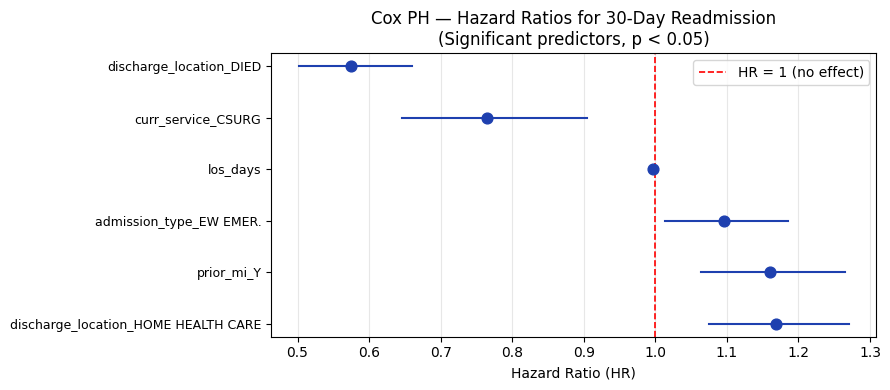

In [99]:
import matplotlib.pyplot as plt

vars_to_plot = hr_sig.index.tolist()
hrs    = hr_sig["HR"].values
lowers = hr_sig["HR_lower_95"].values
uppers = hr_sig["HR_upper_95"].values

fig, ax = plt.subplots(figsize=(9, max(4, len(vars_to_plot) * 0.4)))

y_pos = range(len(vars_to_plot))
ax.scatter(hrs, list(y_pos), color="#1e40af", zorder=3, s=60)
for i, (lo, hi) in enumerate(zip(lowers, uppers)):
    ax.plot([lo, hi], [i, i], color="#1e40af", linewidth=1.5, zorder=2)

ax.axvline(x=1.0, color="red", linestyle="--", linewidth=1.2, label="HR = 1 (no effect)")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(vars_to_plot, fontsize=9)
ax.set_xlabel("Hazard Ratio (HR)")
ax.set_title("Cox PH — Hazard Ratios for 30-Day Readmission\n(Significant predictors, p < 0.05)", fontsize=12)
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

10.4 Proportional Hazards assumption check

In [100]:
results = proportional_hazard_test(cph, cox_encoded, time_transform="rank")
results.print_summary(decimals=4, model="untransformed")

# Exploratory Data Analysis

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lifelines import KaplanMeierFitter
from sklearn.metrics import roc_curve, precision_score
from sklearn.calibration import calibration_curve

plt.style.use("default")
sns.set(style="whitegrid")

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Raw summary table

In [102]:
summary_table = pd.DataFrame()

#Age
summary_table.loc["Age (mean ± SD)", "Value"] = (
    f"{MI_finaldf['age'].mean():.1f} ± {MI_finaldf['age'].std():.1f}"
)

In [103]:
#Gender
gender_counts = MI_finaldf['gender'].value_counts()
gender_pct = MI_finaldf['gender'].value_counts(normalize=True) * 100

summary_table.loc["Male, n (%)", "Value"] = (
    f"{gender_counts.get('M', 0)} ({gender_pct.get('M', 0):.1f}%)"
)
summary_table.loc["Female, n (%)", "Value"] = (
    f"{gender_counts.get('F', 0)} ({gender_pct.get('F', 0):.1f}%)"
)

In [104]:
#Weekend admission
weekend_counts = MI_finaldf['admit_weekend'].value_counts()
weekend_pct = MI_finaldf['admit_weekend'].value_counts(normalize=True) * 100

summary_table.loc["Weekend admission, n (%)", "Value"] = (
    f"{weekend_counts.get('Weekend', 0)} ({weekend_pct.get('Weekend', 0):.1f}%)"
)

In [105]:
#Prior MI
prior_counts = MI_finaldf['prior_mi'].value_counts()
prior_pct = MI_finaldf['prior_mi'].value_counts(normalize=True) * 100

summary_table.loc["Prior MI, n (%)", "Value"] = (
    f"{prior_counts.get(1, 0)} ({prior_pct.get(1, 0):.1f}%)"
)

C:\Users\User\AppData\Local\Temp\ipykernel_5696\1265863197.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{prior_counts.get(1, 0)} ({prior_pct.get(1, 0):.1f}%)"


In [106]:
#Number of diagnoses at admission
summary_table.loc["No. diagnoses at admission (mean ± SD)", "Value"] = (
    f"{MI_finaldf['num_diagnoses_at_admission'].mean():.1f} ± "
    f"{MI_finaldf['num_diagnoses_at_admission'].std():.1f}"
)

In [107]:
#Admission type
admission_counts = MI_finaldf['admission_type'].value_counts()
admission_pct = MI_finaldf['admission_type'].value_counts(normalize=True) * 100

for cat in admission_counts.index:
    summary_table.loc[f"Admission: {cat}, n (%)", "Value"] = (
        f"{admission_counts[cat]} ({admission_pct[cat]:.1f}%)"
    )

In [108]:
#Curr_service (top 5)
service_counts = MI_finaldf['curr_service'].value_counts().head(5)
service_pct = MI_finaldf['curr_service'].value_counts(normalize=True).head(5) * 100

for svc in service_counts.index:
    summary_table.loc[f"Service: {svc}, n (%)", "Value"] = (
        f"{service_counts[svc]} ({service_pct[svc]:.1f}%)"
    )

In [109]:
#LOS distribution
los_counts = MI_finaldf['los_cat'].value_counts()
los_pct = MI_finaldf['los_cat'].value_counts(normalize=True) * 100

for cat in los_counts.index:
    summary_table.loc[f"LOS {cat}, n (%)", "Value"] = (
        f"{los_counts[cat]} ({los_pct[cat]:.1f}%)"
    )

In [110]:
#In-hospital mortality
mort_counts = MI_finaldf['hospital_expire_flag'].value_counts()
mort_pct = MI_finaldf['hospital_expire_flag'].value_counts(normalize=True) * 100

summary_table.loc["Mortality (1), n (%)", "Value"] = (
    f"{mort_counts.get(1, 0)} ({mort_pct.get(1, 0):.1f}%)"
)

In [111]:
#30-day readmission
read_counts = MI_finaldf['readmit_30d'].value_counts()
read_pct = MI_finaldf['readmit_30d'].value_counts(normalize=True) * 100

summary_table.loc["Readmission (1), n (%)", "Value"] = (
    f"{read_counts.get(1, 0)} ({read_pct.get(1, 0):.1f}%)"
)

In [112]:
#DRG severity > 2
sev_flag = (MI_finaldf['drg_severity'] > 2).sum()
sev_pct = (MI_finaldf['drg_severity'] > 2).mean() * 100

summary_table.loc["DRG severity > 2, n (%)", "Value"] = (
    f"{sev_flag} ({sev_pct:.1f}%)"
)

In [113]:
#DRG Mortality > 2
sev_flag = (MI_finaldf['drg_mortality'] > 2).sum()
sev_pct = (MI_finaldf['drg_mortality'] > 2).mean() * 100

summary_table.loc["DRG mortality > 2, n (%)", "Value"] = (
    f"{sev_flag} ({sev_pct:.1f}%)"
)

In [114]:
#Procedure count > 1
proc_flag = (MI_finaldf['procedure_count'] > 1).sum()
proc_pct = (MI_finaldf['procedure_count'] > 1).mean() * 100

summary_table.loc["Procedure count > 1, n (%)", "Value"] = (
    f"{proc_flag} ({proc_pct:.1f}%)"
)

In [206]:
#High-risk cardiac procedure
card_flag = MI_finaldf['cardiac_proc_flag'].sum()
card_pct = MI_finaldf['cardiac_proc_flag'].mean() * 100

summary_table.loc["High-risk cardiac procedure, n (%)", "Value"] = (
    f"{card_flag} ({card_pct:.1f}%)"
)


In [207]:
#LOS mean (+/-) SD
summary_table.loc["LOS (mean ± SD), days", "Value"] = (
    f"{MI_finaldf['los_days'].mean():.1f} ± {MI_finaldf['los_days'].std():.1f}"
)

#In-hospital mortality
summary_table.loc["In-hospital mortality, n (%)", "Value"] = (
    f"{MI_finaldf['hospital_expire_flag'].sum()} ({MI_finaldf['hospital_expire_flag'].mean()*100:.1f}%)"
)

#30-day readmission
summary_table.loc["30-day readmission, n (%)", "Value"] = (
    f"{MI_finaldf['readmit_30d'].sum()} ({MI_finaldf['readmit_30d'].mean()*100:.1f}%)"
)

summary_table

,Value
Age (mean ± SD),68.9 ± 13.5
"Male, n (%)",10204 (61.7%)
"Female, n (%)",6333 (38.3%)
"Weekend admission, n (%)",4765 (28.8%)
"Prior MI, n (%)",3385 (20.5%)
No. diagnoses at admission (mean ± SD),17.5 ± 8.8
"Admission: EW EMER., n (%)",6921 (41.9%)
"Admission: URGENT, n (%)",4402 (26.6%)
"Admission: OBSERVATION ADMIT, n (%)",3969 (24.0%)
"Admission: DIRECT EMER., n (%)",473 (2.9%)


2. Class Distribution plots

2.1 LOS Distribution

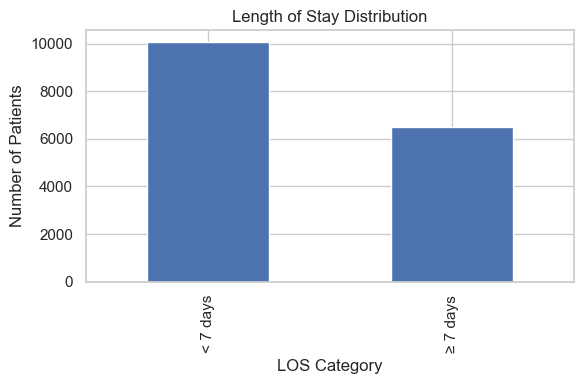

In [116]:
plt.figure(figsize=(6,4))
MI_finaldf['los_cat'].value_counts().plot(kind='bar')

plt.title("Length of Stay Distribution")
plt.xlabel("LOS Category")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

2.2 Mortality Distribution

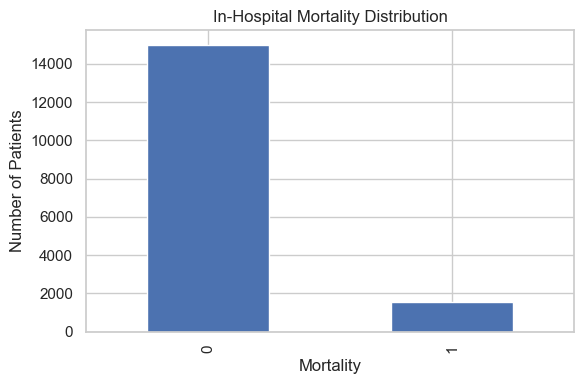

In [117]:
plt.figure(figsize=(6,4))
MI_finaldf['hospital_expire_flag'].value_counts().plot(kind='bar')

plt.title("In-Hospital Mortality Distribution")
plt.xlabel("Mortality")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

2.3 Readmission Distribution

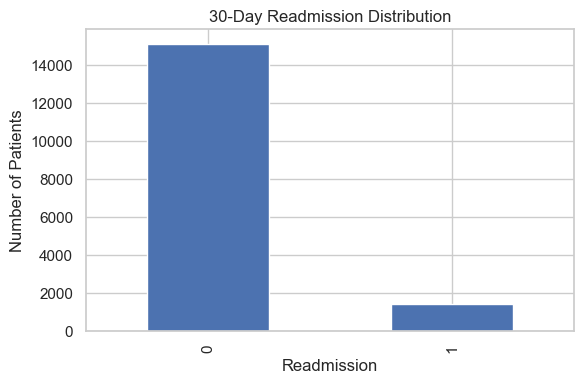

In [118]:
plt.figure(figsize=(6,4))
MI_finaldf['readmit_30d'].value_counts().plot(kind='bar')

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmission")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

3. Variable distribution plots

3.1 Age Distribution

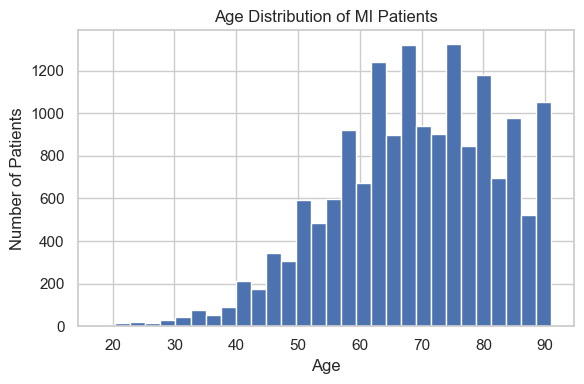

In [119]:
plt.figure(figsize=(6,4))
plt.hist(MI_finaldf['age'], bins=30)

plt.title("Age Distribution of MI Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

3.2 Number of Diagnoses Distribution

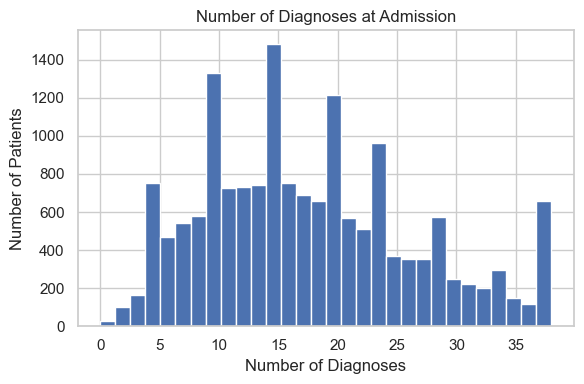

In [120]:
plt.figure(figsize=(6,4))
plt.hist(MI_finaldf['num_diagnoses_at_admission'], bins=30)

plt.title("Number of Diagnoses at Admission")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

3.3 Top Clinical Services

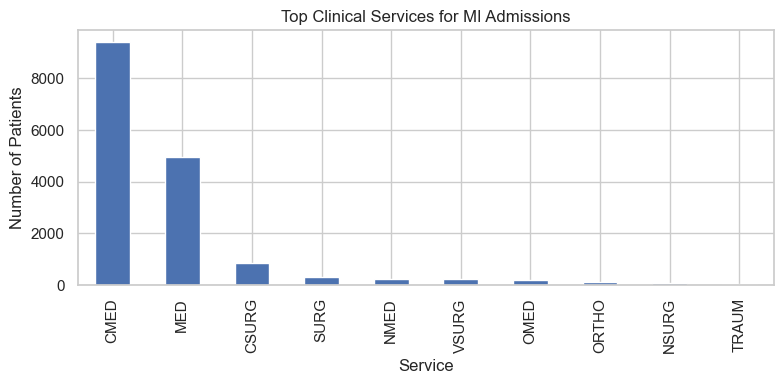

In [121]:
plt.figure(figsize=(8,4))
MI_finaldf['curr_service'].value_counts().head(10).plot(kind='bar')

plt.title("Top Clinical Services for MI Admissions")
plt.xlabel("Service")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

4. Relationship Analysis

4.1 LOS vs Admission Type

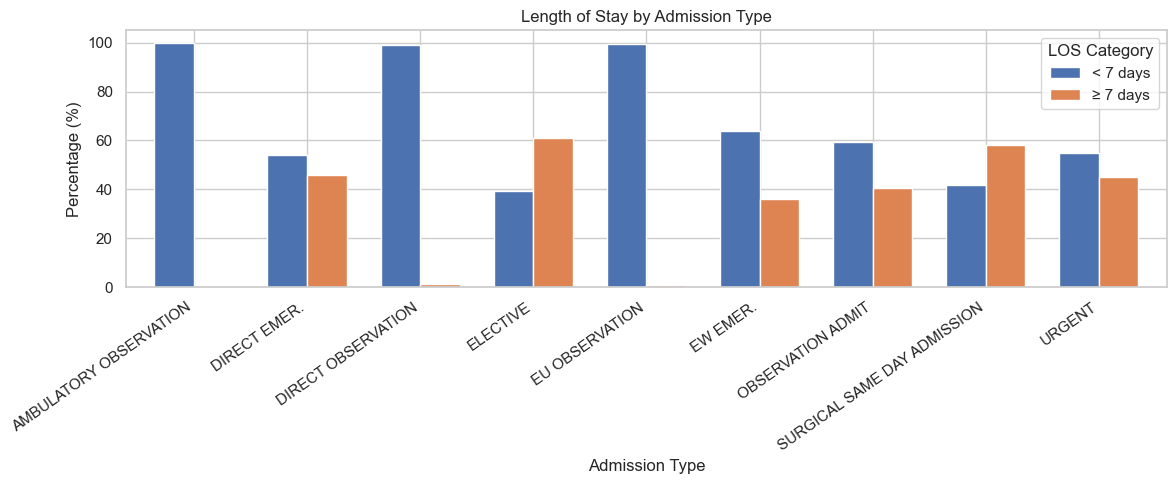

In [215]:
los_adm = pd.crosstab(MI_finaldf['admission_type'], MI_finaldf['los_cat'], normalize='index') * 100
los_adm.plot(kind='bar', figsize=(12, 5), width=0.7)

plt.title("Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Percentage (%)")
plt.legend(title="LOS Category")
plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.show()

4.2 Mortality vs Admission Type

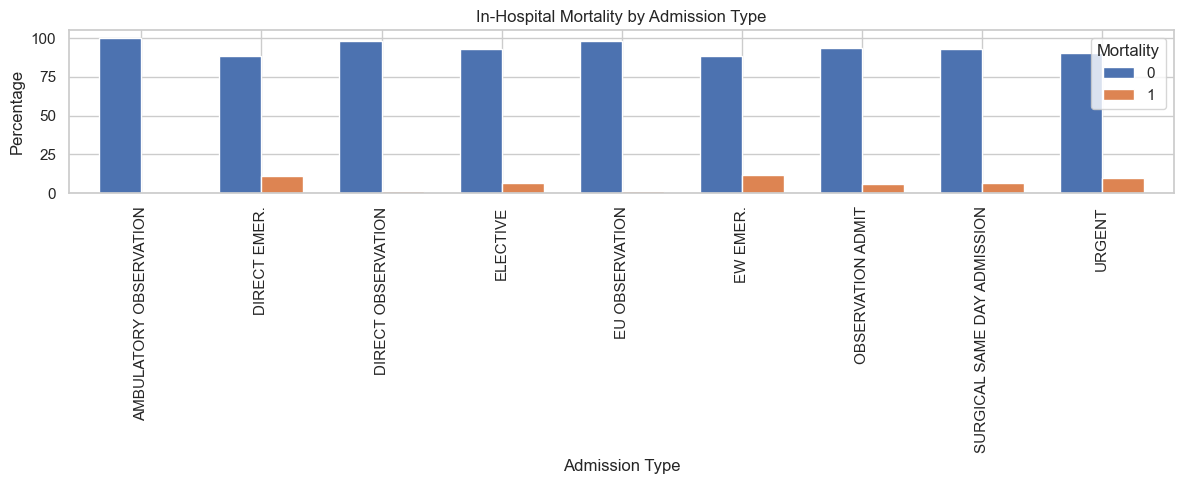

In [216]:
mort_adm = pd.crosstab(MI_finaldf['admission_type'], MI_finaldf['hospital_expire_flag'], normalize='index') * 100
mort_adm.plot(kind='bar', figsize=(12, 5), width=0.7)

plt.title("In-Hospital Mortality by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Percentage")
plt.legend(title="Mortality")

plt.tight_layout()
plt.show()

Readmission by admission type

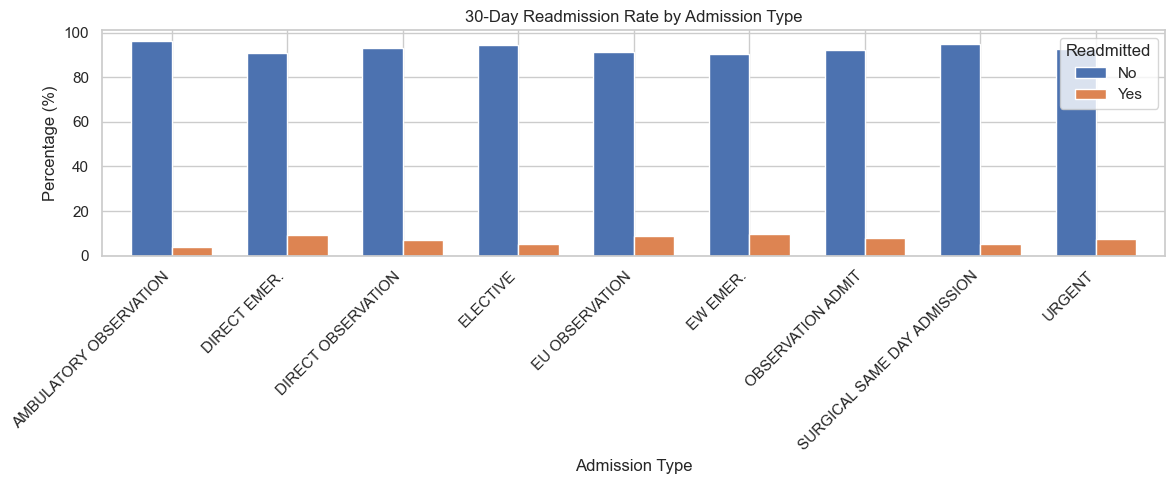

In [218]:
readmit_adm = pd.crosstab(MI_finaldf['admission_type'], MI_finaldf['readmit_30d'], normalize='index') * 100
readmit_adm.plot(kind='bar', figsize=(12, 5), width=0.7)

plt.title("30-Day Readmission Rate by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Readmitted", labels=["No", "Yes"])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

4.3 LOS vs Clinical Service (Top 5)

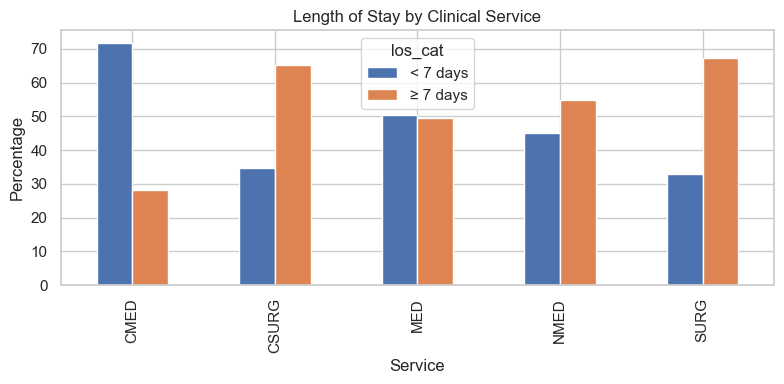

In [124]:
top_services = MI_finaldf['curr_service'].value_counts().head(5).index
subset = MI_finaldf[MI_finaldf['curr_service'].isin(top_services)]

los_service = pd.crosstab(subset['curr_service'], subset['los_cat'], normalize='index') * 100
los_service.plot(kind='bar', figsize=(8,4))

plt.title("Length of Stay by Clinical Service")
plt.xlabel("Service")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

4.4 Age by Readmission

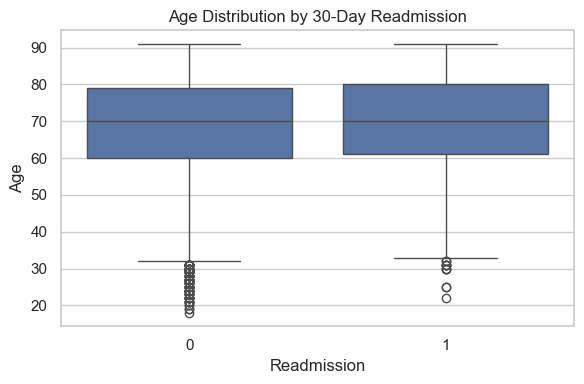

In [125]:
plt.figure(figsize=(6,4))
sns.boxplot(x=MI_finaldf['readmit_30d'], y=MI_finaldf['age'])

plt.title("Age Distribution by 30-Day Readmission")
plt.xlabel("Readmission")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

4.5 Age by LOS Category

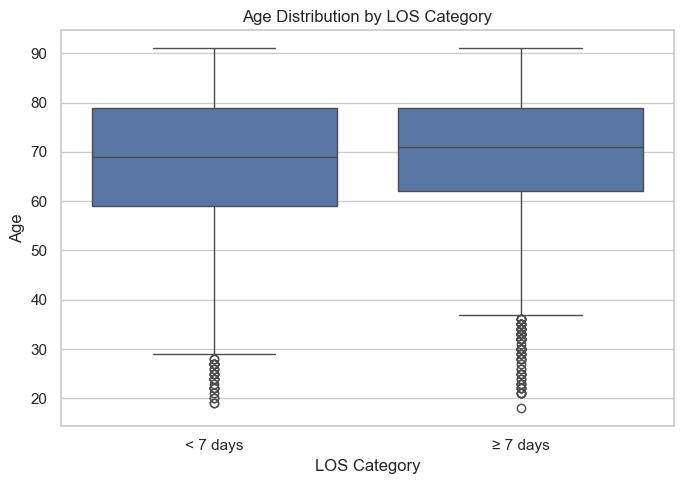

In [126]:
plt.figure(figsize=(7,5))
sns.boxplot(x=MI_finaldf['los_cat'], y=MI_finaldf['age'])

plt.title("Age Distribution by LOS Category")
plt.xlabel("LOS Category")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

4.6 MI Admissions Over Time

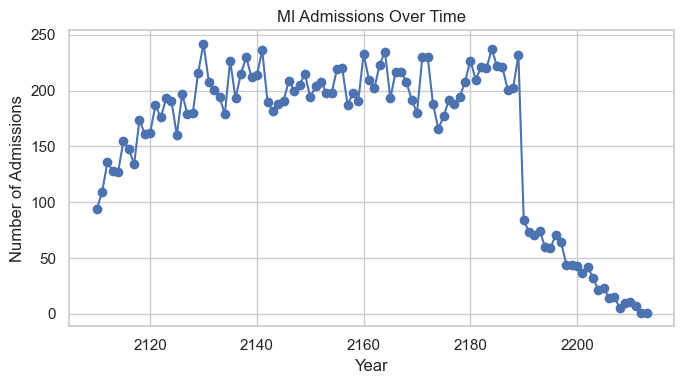

In [127]:
year_counts = MI_finaldf['admittime'].dt.year.value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("MI Admissions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")

plt.tight_layout()
plt.show()

4.7 30-Day Readmission Rate Over Time

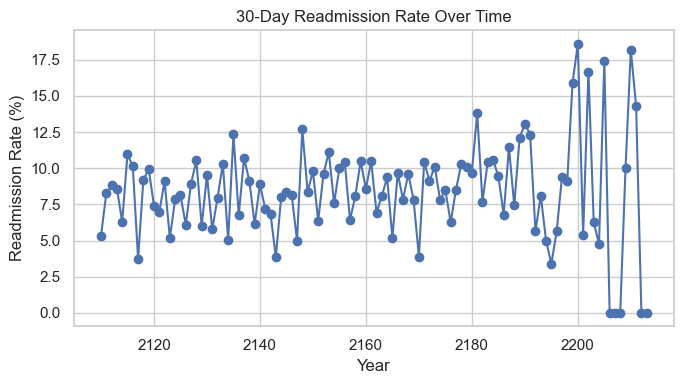

In [128]:
readm_year = MI_finaldf.groupby(MI_finaldf['admittime'].dt.year)['readmit_30d'].mean() * 100

plt.figure(figsize=(7, 4))
plt.plot(readm_year.index, readm_year.values, marker='o')
plt.title("30-Day Readmission Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

4.8 Day vs Night Admissions

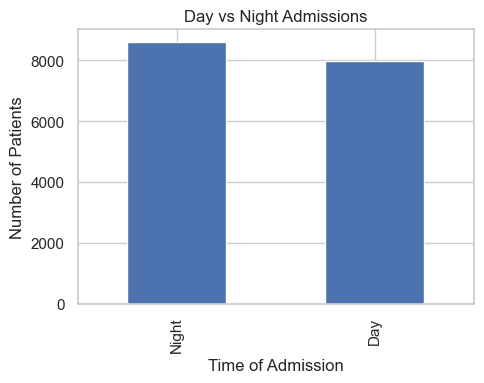

In [129]:
day_night = MI_finaldf['admittime'].dt.hour.apply(lambda h: "Day" if 7 <= h <= 18 else "Night")
day_night.value_counts().plot(kind='bar', figsize=(5, 4))

plt.title("Day vs Night Admissions")
plt.xlabel("Time of Admission")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

4.9 LOS: Weekend vs Weekday

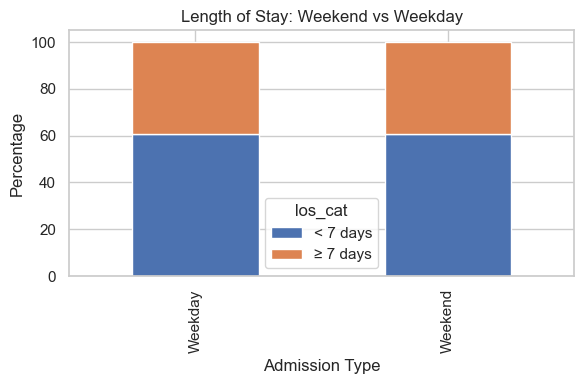

In [130]:
los_weekend = pd.crosstab(MI_finaldf['admit_weekend'], MI_finaldf['los_cat'], normalize='index') * 100
los_weekend.plot(kind='bar', stacked=True, figsize=(6,4))

plt.title("Length of Stay: Weekend vs Weekday")
plt.xlabel("Admission Type")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

4.10 Average Diagnoses by LOS and Gender

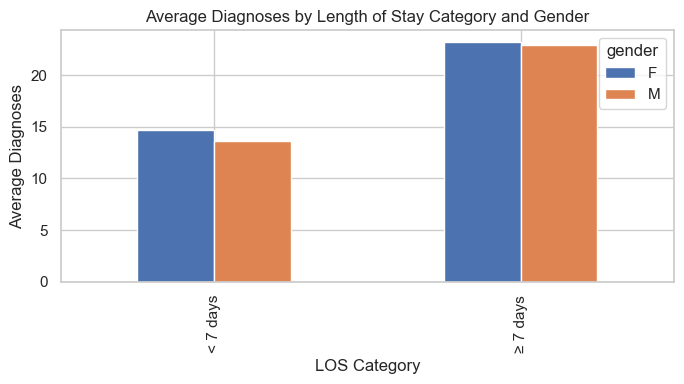

In [162]:
diag_los_gender = MI_finaldf.groupby(['los_cat','gender'])['num_diagnoses_at_admission'].mean().unstack()
diag_los_gender.plot(kind='bar', figsize=(7,4))

plt.title("Average Diagnoses by Length of Stay Category and Gender")
plt.xlabel("LOS Category")
plt.ylabel("Average Diagnoses")

plt.tight_layout()
plt.show()

5. Kaplan-Meier Curves

5.1 LOS by Gender (≤30 days)

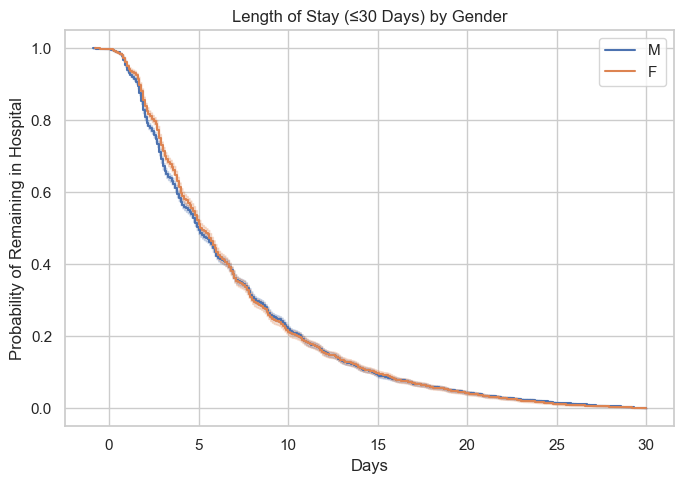

In [132]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(7, 5))

los_subset = MI_finaldf[MI_finaldf['los_days'] <= 30]
for gender in los_subset['gender'].unique():
    mask = los_subset['gender'] == gender
    kmf.fit(
        durations=los_subset.loc[mask, 'los_days'],
        event_observed=np.ones(mask.sum()),
        label=gender
    )
    kmf.plot()

plt.title("Length of Stay (≤30 Days) by Gender")
plt.xlabel("Days")
plt.ylabel("Probability of Remaining in Hospital")

plt.tight_layout()
plt.show()

5.2 30-Day Readmission by Weekend Admission

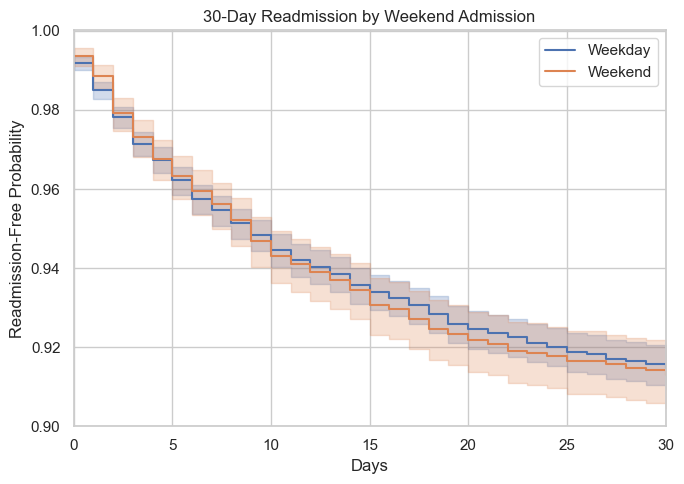

In [133]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(7, 5))

time_readmit = MI_finaldf['days_to_readmit'].fillna(30).clip(upper=30)

for weekend in MI_finaldf['admit_weekend'].unique():
    mask = MI_finaldf['admit_weekend'] == weekend
    kmf.fit(
        durations=time_readmit[mask],
        event_observed=MI_finaldf.loc[mask, 'readmit_30d'],
        label=str(weekend)
    )
    kmf.plot()

plt.title("30-Day Readmission by Weekend Admission")
plt.xlabel("Days")
plt.ylabel("Readmission-Free Probability")
plt.xlim(0, 30)

plt.tight_layout()
plt.show()

6. Outcome Analysis

6.1 Mortality by Age and Gender

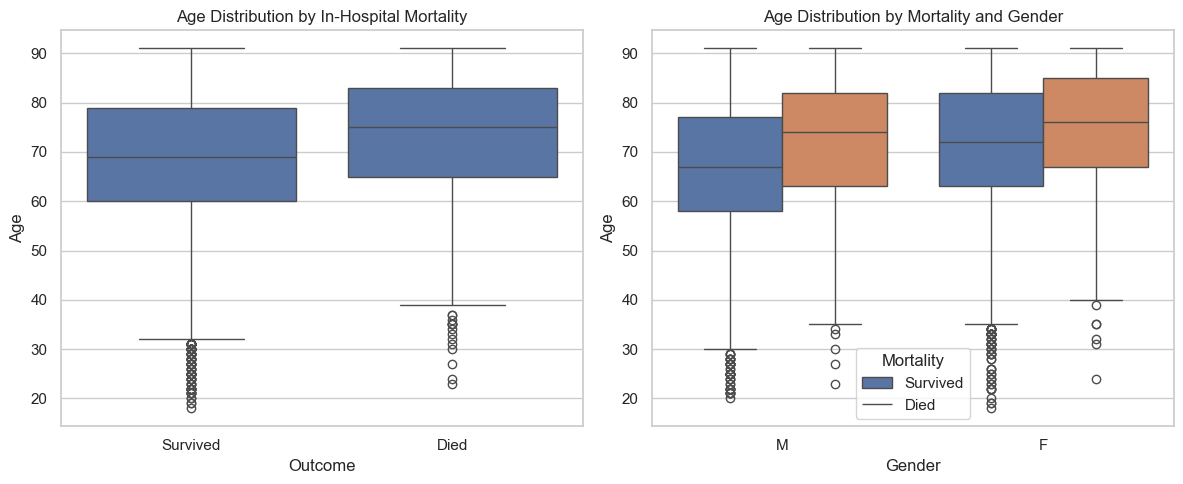

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=MI_finaldf["hospital_expire_flag"], y=MI_finaldf["age"], ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Survived", "Died"])
axes[0].set_title("Age Distribution by In-Hospital Mortality")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Age")

sns.boxplot(x=MI_finaldf["gender"], y=MI_finaldf["age"],
            hue=MI_finaldf["hospital_expire_flag"], ax=axes[1])
axes[1].set_title("Age Distribution by Mortality and Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Age")
axes[1].legend(title="Mortality", labels=["Survived", "Died"])

plt.tight_layout()
plt.show()

6.2 Readmission by Age and Gender

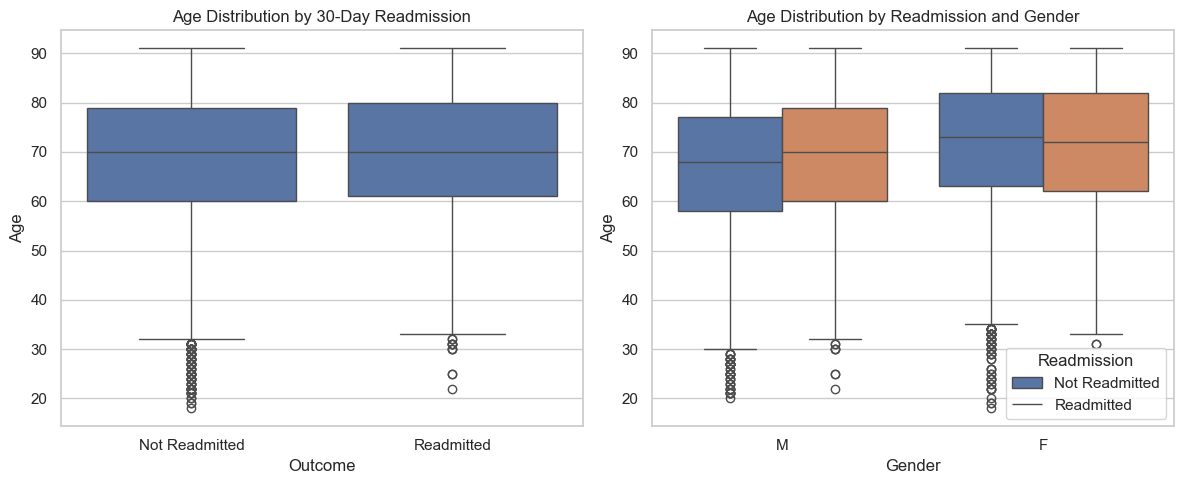

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=MI_finaldf["readmit_30d"], y=MI_finaldf["age"], ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Not Readmitted", "Readmitted"])
axes[0].set_title("Age Distribution by 30-Day Readmission")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Age")

sns.boxplot(x=MI_finaldf["gender"], y=MI_finaldf["age"],
            hue=MI_finaldf["readmit_30d"], ax=axes[1])
axes[1].set_title("Age Distribution by Readmission and Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Age")
axes[1].legend(title="Readmission", labels=["Not Readmitted", "Readmitted"])

plt.tight_layout()
plt.show()

6.3 Mortality by LOS - by Gender

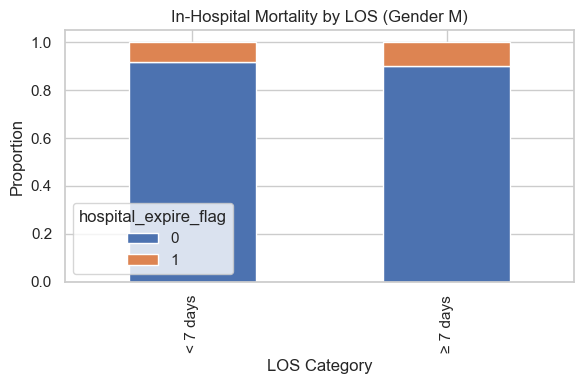

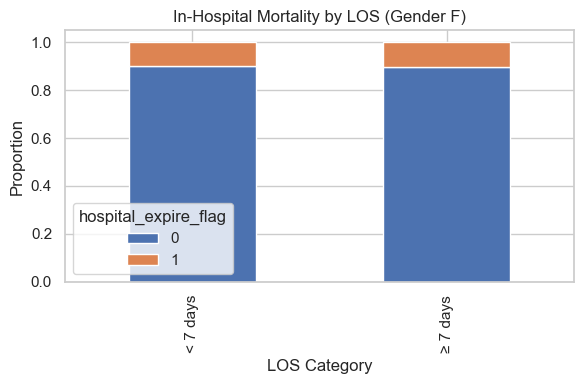

In [136]:
for gender in MI_finaldf['gender'].unique():
    pd.crosstab(
        MI_finaldf[MI_finaldf['gender'] == gender]['los_cat'],
        MI_finaldf[MI_finaldf['gender'] == gender]['hospital_expire_flag'],
        normalize='index'
    ).plot(kind='bar', stacked=True, figsize=(6, 4))
    
    plt.title(f"In-Hospital Mortality by LOS (Gender {gender})")
    plt.xlabel("LOS Category")
    plt.ylabel("Proportion")
    
    plt.tight_layout()
    plt.show()

6.4 Readmission by LOS - by Gender

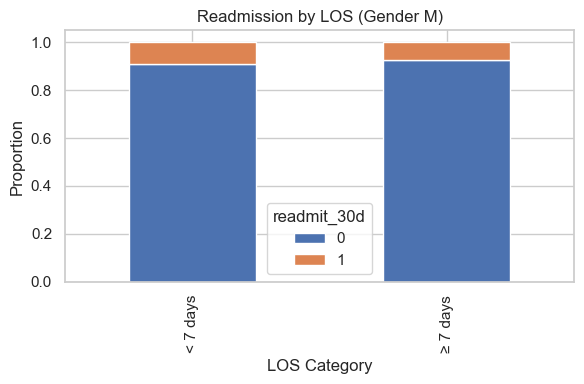

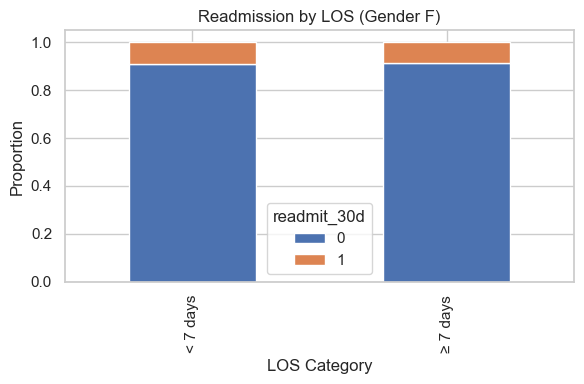

In [137]:
for gender in MI_finaldf['gender'].unique():
    pd.crosstab(
        MI_finaldf[MI_finaldf['gender'] == gender]['los_cat'],
        MI_finaldf[MI_finaldf['gender'] == gender]['readmit_30d'],
        normalize='index'
    ).plot(kind='bar', stacked=True, figsize=(6, 4))
    
    plt.title(f"Readmission by LOS (Gender {gender})")
    plt.xlabel("LOS Category")
    plt.ylabel("Proportion")
    
    plt.tight_layout()
    plt.show()

# Model Evaluation

1. Model Performance Visuals

In [186]:
def get_metrics(model, X_test, y_test_bin, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "ROC-AUC":  round(roc_auc_score(y_test_bin, y_prob), 4),
        "Accuracy": round(accuracy_score(y_test_bin, y_pred), 4),
        "Recall":   round(recall_score(y_test_bin, y_pred, zero_division=0), 4),
    }

1.1 Model Comparison Table - LOS

In [187]:
los_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Type": "Baseline", **get_metrics(logreg_los,          X_test_enc_los, y_test_los_bin)},
    {"Model": "Decision Tree",       "Type": "Baseline", **get_metrics(decisiontree_los,     X_test_enc_los, y_test_los_bin)},
    {"Model": "Random Forest",       "Type": "Baseline", **get_metrics(randomforest_los,     X_test_enc_los, y_test_los_bin)},
    {"Model": "Gradient Boosting",   "Type": "Baseline", **get_metrics(gradientboosting_los, X_test_enc_los, y_test_los_bin)},
    {"Model": "CatBoost",            "Type": "Baseline", **get_metrics(catboost_los,         X_test_enc_los, y_test_los_bin)},
    {"Model": "SVM",                 "Type": "Baseline", **get_metrics(svm_los,              X_test_enc_los, y_test_los_bin)},
    {"Model": "Logistic Regression", "Type": "Tuned",    **get_metrics(best_lr_los,          X_test_enc_los, y_test_los_bin)},
    {"Model": "Gradient Boosting",   "Type": "Tuned",    **get_metrics(best_gb_los,          X_test_enc_los, y_test_los_bin)},
    {"Model": "CatBoost",            "Type": "Tuned",    **get_metrics(best_cb_los,          X_test_enc_los, y_test_los_bin)},
]).set_index(["Model", "Type"])

los_comparison.loc[("CatBoost", "Tuned"), "ROC-AUC 95% CI"] = "0.8148 – 0.8427"

print("LOS Model Comparison:")
los_comparison

LOS Model Comparison:


,,ROC-AUC,Accuracy,Recall,ROC-AUC 95% CI
Model,Type,,,,
Logistic Regression,Baseline,0.8278,0.7476,0.7267,NaN
Decision Tree,Baseline,0.8140,0.7388,0.7506,NaN
Random Forest,Baseline,0.8184,0.7351,0.7883,NaN
Gradient Boosting,Baseline,0.8283,0.7580,0.6390,NaN
CatBoost,Baseline,0.8228,0.7482,0.6289,NaN
SVM,Baseline,0.8140,0.7498,0.6374,NaN
Logistic Regression,Tuned,0.8278,0.7489,0.7283,NaN
Gradient Boosting,Tuned,0.8278,0.7571,0.6297,NaN
CatBoost,Tuned,0.8288,0.7556,0.6359,0.8148 – 0.8427


1.2 Model Comparison Table - Admission Mortality

In [188]:
mort_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Type": "Baseline", **get_metrics(mort_lr,      X_test_enc_mort, y_test_mort)},
    {"Model": "Random Forest",       "Type": "Baseline", **get_metrics(mort_rf,      X_test_enc_mort, y_test_mort)},
    {"Model": "Gradient Boosting",   "Type": "Baseline", **get_metrics(mort_gb,      X_test_enc_mort, y_test_mort)},
    {"Model": "CatBoost",            "Type": "Baseline", **get_metrics(mort_cb,      X_test_enc_mort, y_test_mort)},
    {"Model": "Logistic Regression", "Type": "Tuned",    **get_metrics(best_lr_mort, X_test_enc_mort, y_test_mort)},
    {"Model": "Random Forest",       "Type": "Tuned",    **get_metrics(best_rf_mort, X_test_enc_mort, y_test_mort)},
]).set_index(["Model", "Type"])

mort_comparison.loc[("Random Forest", "Baseline"), "ROC-AUC 95% CI"] = "0.7232 – 0.7715"

print("Admission Mortality Model Comparison:")
mort_comparison

Admission Mortality Model Comparison:


,,ROC-AUC,Accuracy,Recall,ROC-AUC 95% CI
Model,Type,,,,
Logistic Regression,Baseline,0.7410,0.6937,0.6632,NaN
Random Forest,Baseline,0.7474,0.6873,0.6701,0.7232 – 0.7715
Gradient Boosting,Baseline,0.7443,0.9122,0.0035,NaN
CatBoost,Baseline,0.7365,0.9107,0.0208,NaN
Logistic Regression,Tuned,0.7423,0.6946,0.6701,NaN
Random Forest,Tuned,0.7474,0.6870,0.6701,NaN


1.3 Model Comparison Table - Post-Admission Mortality

In [189]:
mort2_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Type": "Baseline", **get_metrics(mort2_lr,      X_test_enc_mort2, y_test_mort2)},
    {"Model": "Random Forest",       "Type": "Baseline", **get_metrics(mort2_rf,      X_test_enc_mort2, y_test_mort2)},
    {"Model": "Random Forest",       "Type": "Tuned",    **get_metrics(best_rf_mort2, X_test_enc_mort2, y_test_mort2)},
]).set_index(["Model", "Type"])

mort2_comparison.loc[("Random Forest", "Baseline"), "ROC-AUC 95% CI"] = "0.7984 – 0.8403"

print("Post-Admission Mortality Model Comparison:")
mort2_comparison

Post-Admission Mortality Model Comparison:


ROC-AUC  Accuracy  Recall   ROC-AUC 95% CI
Model               Type                                                
Logistic Regression Baseline   0.7846    0.7144  0.7535              NaN
Random Forest       Baseline   0.8198    0.7327  0.7951  0.7984 – 0.8403
                    Tuned      0.8216    0.7315  0.7951              NaN

1.4 Model Comparison Table - 30-Day Readmission

In [190]:
readmit_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Type": "Baseline", **get_metrics(readmit_lr,  X_test_enc_readmit, y_test_readmit)},
    {"Model": "Decision Tree",       "Type": "Baseline", **get_metrics(readmit_dt,  X_test_enc_readmit, y_test_readmit)},
    {"Model": "Random Forest",       "Type": "Baseline", **get_metrics(readmit_rf,  X_test_enc_readmit, y_test_readmit)},
    {"Model": "XGBoost",             "Type": "Baseline", **get_metrics(readmit_xgb, X_test_enc_readmit, y_test_readmit)},
]).set_index(["Model", "Type"])

readmit_comparison.loc[("XGBoost", "Baseline"), "ROC-AUC 95% CI"] = "0.6003 – 0.6655"

print("Readmission Model Comparison:")
readmit_comparison

Readmission Model Comparison:


,,ROC-AUC,Accuracy,Recall,ROC-AUC 95% CI
Model,Type,,,,
Logistic Regression,Baseline,0.6166,0.5084,0.6906,NaN
Decision Tree,Baseline,0.5906,0.5940,0.5288,NaN
Random Forest,Baseline,0.6237,0.6800,0.4748,NaN
XGBoost,Baseline,0.5034,0.9153,0.0000,0.6003 – 0.6655


2. SHAP Feature importance

2.1 SHAP - LOS (CatBoost)

C:\Users\User\AppData\Local\Temp\ipykernel_5696\2469060095.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_los, X_test_los_dense, feature_names=los_feature_names)


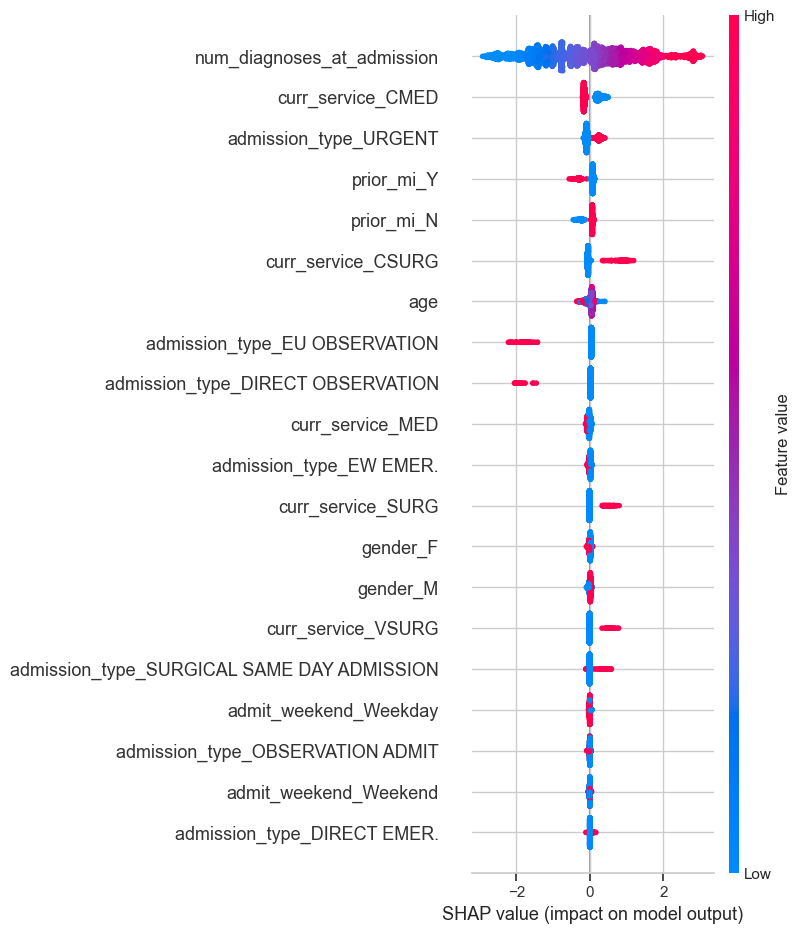

In [191]:
los_feature_names = (
    list(encoder_los.get_feature_names_out(cat_cols_los)) + num_cols_los
)

X_test_los_dense = pd.DataFrame(
    X_test_enc_los.toarray(),
    columns=los_feature_names
)

explainer_los    = shap.TreeExplainer(final_los_model)
shap_values_los  = explainer_los.shap_values(X_test_los_dense)

shap.summary_plot(shap_values_los, X_test_los_dense, feature_names=los_feature_names)

2.2 SHAP - Admission Mortality (Random Forest)

C:\Users\User\AppData\Local\Temp\ipykernel_5696\3213106090.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_plot, X_test_mort_dense, feature_names=mort_feature_names)


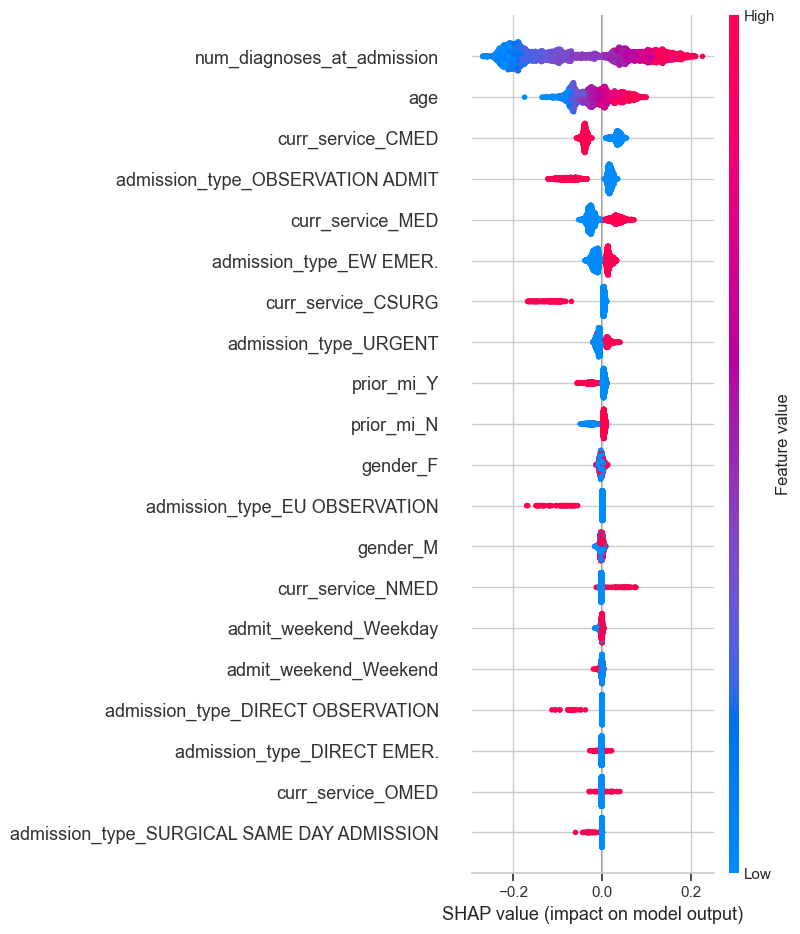

In [213]:
mort_feature_names = (
    list(encoder_mort.get_feature_names_out(cat_cols_mort)) + num_cols_mort
)

X_test_mort_dense = pd.DataFrame(
    X_test_enc_mort.toarray(),
    columns=mort_feature_names
)

explainer_mort  = shap.TreeExplainer(final_mortality_model)
shap_vals       = explainer_mort.shap_values(X_test_mort_dense)

if isinstance(shap_vals, list):
    shap_vals_plot = shap_vals[1]
else:
    shap_vals_plot = shap_vals[:, :, 1] if shap_vals.ndim == 3 else shap_vals

shap.summary_plot(shap_vals_plot, X_test_mort_dense, feature_names=mort_feature_names)

2.3 SHAP - Post-Admission Mortality (Random Forest)

C:\Users\User\AppData\Local\Temp\ipykernel_5696\3539292027.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


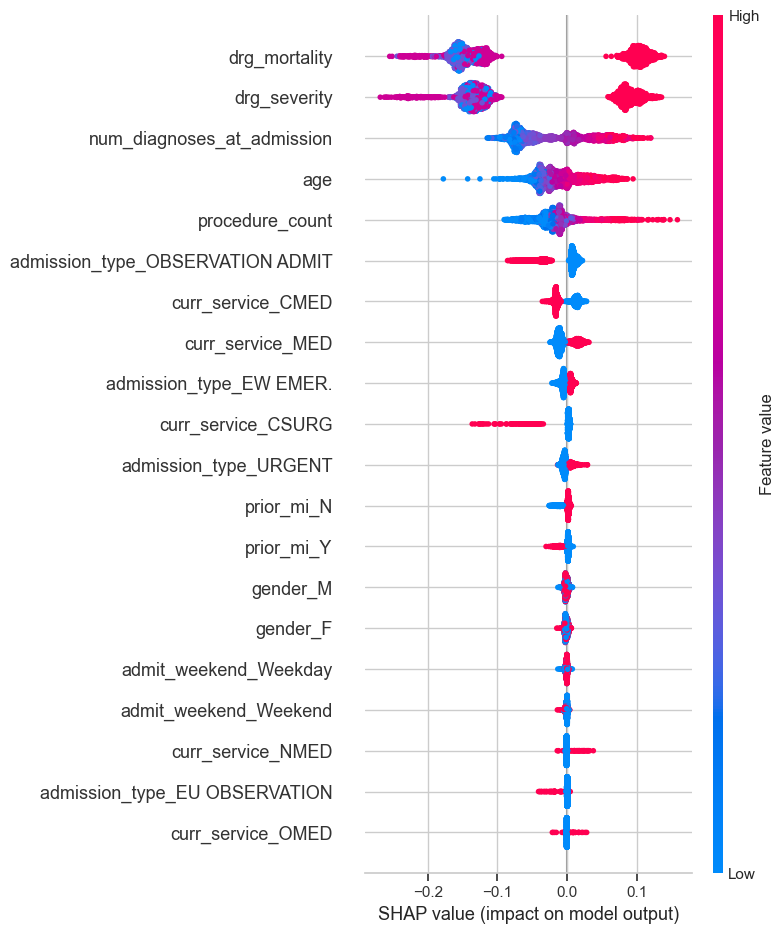

In [ ]:
mort2_feature_names = (
    list(encoder_mort2.get_feature_names_out(cat_cols_mort2)) + num_cols_mort2
)

X_test_mort2_dense = pd.DataFrame(
    X_test_enc_mort2.toarray(),
    columns=mort2_feature_names
)

explainer_mort2   = shap.TreeExplainer(final_mortality_post_model)
shap_values_mort2 = explainer_mort2.shap_values(X_test_mort2_dense)

if isinstance(shap_values_mort2, list):
    shap_plot_mort2 = shap_values_mort2[1]
else:
    shap_plot_mort2 = shap_values_mort2[:, :, 1]

shap.summary_plot(
    shap_plot_mort2,
    X_test_mort2_dense,
    feature_names=mort2_feature_names
)

2.4 SHAP - 30-Day Readmission (XGBoost)

C:\Users\User\AppData\Local\Temp\ipykernel_5696\3357793403.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


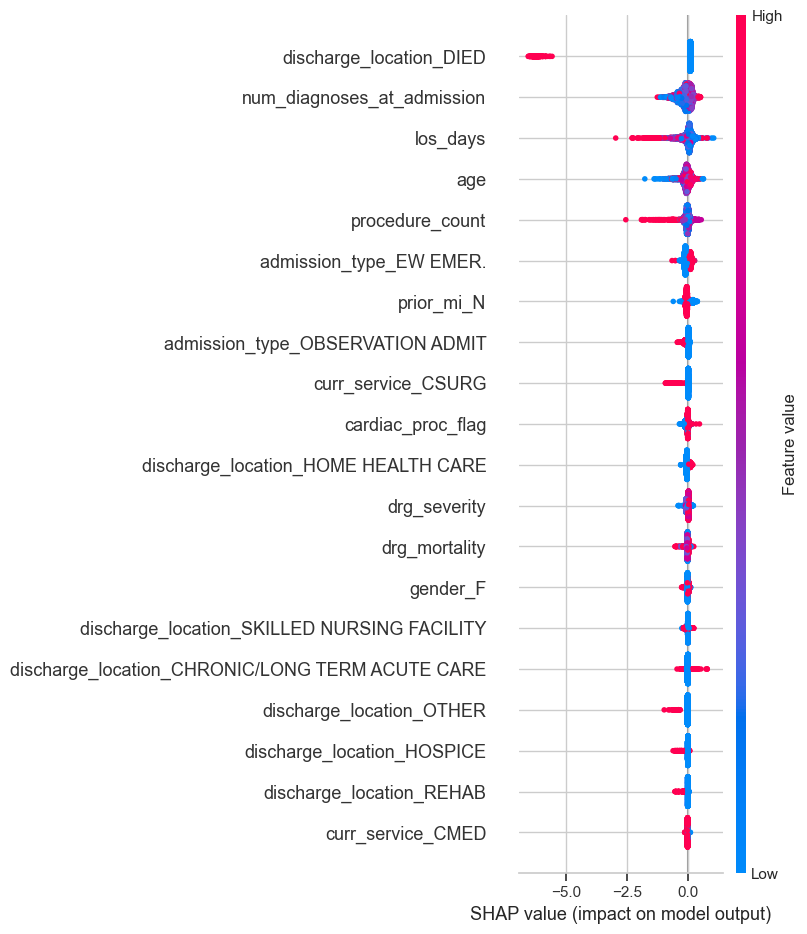

In [ ]:
readmit_feature_names = (
    list(encoder_readmit.get_feature_names_out(cat_cols_readmit)) + num_cols_readmit
)

X_test_readmit_dense_df = pd.DataFrame(
    X_test_dense_readmit,
    columns=readmit_feature_names
)

explainer_readmit    = shap.TreeExplainer(final_readmission_model)
shap_values_readmit  = explainer_readmit.shap_values(X_test_readmit_dense_df)

shap.summary_plot(
    shap_values_readmit,
    X_test_readmit_dense_df,
    feature_names=readmit_feature_names
)

In [196]:
# Mean absolute SHAP values - all four models

# LOS
shap_importance_los = pd.DataFrame({
    'Feature': los_feature_names,
    'Mean_SHAP': np.abs(shap_values_los).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(5)
print("Top 5 LOS Features (Mean Absolute SHAP):")
print(shap_importance_los.to_string(index=False))

# Admission Mortality
shap_importance_mort = pd.DataFrame({
    'Feature': mort_feature_names,
    'Mean_SHAP': np.abs(shap_vals_plot).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(5)
print("\nTop 5 Admission Mortality Features (Mean Absolute SHAP):")
print(shap_importance_mort.to_string(index=False))

# Post-Admission Mortality
shap_importance_mort2 = pd.DataFrame({
    'Feature': mort2_feature_names,
    'Mean_SHAP': np.abs(shap_plot_mort2).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(5)
print("\nTop 5 Post-Admission Mortality Features (Mean Absolute SHAP):")
print(shap_importance_mort2.to_string(index=False))

# Readmission
shap_importance_readmit = pd.DataFrame({
    'Feature': readmit_feature_names,
    'Mean_SHAP': np.abs(shap_values_readmit).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(5)
print("\nTop 5 Readmission Features (Mean Absolute SHAP):")
print(shap_importance_readmit.to_string(index=False))

Top 5 LOS Features (Mean Absolute SHAP):
                   Feature  Mean_SHAP
num_diagnoses_at_admission   1.095839
         curr_service_CMED   0.201865
     admission_type_URGENT   0.132196
                prior_mi_Y   0.127156
                prior_mi_N   0.101340

Top 5 Admission Mortality Features (Mean Absolute SHAP):
                         Feature  Mean_SHAP
      num_diagnoses_at_admission   0.131961
                             age   0.040278
               curr_service_CMED   0.037041
admission_type_OBSERVATION ADMIT   0.033008
                curr_service_MED   0.027949

Top 5 Post-Admission Mortality Features (Mean Absolute SHAP):
                   Feature  Mean_SHAP
             drg_mortality   0.130684
              drg_severity   0.120245
num_diagnoses_at_admission   0.052666
                       age   0.028043
           procedure_count   0.027712

Top 5 Readmission Features (Mean Absolute SHAP):
                   Feature  Mean_SHAP
   discharge_location_DIED   0

3. Final Model Evaluation

3.1 Final ROC-AUC Curves - All Models

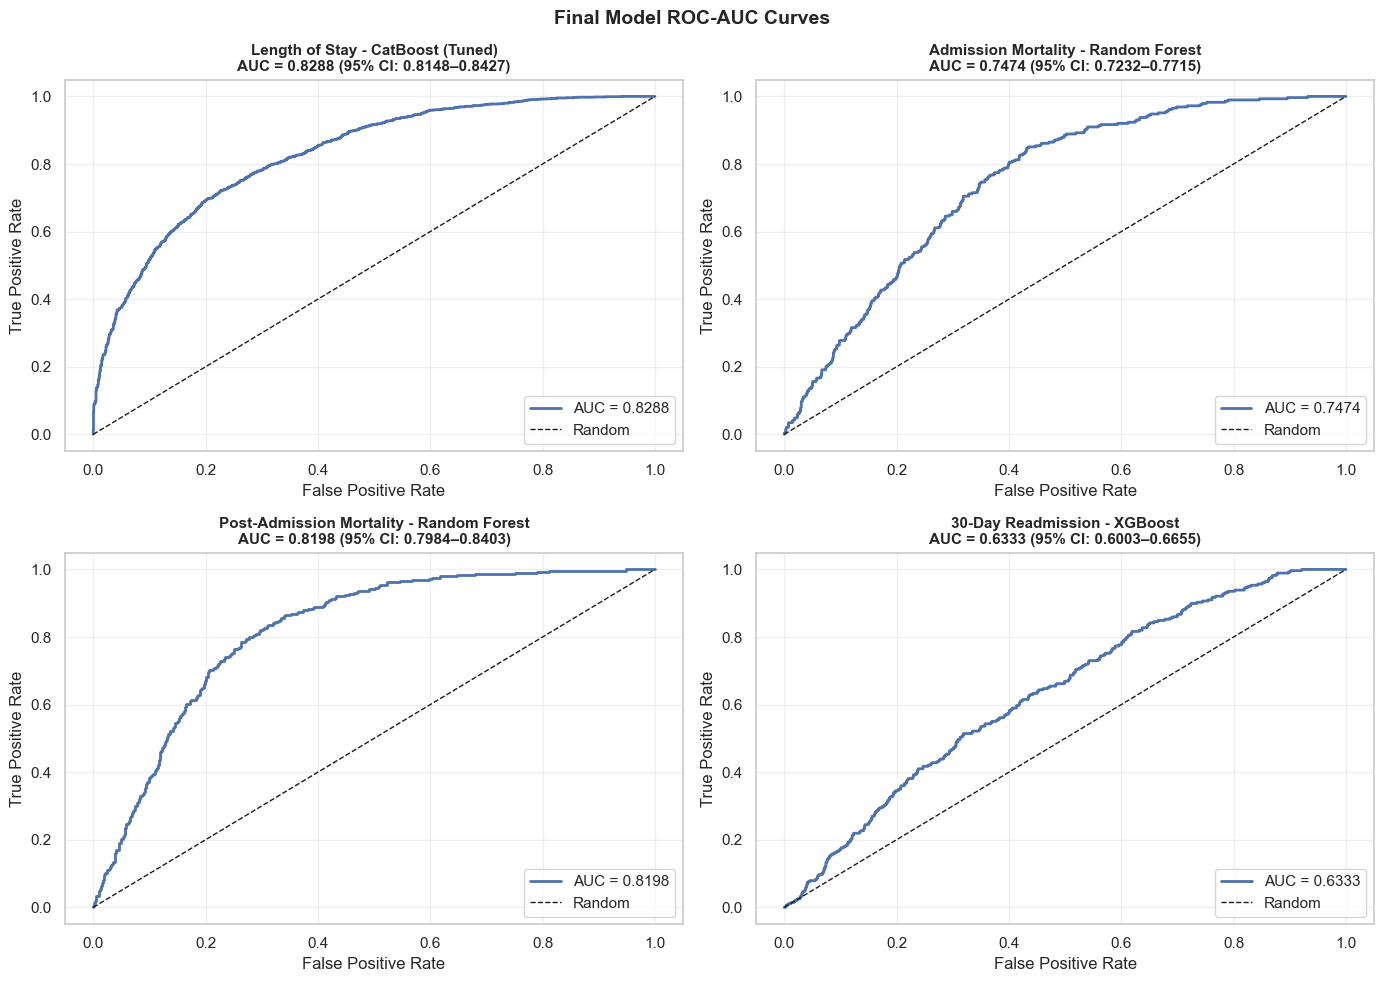

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_info = [
    ("Length of Stay - CatBoost (Tuned)\nAUC = 0.8288 (95% CI: 0.8148–0.8427)",
     y_test_los_bin, y_prob_final_los,     axes[0]),
    ("Admission Mortality - Random Forest\nAUC = 0.7474 (95% CI: 0.7232–0.7715)",
     y_test_mort,    y_prob_final_mort,    axes[1]),
    ("Post-Admission Mortality - Random Forest\nAUC = 0.8198 (95% CI: 0.7984–0.8403)",
     y_test_mort2,   y_prob_final_mort2,   axes[2]),
    ("30-Day Readmission - XGBoost\nAUC = 0.6333 (95% CI: 0.6003–0.6655)",
     y_test_readmit, y_prob_final_readmit, axes[3]),
]

for title, y_true, y_prob, ax in models_info:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.suptitle("Final Model ROC-AUC Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

3.2 Confusion Matrix Heatmaps - All Models

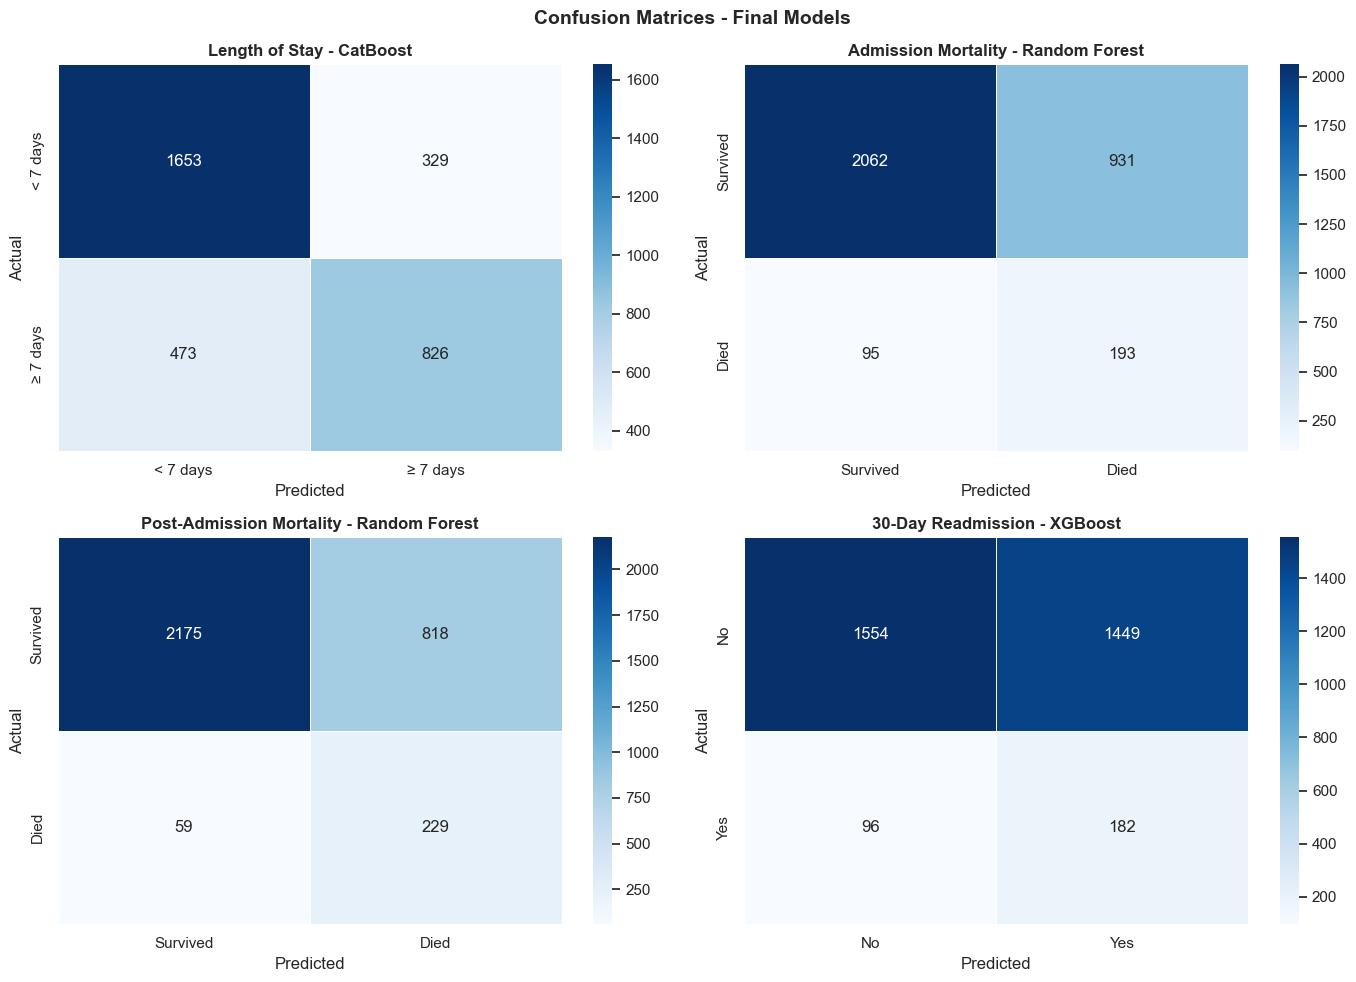

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cm_info = [
    ("Length of Stay - CatBoost",
     confusion_matrix(y_test_los,     y_pred_final_los),
     ["< 7 days", "≥ 7 days"], axes[0]),
    ("Admission Mortality - Random Forest",
     confusion_matrix(y_test_mort,    y_pred_final_mort),
     ["Survived", "Died"],     axes[1]),
    ("Post-Admission Mortality - Random Forest",
     confusion_matrix(y_test_mort2,   y_pred_final_mort2),
     ["Survived", "Died"],     axes[2]),
    ("30-Day Readmission - XGBoost",
     confusion_matrix(y_test_readmit, y_pred_final_readmit),
     ["No", "Yes"],            axes[3]),
]

for title, cm, labels, ax in cm_info:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices - Final Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

3.3 Calibration Curves - All Models

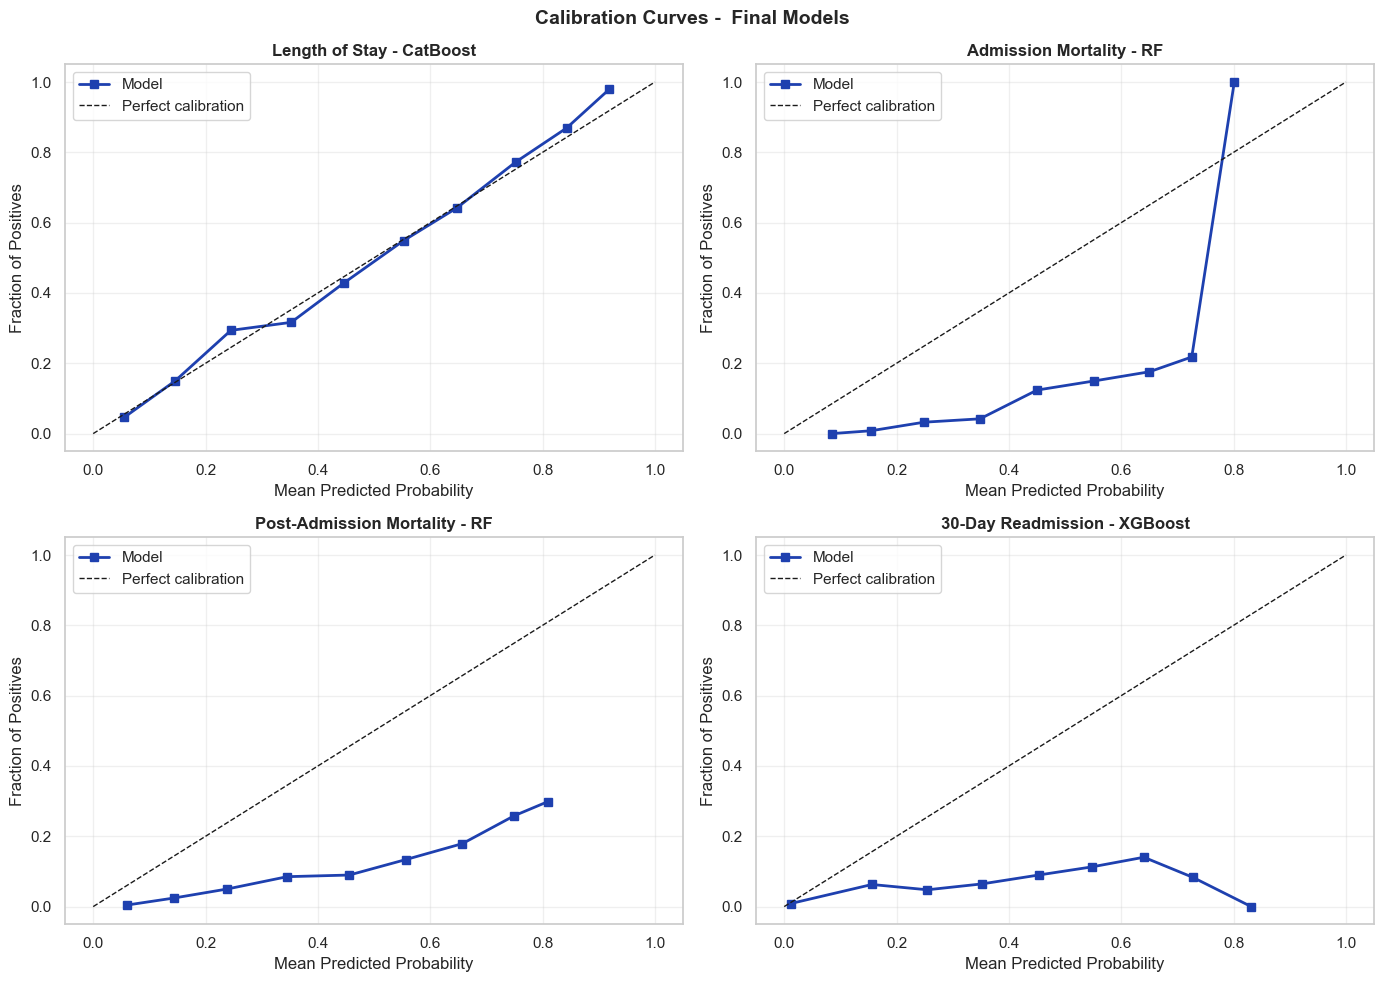

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cal_info = [
    ("Length of Stay - CatBoost",               y_test_los_bin, y_prob_final_los,     axes[0]),
    ("Admission Mortality - RF",      y_test_mort,    y_prob_final_mort,    axes[1]),
    ("Post-Admission Mortality - RF", y_test_mort2,   y_prob_final_mort2,   axes[2]),
    ("30-Day Readmission - XGBoost",  y_test_readmit, y_prob_final_readmit, axes[3]),
]

for title, y_true, y_prob, ax in cal_info:
    fraction_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ax.plot(mean_pred, fraction_pos, "s-", color="#1e40af", linewidth=2, label="Model")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Calibration Curves -  Final Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

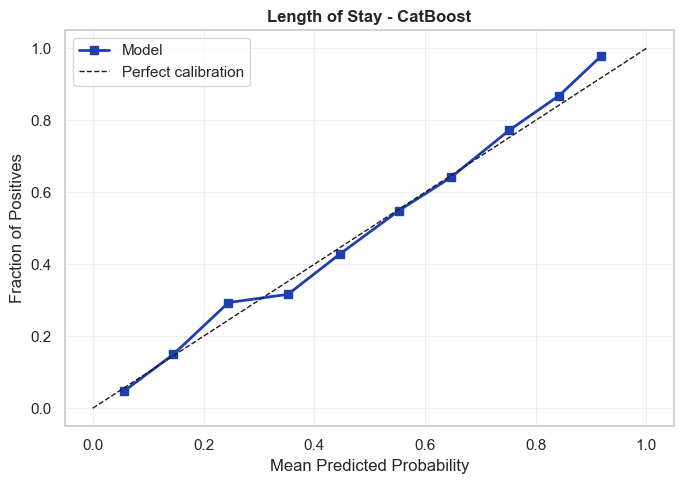

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# Only Length of Stay
title = "Length of Stay - CatBoost"
y_true = y_test_los_bin
y_prob = y_prob_final_los

fraction_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)

ax.plot(mean_pred, fraction_pos, "s-", color="#1e40af", linewidth=2, label="Model")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")

ax.set_title(title, fontsize=12, fontweight="bold")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

3.4 AUPRC

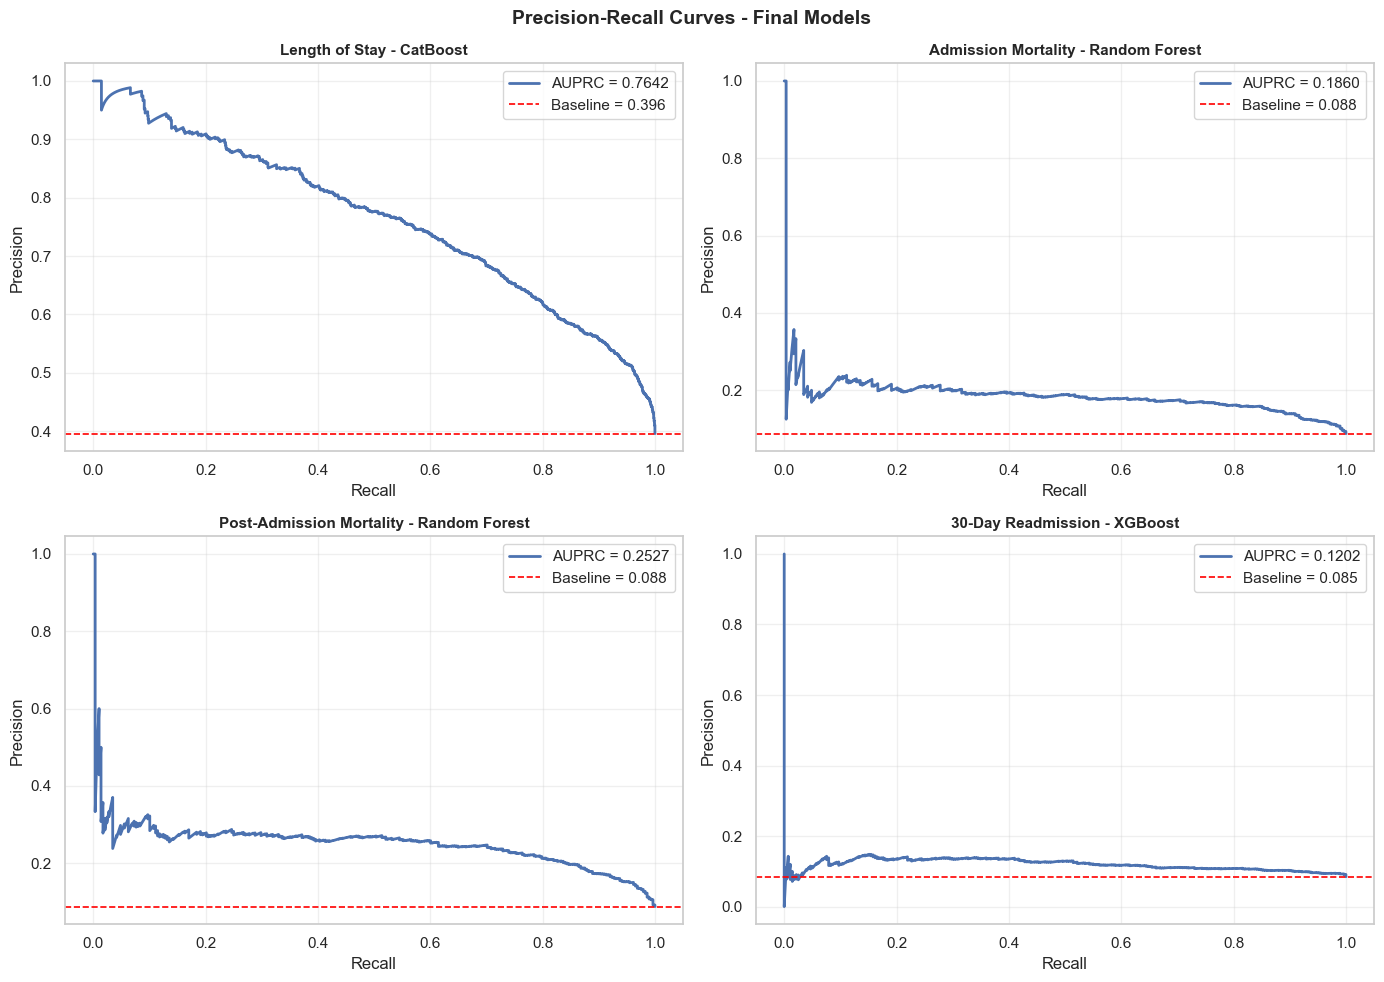

In [197]:
pr_info = [
    ("Length of Stay - CatBoost", y_test_los_bin, y_prob_final_los),
    ("Admission Mortality - Random Forest", y_test_mort, y_prob_final_mort),
    ("Post-Admission Mortality - Random Forest", y_test_mort2, y_prob_final_mort2),
    ("30-Day Readmission - XGBoost", y_test_readmit, y_prob_final_readmit),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for (title, y_true, y_prob), ax in zip(pr_info, axes):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()
    ax.plot(recall, precision, linewidth=2, label=f"AUPRC = {ap:.4f}")
    ax.axhline(y=baseline, color="red", linestyle="--", linewidth=1.2, label=f"Baseline = {baseline:.3f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

plt.suptitle("Precision-Recall Curves - Final Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

3.4 Decision tree for LOS

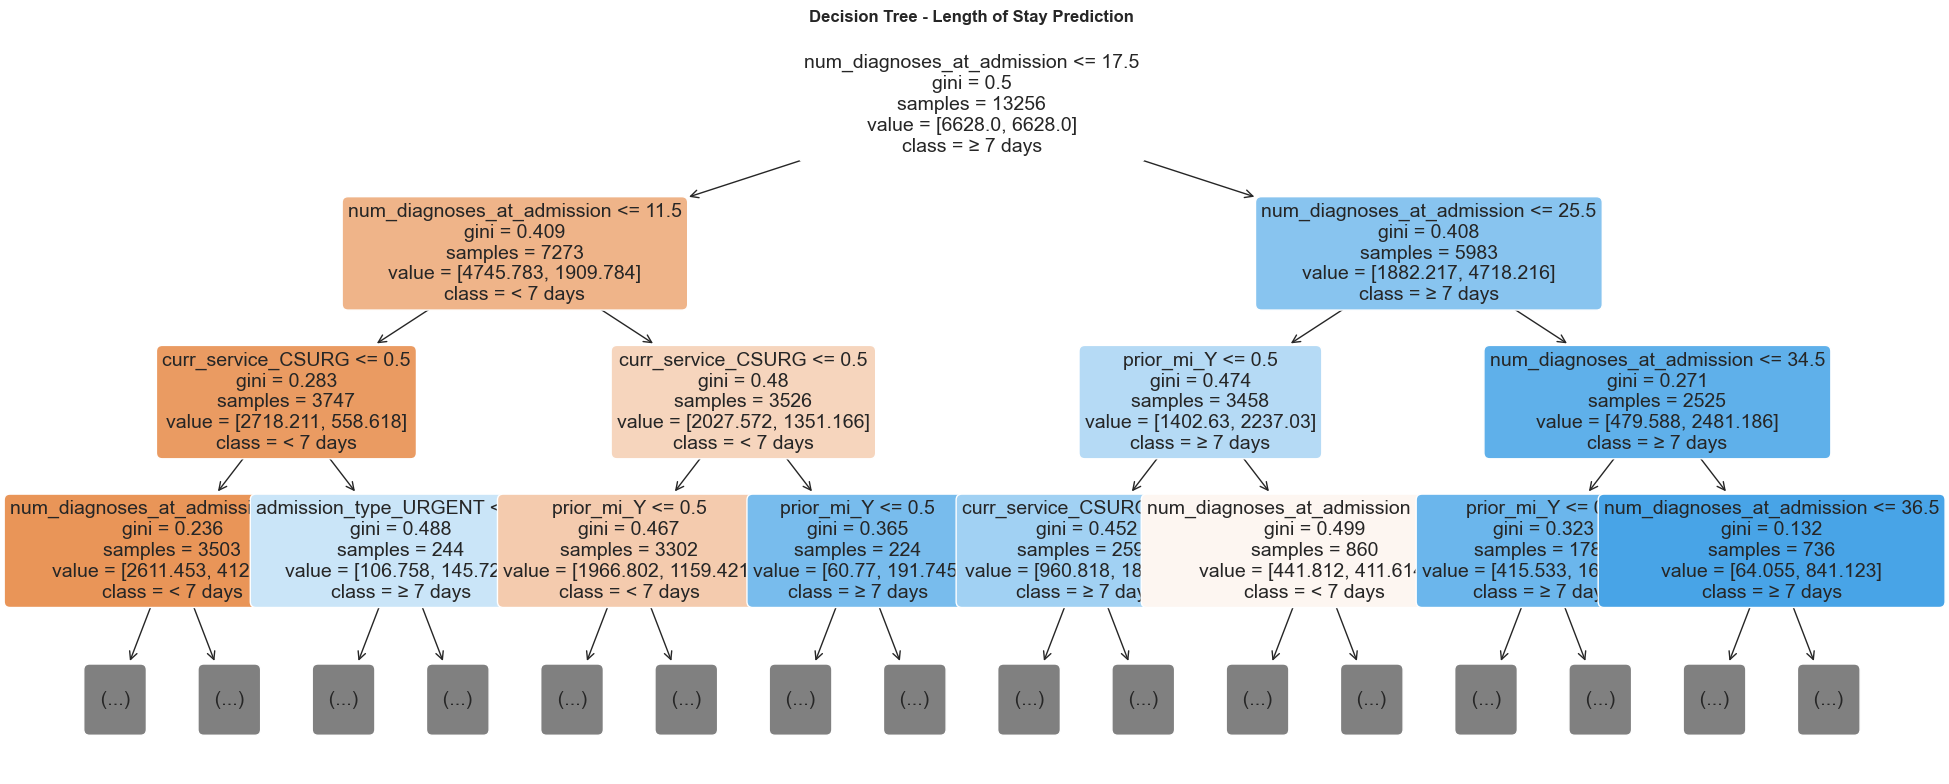

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))

plot_tree(
    decisiontree_los,
    feature_names=(
        list(encoder_los.get_feature_names_out(cat_cols_los)) + num_cols_los
    ),
    class_names=["< 7 days", "≥ 7 days"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=14
)

plt.title("Decision Tree - Length of Stay Prediction", fontweight="bold")
plt.tight_layout()
plt.show()

3.5 Decision Tree for 30 Day Readmission

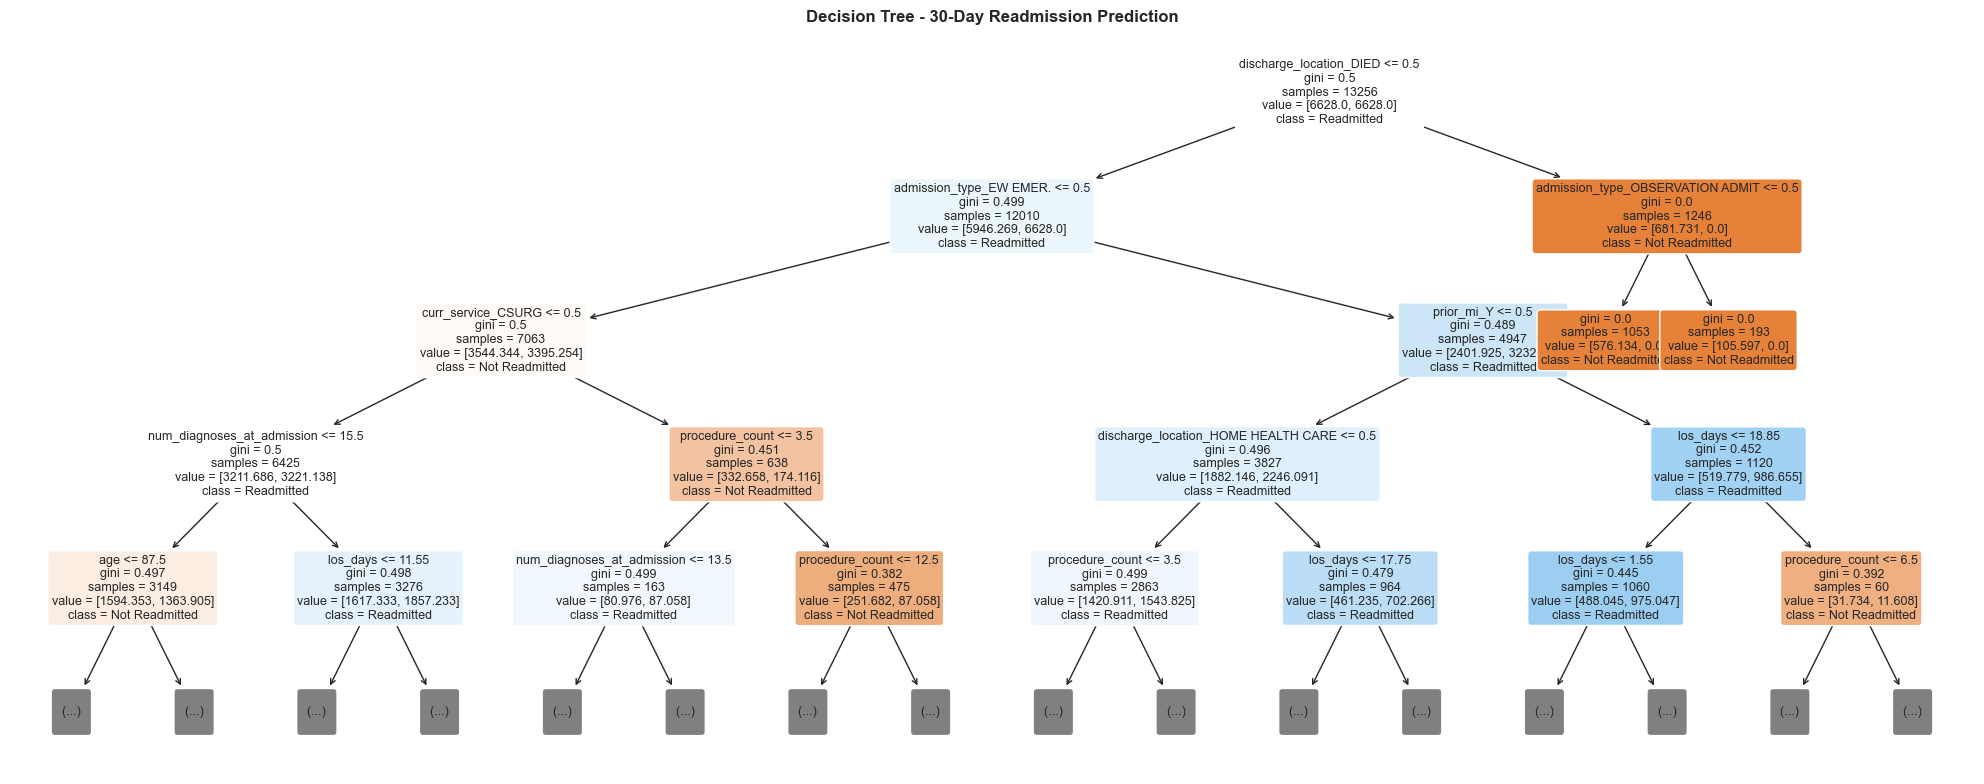

In [200]:
plt.figure(figsize=(20, 8))
plot_tree(
    readmit_dt,
    feature_names=(
        list(encoder_readmit.get_feature_names_out(cat_cols_readmit)) + num_cols_readmit
    ),
    class_names=["Not Readmitted", "Readmitted"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)
plt.title("Decision Tree - 30-Day Readmission Prediction", fontweight="bold")
plt.tight_layout()
plt.show()

# Other

In [ ]:

datasets = {
    "patients":        pd.read_csv("patients.csv/patients.csv"),
    "admissions":      pd.read_csv("admissions.csv/admissions.csv"),
    "services":        pd.read_csv("services.csv/services.csv"),
    "d_icd_diagnoses": pd.read_csv("d_icd_diagnoses.csv/d_icd_diagnoses.csv"),
    "diagnoses_icd":   pd.read_csv("diagnoses_icd.csv.gz"),
    "procedures_icd":  pd.read_csv("procedures_icd.csv.gz"),
    "drgcodes":        pd.read_csv("drgcodes.csv/drgcodes.csv"),
    "d_icd_procedures":pd.read_csv("d_icd_procedures.csv/d_icd_procedures.csv"),
}

for name, df in datasets.items():
    print(f"{name}: {len(df):,} rows")

patients: 364,627 rows
admissions: 546,028 rows
services: 593,071 rows
d_icd_diagnoses: 112,107 rows
diagnoses_icd: 6,364,488 rows
procedures_icd: 859,655 rows
drgcodes: 761,856 rows
d_icd_procedures: 86,423 rows


In [ ]:
print("diagnoses_icd:")
print(pd.read_csv("diagnoses_icd.csv.gz").head())

print("\nprocedures_icd:")
print(pd.read_csv("procedures_icd.csv.gz").head())

diagnoses_icd:
   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9
3    10000032  22595853        4    07070            9
4    10000032  22595853        5      496            9

procedures_icd:
   subject_id   hadm_id  seq_num   chartdate icd_code  icd_version
0    10000032  22595853        1  2180-05-07     5491            9
1    10000032  22841357        1  2180-06-27     5491            9
2    10000032  25742920        1  2180-08-06     5491            9
3    10000068  25022803        1  2160-03-03     8938            9
4    10000117  27988844        1  2183-09-19  0QS734Z           10


In [ ]:
print("Unique MI patients:", mi_diagnoses["subject_id"].nunique())
print("Unique MI admissions:", mi_diagnoses["hadm_id"].nunique())

Unique MI patients: 13152
Unique MI admissions: 16537


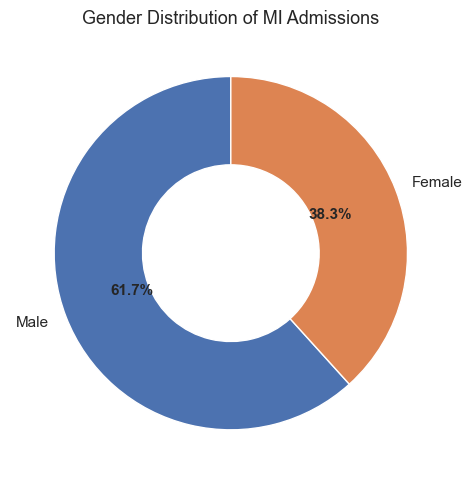

In [203]:
gender_counts = MI_finaldf['gender'].value_counts()
labels = ['Male', 'Female']
sizes = [gender_counts.get('M', 0), gender_counts.get('F', 0)]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5)
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title("Gender Distribution of MI Admissions", fontsize=13)
plt.tight_layout()
plt.show()

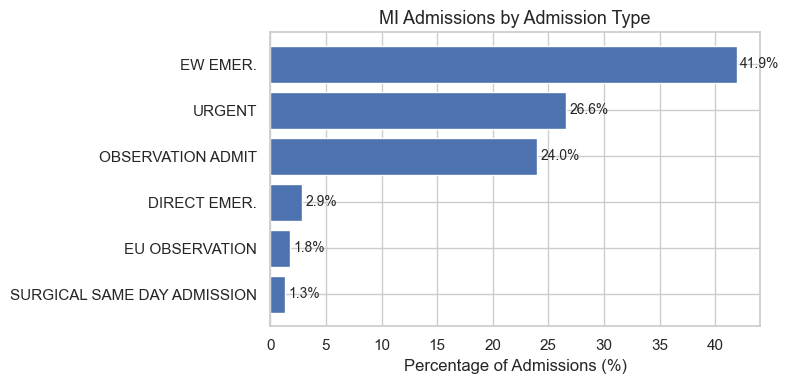

In [208]:
adm_counts = MI_finaldf['admission_type'].value_counts().head(6)
adm_pct = (adm_counts / len(MI_finaldf) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(adm_counts.index, adm_pct.values)

for bar, pct in zip(bars, adm_pct.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontsize=10
    )

ax.set_xlabel('Percentage of Admissions (%)')
ax.set_title('MI Admissions by Admission Type', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [209]:
print(MI_finaldf.groupby("los_cat")["los_days"].mean().round(1))

los_cat
< 7 days     3.4
≥ 7 days    15.7
Name: los_days, dtype: float64
